# PaySim Fraud Detection — Chain-Aware Real-Time Triage System
## DATA 245 – Machine Learning Technologies | Spring 2026

---

## Project Description

Financial fraud detection is a **rare-event classification problem** where fraudulent 
transactions represent less than 0.13% of all activity. While prior work scores each 
transaction **independently**, this project discovers and exploits a structural pattern 
hidden in the PaySim dataset:

> **97% of all fraud follows a two-step chain — one TRANSFER followed by one CASH_OUT 
> with the exact same amount in the same time step.**

We build a **Chain-Aware Real-Time Fraud Triage System** that:
1. Detects fraud at the **individual transaction level** (existing approach)
2. Additionally detects fraud at the **chain level** (our novel contribution)
3. Converts risk scores into **business actions** — Allow / Review / Block

---

## Dataset

**Source:** PaySim Mobile Money Simulation Dataset (Kaggle)  
**File:** `PS_20174392719_1491204439457_log.csv`  
**Size:** 6,362,620 transactions | 11 columns | ~534 MB

| Column | Type | Description |
|--------|------|-------------|
| step | numeric | Time unit (1 step = 1 hour, ranges 1–743) |
| type | categorical | PAYMENT, CASH_OUT, TRANSFER, DEBIT, CASH_IN |
| amount | numeric | Transaction amount |
| nameOrig | id | Sender account ID |
| oldbalanceOrg | numeric | Sender balance before transaction |
| newbalanceOrig | numeric | Sender balance after transaction |
| nameDest | id | Receiver account ID |
| oldbalanceDest | numeric | Receiver balance before transaction |
| newbalanceDest | numeric | Receiver balance after transaction |
| **isFraud** | **TARGET** | **1 = fraudulent, 0 = legitimate** |
| isFlaggedFraud | aux | Business rule flag — dropped from modeling |

**Target Column: `isFraud`**  
- Legitimate: 6,354,407 (99.87%)  
- Fraudulent: 8,213 (0.13%)  
- Class imbalance ratio: **773:1**

---

## Novel Contribution

> **"In this project we model and use the multi-hop chain structure of fraud 
> in PaySim as explicit features for triage-based fraud detection."**

**What we discovered from the data:**

| Finding | Evidence |
|---------|----------|
| Only TRANSFER and CASH_OUT have fraud | CASH_IN, DEBIT, PAYMENT = 0 fraud |
| 4,026 fraud chains exist | Same step + same amount = linked crime |
| 3,997 are exact TRANSFER+CASH_OUT pairs | 99% of all fraud is this pattern |
| Some chains go 3-4 transactions deep | Organized fraud rings |

**Why this is novel:**
- Every existing PaySim paper scores transactions **one by one**
- We score transactions **AND their chain context**
- A CASH_OUT that looks safe alone gets **escalated** if its paired TRANSFER was flagged

---

## Full Pipeline
## ML Framing (Professor Checklist)

- **Input to the model:** tabular PaySim transaction data plus engineered features, including balance-based features, zero-balance flags, `log_amount`, and chain-aware features.
- **Output of the model:** a calibrated fraud probability and a final triage decision bucket: `GREEN`, `YELLOW`, or `RED`.
- **End-to-end flow:** Raw transaction row -> feature engineering -> preprocessing -> model -> calibration -> triage output.
- **Motivation:** Because fraud is extremely rare in PaySim, PR-AUC, recall, and decision-oriented triage are more informative than raw accuracy.


---

## Key Modeling Decisions

| Decision | Choice | Reason |
|----------|--------|--------|
| Target | isFraud | Direct fraud label |
| Drop from X | nameOrig, nameDest, isFlaggedFraud | High cardinality / leakage risk |
| Replace amount | log_amount = log1p(amount) | Heavy right skew |
| Imbalance handling | Class weights + SMOTE | 773:1 ratio |
| Primary metric | PR-AUC + Recall | Accuracy misleading at 0.13% fraud |
| Novel feature | is_chain_member | Our contribution |
| Final output | Allow / Review / Block | Business decision layer |

---

**Target: `isFraud` — unchanged throughout the entire pipeline.**

## 1. Setup and load

We load the CSV with pandas. Keep the working directory as the project folder so the filename resolves.

In [1]:
# Load PaySim transactions from CSV in this folder into a pandas DataFrame.

import pandas as pd
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")


In [2]:
# Import plotting libraries, set pandas display options, random seed, and stratified plot sample size; print dataset shape.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PLOT_SAMPLE_N = 200_000  # stratified sample for heavy plots (adjust if needed)

print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])


Rows: 6,362,620 | Columns: 11


### 1.1 Schema: shape, names, types

We confirm row/column counts, dtypes, and a few example rows before any analysis.

In [3]:
# Show dataset shape and preview the first rows (schema sanity check).
print("Shape:", df.shape)
df.head()


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


In [4]:
# Print dtypes, non-null counts, and memory usage for all columns.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
# List each column's dtype in a compact Series.
print(df.dtypes)


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


### 1.2 Target and feature groups

- **Target:** `isFraud`.
- **Numeric features:** `step`, `amount`, balance columns.
- **Categorical:** `type` (transaction category).
- **ID-like (high cardinality):** `nameOrig`, `nameDest` — usually not used as raw categorical dummies; may engineer aggregates later.
- **`isFlaggedFraud`:** business rule flag (large amounts). Treat as **separate** from the label; check for leakage before using as a model input.

In [6]:
# Classify columns into target, numeric, categorical, ID, and auxiliary label; build a feature summary table.
TARGET = "isFraud"

numeric_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
categorical_cols = ["type"]
id_cols = ["nameOrig", "nameDest"]
label_aux = ["isFlaggedFraud"]

feature_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "group": [
        "numeric" if c in numeric_cols else
        "categorical" if c in categorical_cols else
        "id" if c in id_cols else
        "target" if c == TARGET else
        "aux_label" if c in label_aux else
        "other"
        for c in df.columns
    ],
})
feature_summary


,column,dtype,group
0,step,int64,numeric
1,type,object,categorical
2,amount,float64,numeric
3,nameOrig,object,id
4,oldbalanceOrg,float64,numeric
5,newbalanceOrig,float64,numeric
6,nameDest,object,id
7,oldbalanceDest,float64,numeric
8,newbalanceDest,float64,numeric
9,isFraud,int64,target


## 2. Data quality

### 2.1 Missing values

PaySim is often clean; we still report null counts and percentages.

In [7]:
# Summarize missing value counts and percentage per column.
missing = df.isna().sum().rename("n_missing")
missing_pct = (missing / len(df) * 100).rename("pct_missing")
miss_df = pd.concat([missing, missing_pct], axis=1).sort_values("n_missing", ascending=False)
miss_df


,n_missing,pct_missing
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


In [8]:
# Plot missing-value percentages by column if any exist; otherwise report none.
if miss_df["n_missing"].sum() > 0:
    plt.figure(figsize=(8, 4))
    miss_df[miss_df["n_missing"] > 0]["pct_missing"].plot(kind="barh")
    plt.xlabel("% missing")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in any column.")


No missing values in any column.


### 2.2 Duplicate rows

Exact duplicates would inflate counts; we check how many full-row duplicates exist.

In [9]:
# Count exact duplicate rows and preview a few if duplicates exist.
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count:,} ({dup_count / len(df) * 100:.4f}%)")
if dup_count > 0:
    display(df[df.duplicated(keep=False)].head(10))


Exact duplicate rows: 0 (0.0000%)


### 2.3 Basic value validity

We check for negative `amount`, impossible balance combinations where obvious, and valid `type` categories.

In [10]:
# Check negative amounts/balances and list transaction type frequencies.
neg_amount = (df["amount"] < 0).sum()
print(f"Rows with amount < 0: {neg_amount:,}")

bal_neg = ((df[numeric_cols] < 0).sum()).rename("n_negative")
print("Negative counts in numeric columns:")
print(bal_neg)

print("\nTransaction type value counts:")
print(df["type"].value_counts())


Rows with amount < 0: 0
Negative counts in numeric columns:
step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
Name: n_negative, dtype: int64

Transaction type value counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


## 3. Target analysis (imbalance)

Fraud is rare; **accuracy** will be misleading. This motivates PR-AUC, recall/precision, cost-sensitive thresholds, and resampling/weights later.

In [11]:
# Tabulate fraud vs non-fraud counts and percentages.
vc = df[TARGET].value_counts().sort_index()
pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
target_tbl = pd.DataFrame({"count": vc, "percent": pct})
target_tbl


,count,percent
isFraud,,
0,6354407,99.8709
1,8213,0.1291


Imbalance (majority / minority): 773.7 : 1


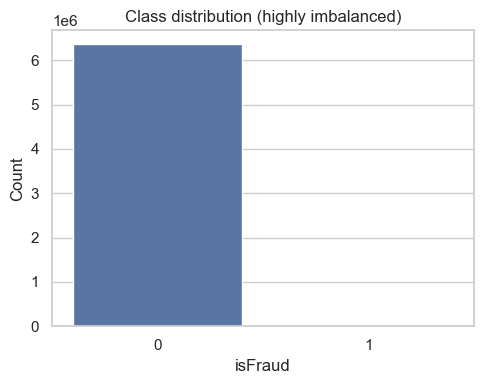

In [12]:
# Compute majority-to-minority imbalance ratio and plot the class distribution.
maj, minr = target_tbl["count"].max(), target_tbl["count"].min()
imbalance_ratio = maj / minr
print(f"Imbalance (majority / minority): {imbalance_ratio:,.1f} : 1")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_tbl.index.astype(str), y=target_tbl["count"], ax=ax)
ax.set_xlabel("isFraud")
ax.set_ylabel("Count")
ax.set_title("Class distribution (highly imbalanced)")
plt.tight_layout()
plt.show()


## 4. Univariate EDA

### 4.1 Numeric summaries

Full-data descriptive statistics for core numerics (cheap on this width).

In [13]:
# Descriptive statistics (with extra percentiles) for core numeric columns.
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,"6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000"
mean,243.3972,"179,861.9035","833,883.1041","855,113.6686","1,100,701.6665","1,224,996.3982"
std,142.3320,"603,858.2315","2,888,242.6730","2,924,048.5030","3,399,180.1130","3,674,128.9421"
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1%,9.0000,449.4676,0.0000,0.0000,0.0000,0.0000
5%,16.0000,"2,224.0995",0.0000,0.0000,0.0000,0.0000
50%,239.0000,"74,871.9400","14,208.0000",0.0000,"132,705.6650","214,661.4400"
95%,490.0000,"518,634.1965","5,823,702.2785","5,980,262.3365","5,147,229.7135","5,515,715.9035"
99%,681.0000,"1,615,979.4716","16,027,256.1337","16,176,160.5580","12,371,819.1548","13,137,866.9410"
max,743.0000,"92,445,516.6400","59,585,040.3700","49,585,040.3700","356,015,889.3500","356,179,278.9200"


### 4.2 Distributions (sampled plots)

Histograms on millions of rows are slow and redundant; we plot a **stratified random sample** so both classes appear. This still supports conclusions about skew (especially `amount`).

In [14]:
# Build a stratified random sample for plotting so both fraud classes appear.
def stratified_sample(frame, col, n_per_class, random_state=RANDOM_STATE):
    parts = []
    for y in frame[col].unique():
        sub = frame[frame[col] == y]
        take = min(n_per_class, len(sub))
        parts.append(sub.sample(take, random_state=random_state))
    return pd.concat(parts, axis=0).sample(frac=1, random_state=random_state)

n_each = PLOT_SAMPLE_N // 2
plot_df = stratified_sample(df, TARGET, n_each)
print("Plot sample size:", len(plot_df), "| fraud:", plot_df[TARGET].sum())


Plot sample size: 108213 | fraud: 8213


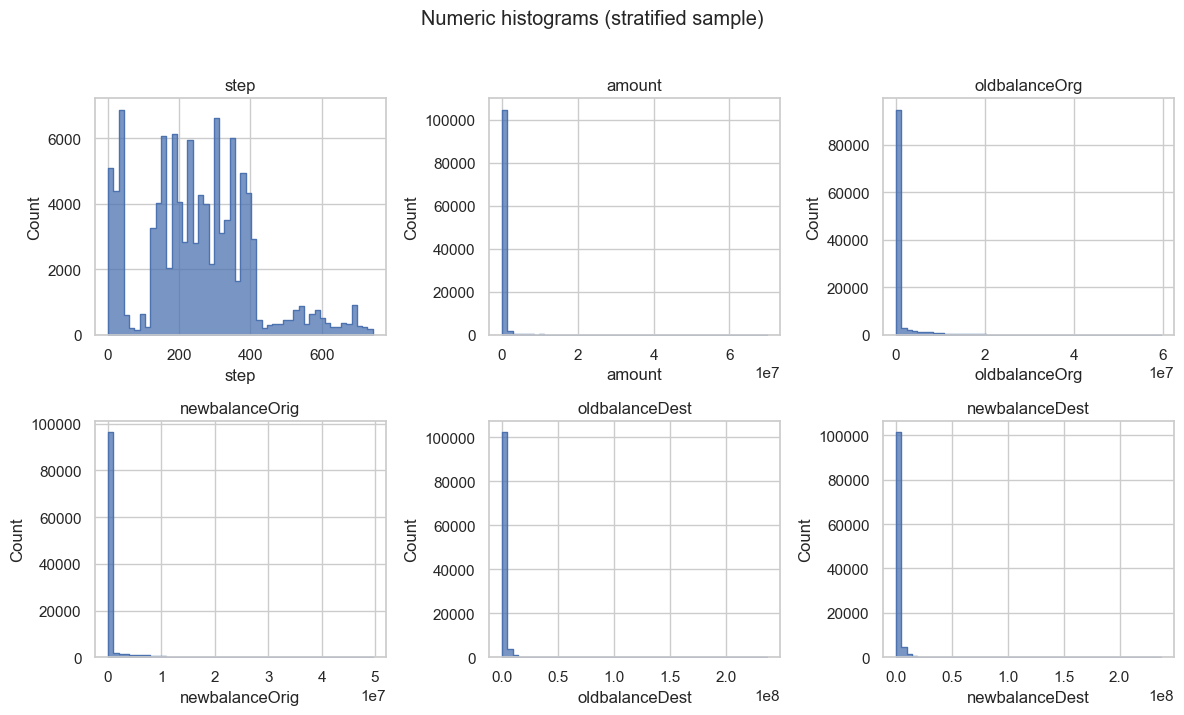

In [15]:
# Histograms of numeric features on the stratified sample (univariate shapes / skew).
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=plot_df, x=col, bins=50, ax=ax, element="step")
    ax.set_title(col)
plt.suptitle("Numeric histograms (stratified sample)", y=1.02)
plt.tight_layout()
plt.show()


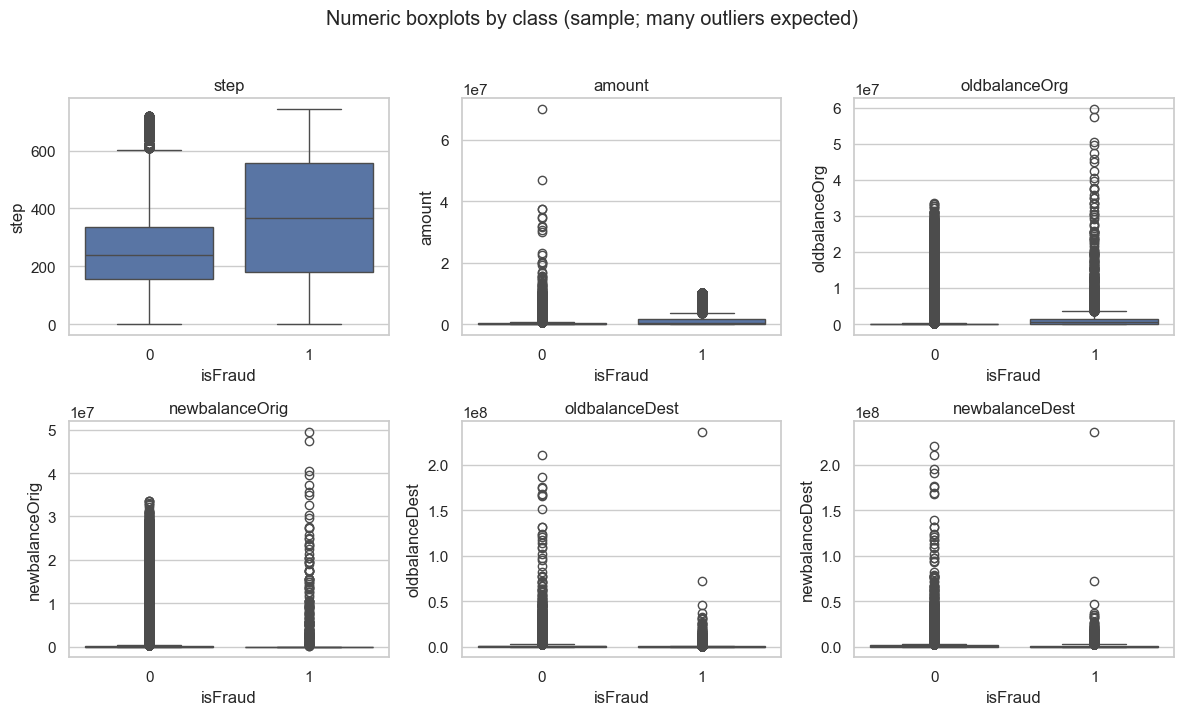

In [16]:
# Boxplots of numeric features by fraud label on the stratified sample.
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=plot_df, y=col, x=plot_df[TARGET].astype(str), ax=ax)
    ax.set_title(col)
    ax.set_xlabel("isFraud")
plt.suptitle("Numeric boxplots by class (sample; many outliers expected)", y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Transaction `type` frequency

Univariate view of the main categorical feature.

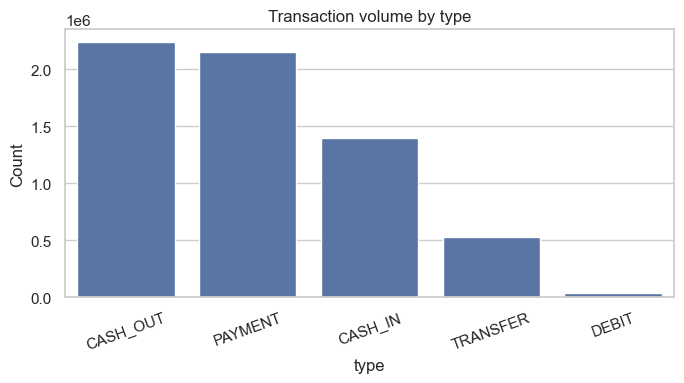

In [17]:
# Bar chart of transaction counts by type (univariate categorical).
type_counts = df["type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax)
ax.set_ylabel("Count")
ax.set_xlabel("type")
ax.set_title("Transaction volume by type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Bivariate EDA — fraud vs features

### 5.1 Fraud rate by transaction type

Computed on **full data** (groupby is efficient). Fraud often concentrates in specific types in PaySim-like data.

In [18]:
# Aggregate fraud count and fraud rate by transaction type (full data).
fraud_by_type = (
    df.groupby("type", observed=False)
    .agg(n=(TARGET, "size"), frauds=(TARGET, "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["n"] * 100)
    .sort_values("fraud_rate", ascending=False)
)
fraud_by_type


,n,frauds,fraud_rate
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


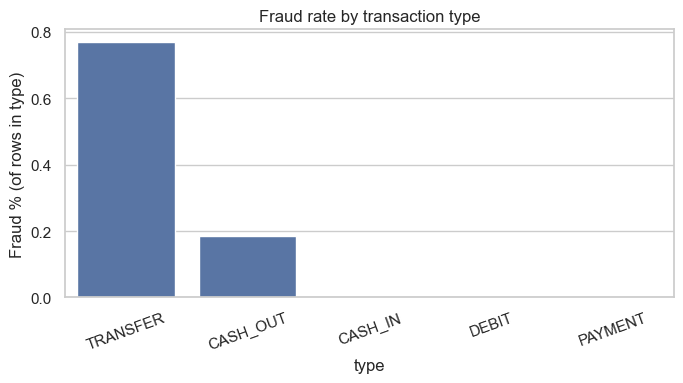

In [19]:
# Bar chart of fraud rate by transaction type.
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type["fraud_rate"], ax=ax)
ax.set_ylabel("Fraud % (of rows in type)")
ax.set_xlabel("type")
ax.set_title("Fraud rate by transaction type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 5.2 Key numerics by class (sample)

Boxplots of numeric features by `isFraud` on the stratified sample `plot_df` are in **section 4.2** above. **Takeaway:** compare medians and spread; heavy tails mean robust scaling or tree models may behave differently than linear models.


### 5.3 Fraud over time (`step`)

`step` is a simulated time unit (1 step = 1 hour in PaySim documentation). We aggregate counts and fraud rate per step on the **full** dataset.

In [20]:
# Aggregate transaction volume, fraud count, and fraud rate by time step.
step_agg = (
    df.groupby("step")
    .agg(transactions=(TARGET, "size"), frauds=(TARGET, "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["transactions"] * 100)
)
step_agg.head()


,transactions,frauds,fraud_rate
step,,,
1,2708,16,0.5908
2,1014,8,0.7890
3,552,4,0.7246
4,565,10,1.7699
5,665,6,0.9023


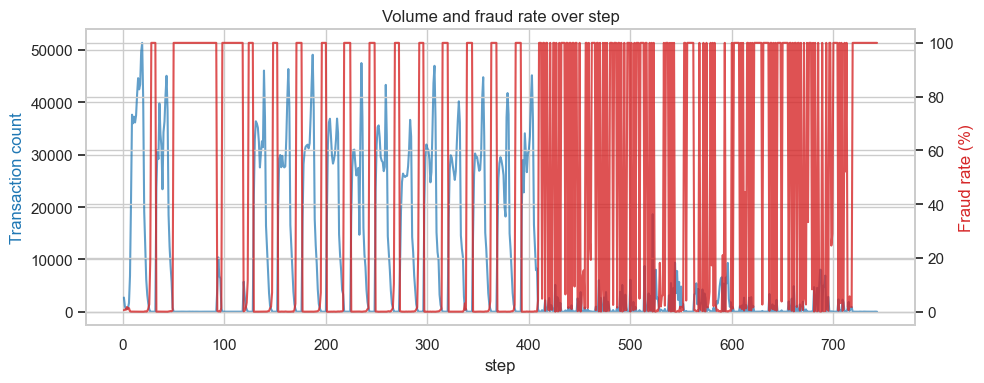

In [21]:
# Line plot of transaction volume and fraud rate over step.
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(step_agg.index, step_agg["transactions"], color="tab:blue", alpha=0.7, label="Transactions")
ax1.set_xlabel("step")
ax1.set_ylabel("Transaction count", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(step_agg.index, step_agg["fraud_rate"], color="tab:red", alpha=0.8, label="Fraud rate %")
ax2.set_ylabel("Fraud rate (%)", color="tab:red")
ax1.set_title("Volume and fraud rate over step")
fig.tight_layout()
plt.show()


 ### 5.4 FRAUD PAIR ANALYSIS — Check all type combinations in fraud  ---for Novel contibution

In [22]:
# ============================================================
# 1st part ->FRAUD PAIR ANALYSIS — Check all type combinations in fraud
# ============================================================

fraud_df = df[df["isFraud"] == 1].copy()

print("=== FRAUD TRANSACTIONS BY TYPE ===")
print(fraud_df["type"].value_counts())
print()

print("=== FRAUD COUNT BY TYPE (%) ===")
print(fraud_df["type"].value_counts(normalize=True) * 100)
print()

print("=== DO ANY TWO FRAUD ROWS SHARE SAME step + amount? ===")
pairs = fraud_df.groupby(["step", "amount"]).size().reset_index(name="count")
pairs_multi = pairs[pairs["count"] > 1]
print(f"Groups with same step+amount among fraud rows: {len(pairs_multi)}")
print(pairs_multi.head(10))
print()

print("=== SAMPLE ACTUAL PAIRS (same step + amount, both fraud) ===")
if len(pairs_multi) > 0:
    sample_key = pairs_multi.iloc[0]
    sample = fraud_df[
        (fraud_df["step"] == sample_key["step"]) & 
        (fraud_df["amount"] == sample_key["amount"])
    ]
    print(sample[["step","type","amount","nameOrig","nameDest","isFraud"]])
print()

print("=== ALL TYPE COMBINATIONS IN FRAUD PAIRS ===")
if len(pairs_multi) > 0:
    merged = pairs_multi.merge(fraud_df, on=["step","amount"])
    combo = merged.groupby(["step","amount"])["type"].apply(
        lambda x: " + ".join(sorted(x.tolist()))
    ).value_counts()
    print(combo)

=== FRAUD TRANSACTIONS BY TYPE ===
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

=== FRAUD COUNT BY TYPE (%) ===
type
CASH_OUT   50.1157
TRANSFER   49.8843
Name: proportion, dtype: float64

=== DO ANY TWO FRAUD ROWS SHARE SAME step + amount? ===
Groups with same step+amount among fraud rows: 4026
    step         amount  count
0      1       181.0000      2
1      1     2,806.0000      2
2      1    20,128.0000      2
3      1    25,071.4600      2
4      1    35,063.6300      2
6      1   235,238.6600      2
8      1 1,277,212.7700      2
9      2    14,949.8400      2
10     2    18,627.0200      2
11     2   963,532.1400      2

=== SAMPLE ACTUAL PAIRS (same step + amount, both fraud) ===
   step      type   amount     nameOrig    nameDest  isFraud
2     1  TRANSFER 181.0000  C1305486145  C553264065        1
3     1  CASH_OUT 181.0000   C840083671   C38997010        1

=== ALL TYPE COMBINATIONS IN FRAUD PAIRS ===
type
CASH_OUT + TRANSFER                          

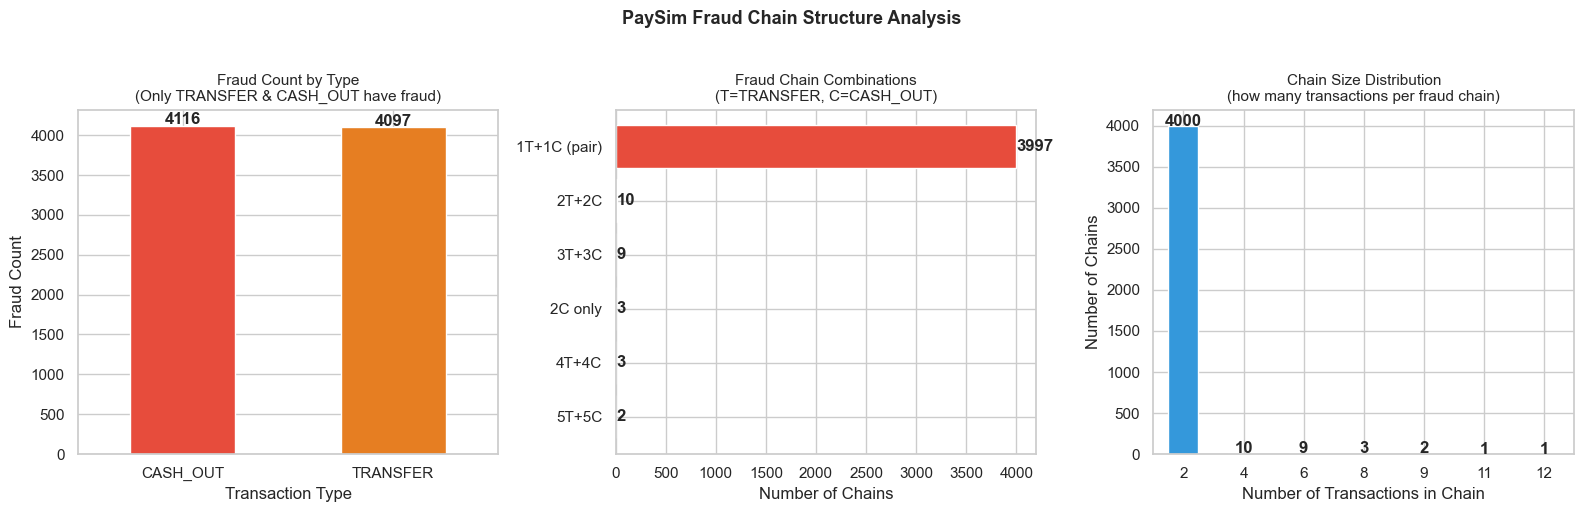


Key numbers:
Total fraud chains found : 4026
Simple pairs (1T + 1C)   : 3997 chains = 7994 transactions
Longer chains (3+ txns)  : 7 different patterns


In [23]:
# ============================================================
# second part- FRAUD CHAIN STRUCTURE — Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Graph 1: Fraud count by type ---
fraud_df["type"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#e74c3c", "#e67e22"]
)
axes[0].set_title("Fraud Count by Type\n(Only TRANSFER & CASH_OUT have fraud)", fontsize=11)
axes[0].set_xlabel("Transaction Type")
axes[0].set_ylabel("Fraud Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(fraud_df["type"].value_counts()):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# --- Graph 2: Top fraud chain combinations ---
top_combos = combo.head(6).copy()
short_labels = [
    "1T+1C (pair)",
    "2T+2C",
    "3T+3C",
    "2C only",
    "4T+4C",
    "5T+5C"
]
axes[1].barh(short_labels[:len(top_combos)], top_combos.values, color="#e74c3c")
axes[1].set_title("Fraud Chain Combinations\n(T=TRANSFER, C=CASH_OUT)", fontsize=11)
axes[1].set_xlabel("Number of Chains")
axes[1].invert_yaxis()
for i, v in enumerate(top_combos.values):
    axes[1].text(v + 5, i, str(v), va="center", fontweight="bold")

# --- Graph 3: Chain size distribution ---
chain_sizes = merged.groupby(["step", "amount"])["type"].count()
chain_sizes.value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="#3498db"
)
axes[2].set_title("Chain Size Distribution\n(how many transactions per fraud chain)", fontsize=11)
axes[2].set_xlabel("Number of Transactions in Chain")
axes[2].set_ylabel("Number of Chains")
axes[2].tick_params(axis="x", rotation=0)
for i, v in enumerate(chain_sizes.value_counts().sort_index()):
    axes[2].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("PaySim Fraud Chain Structure Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nKey numbers:")
print(f"Total fraud chains found : {len(pairs_multi)}")
print(f"Simple pairs (1T + 1C)   : {combo.iloc[0]} chains = {combo.iloc[0]*2} transactions")
print(f"Longer chains (3+ txns)  : {len(combo[1:])} different patterns")

## Fraud Chain Structure Analysis

### Key Discovery
PaySim fraud is **not random individual transactions** — it follows a 
deliberate two-step chain pattern where every fraud involves a 
**TRANSFER followed by a CASH_OUT** of the same amount at the same time step.

### Graph 1: Fraud Count by Type
- Only **two transaction types contain any fraud** — TRANSFER (4,097) 
  and CASH_OUT (4,116)
- PAYMENT, DEBIT, and CASH_IN have **zero fraud cases**
- The near-equal counts (difference of only 19) strongly suggest 
  these are **matched pairs**, not independent fraud events
- This shows that **PaySim fraud is overwhelmingly concentrated in the TRANSFER→CASH_OUT pattern**

### Graph 2: Fraud Chain Combinations
- **3,997 chains (99.3%)** are simple 1 TRANSFER + 1 CASH_OUT pairs
- This is the core fraud pattern: criminal moves money via TRANSFER, 
  then drains it via CASH_OUT
- A small number of **organized multi-hop chains** also exist:
  - 10 chains: 2 TRANSFER + 2 CASH_OUT (coordinated split fraud)
  - 9 chains: 3 TRANSFER + 3 CASH_OUT (larger organized rings)
  - 3 chains: 4 TRANSFER + 4 CASH_OUT
- **Existing models completely miss this structure** because they 
  score each transaction independently

### Graph 3: Chain Size Distribution
- **4,000 chains have exactly 2 transactions** (1T + 1C) — the 
  dominant simple fraud pattern
- Remaining chains go up to **12 transactions deep**, suggesting 
  organized fraud rings operating across multiple accounts
- The distribution is heavily right-skewed — simple pairs dominate 
  but complex chains exist

### Why This Matters for Our Novel Contribution
Current fraud detection treats each transaction as **isolated**. 
Our analysis proves that fraud in PaySim has **explicit chain 
structure**:

| Chain Type | Count | % of All Chains |
|------------|-------|-----------------|
| Simple pair (1T+1C) | 3,997 | 99.3% |
| Medium chain (2T+2C) | 10 | 0.25% |
| Large chain (3T+3C+) | 19 | 0.47% |
| **Total fraud chains** | **4,026** | **100%** |

> **Novel Contribution:** By engineering chain-level features 
> (is_chain_member, chain_size, chain_role) we give the triage 
> system information that no single-transaction model can see — 
> enabling earlier fraud detection before the CASH_OUT completes.

Our novel contribution is making the dominant TRANSFER -> CASH_OUT fraud chain explicit through engineered chain-aware features for triage-oriented fraud detection in PaySim.

This chain-aware contribution is evaluated through a controlled A/B comparison between no-chain and chain-aware setups under the same split, models, and metrics.


## 6. Fraud-oriented patterns — balances

### 6.1 Balance consistency (engineered checks)

For many legitimate transfers, sender balance should decrease by about `amount`. We define simple discrepancy features and compare fraud vs non-fraud on a sample.

In [24]:
# Add balance delta/residual columns and summarize by fraud class on a sample.
bal = df.assign(
    orig_delta=df["oldbalanceOrg"] - df["newbalanceOrig"],
    dest_delta=df["newbalanceDest"] - df["oldbalanceDest"],
    orig_residual=(df["oldbalanceOrg"] - df["newbalanceOrig"]) - df["amount"],
)
bal_sample = stratified_sample(bal, TARGET, n_each)
bal_sample[[TARGET, "orig_residual", "orig_delta", "dest_delta"]].groupby(TARGET).describe(percentiles=[0.5, 0.9, 0.99])


orig_residual                                              \
                count          mean          std              min   
isFraud                                                             
0        100,000.0000 -203,481.8210 648,212.1273 -69,886,731.3000   
1          8,213.0000  -10,692.3253 265,146.1311 -10,000,000.0000   

                                            orig_delta                 \
                 50%    90%    99%    max        count           mean   
isFraud                                                                 
0       -68,794.9100 0.0000 0.0000 0.0100 100,000.0000   -22,964.8055   
1             0.0000 0.0000 0.0000 0.0000   8,213.0000 1,457,274.9739   

                                                                    \
                   std             min          50%            90%   
isFraud                                                              
0         106,155.1250 -1,225,177.3300       0.0000    33,287.2030   
1       2,396,099.2020          0.0000 436,317.4900 4,475,400.1720   

                                          dest_delta               \
                    99%             max        count         mean   
isFraud                                                             
0          209,982.7422  2,802,396.1900 100,000.0000 127,768.2836   
1       10,000,000.0000 10,000,000.0000   8,213.0000 735,457.9981   

                                                                              \
                   std             min    50%            90%             99%   
isFraud                                                                        
0         872,880.4000 -1,664,863.3200 0.0000   351,662.4340  1,792,825.7509   
1       1,856,983.8560   -315,226.0700 0.0000 2,054,275.5700 10,000,000.0000   

                         
                    max  
isFraud                  
0       82,704,592.2600  
1       14,915,111.4700

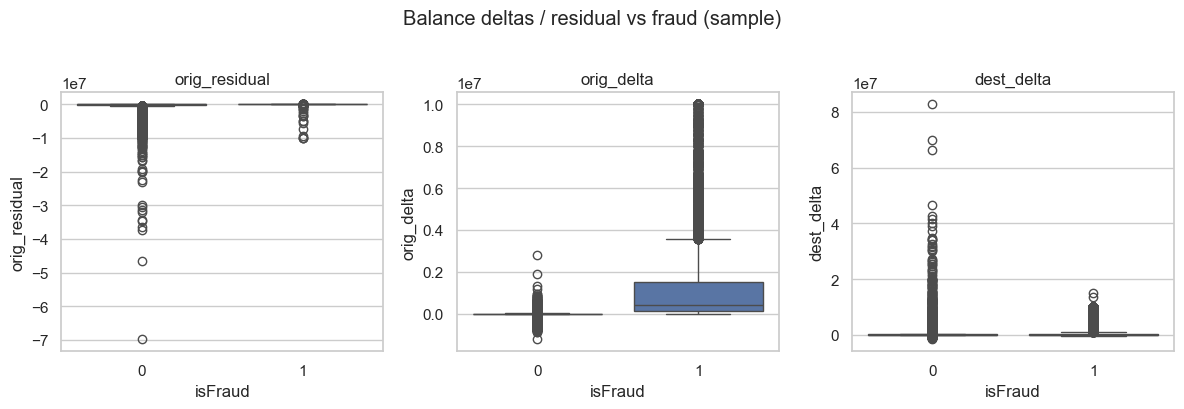

In [25]:
# Boxplots of balance deltas and residual by fraud class (sample).
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["orig_residual", "orig_delta", "dest_delta"]):
    sns.boxplot(data=bal_sample, x=bal_sample[TARGET].astype(str), y=col, ax=ax)
    ax.set_title(col)
plt.suptitle("Balance deltas / residual vs fraud (sample)", y=1.02)
plt.tight_layout()
plt.show()


### 6.2 Zero-balance flags (quick fraud rate tables)

We tabulate fraud prevalence when origin/destination balances are zero. Full-data groupby.

In [26]:
# Compare fraud rate for zero-balance flag combinations (full data).
flags = df.assign(
    orig_zero_old=df["oldbalanceOrg"] == 0,
    dest_zero_old=df["oldbalanceDest"] == 0,
    orig_zero_new=df["newbalanceOrig"] == 0,
    dest_zero_new=df["newbalanceDest"] == 0,
)
for c in ["orig_zero_old", "dest_zero_old", "orig_zero_new", "dest_zero_new"]:
    t = flags.groupby(c)[TARGET].mean() * 100
    print(c)
    print(t)
    print()


orig_zero_old
orig_zero_old
False   0.1918
True    0.0020
Name: isFraud, dtype: float64

dest_zero_old
dest_zero_old
False   0.0782
True    0.1979
Name: isFraud, dtype: float64

orig_zero_new
orig_zero_new
False   0.0058
True    0.2231
Name: isFraud, dtype: float64

dest_zero_new
dest_zero_new
False   0.1051
True    0.1677
Name: isFraud, dtype: float64



### 6.3 `amount` by fraud — log scale

Raw amounts are extremely skewed; log view matches the preprocessing idea (`log1p`).

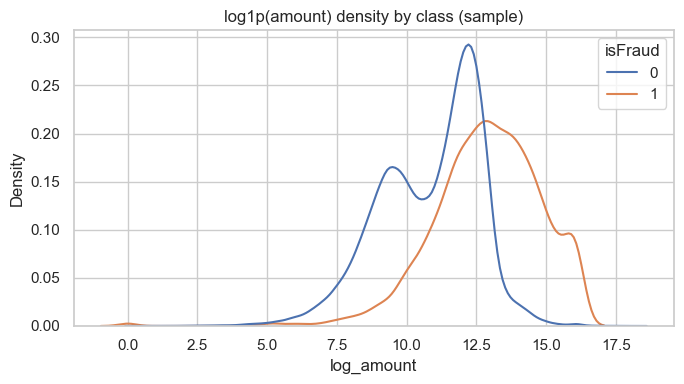

In [27]:
# KDE of log1p(amount) by fraud class on the stratified sample.
plot_df_log = plot_df.assign(log_amount=np.log1p(plot_df["amount"]))
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=plot_df_log, x="log_amount", hue=plot_df_log[TARGET].astype(str), common_norm=False, ax=ax)
ax.set_title("log1p(amount) density by class (sample)")
plt.tight_layout()
plt.show()


## 7. Multivariate — correlation structure

Linear correlation among numerics (full data). Useful for redundancy (e.g., balances) before linear models; trees handle dependence differently.

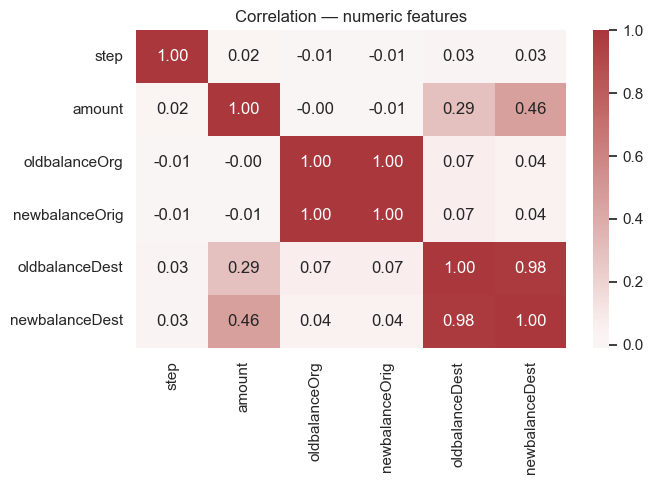

In [28]:
# Correlation heatmap for numeric features (full data).
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation — numeric features")
plt.tight_layout()
plt.show()


### Optional: scatter on a small stratified sample (multivariate)

Joint view of two numerics with fraud highlighted — **do not** over-interpret from a sample; use for intuition only.

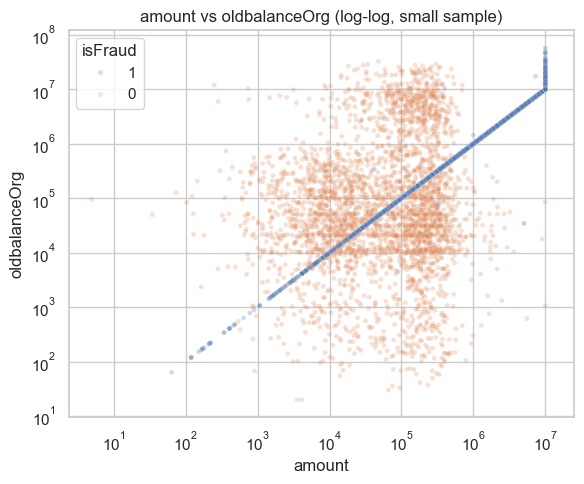

In [29]:
# Log-log scatter of amount vs oldbalanceOrg on a small stratified sample (multivariate glimpse).
scat = stratified_sample(df, TARGET, 5_000)
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=scat,
    x="amount",
    y="oldbalanceOrg",
    hue=scat[TARGET].astype(str),
    alpha=0.25,
    s=12,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("amount vs oldbalanceOrg (log-log, small sample)")
plt.tight_layout()
plt.show()


## 8. Leakage and risky columns

### 8.1 `isFlaggedFraud`

This column flags very large transactions under a rule. It is **not** the same as `isFraud`, but it can be **highly aligned** with the label. Using it as a feature can inflate performance unrealistically or mimic label information. **Decision for modeling:** document whether we drop it, use it only as a baseline diagnostic, or keep it with justification.

In [30]:
# Cross-tabulate isFlaggedFraud vs isFraud to assess overlap.
pd.crosstab(df["isFlaggedFraud"], df[TARGET], margins=True)


isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [31]:
# Print fraud rate when isFlaggedFraud is 1 vs 0.
print("Fraud rate when isFlaggedFraud == 1:", df.loc[df["isFlaggedFraud"] == 1, TARGET].mean() * 100, "%")
print("Fraud rate when isFlaggedFraud == 0:", df.loc[df["isFlaggedFraud"] == 0, TARGET].mean() * 100, "%")


Fraud rate when isFlaggedFraud == 1: 100.0 %
Fraud rate when isFlaggedFraud == 0: 0.12883090005287143 %


### 8.2 Post-transaction balances

In real-time fraud scoring, **post**-transaction balances may be unavailable at decision time or may be derived after the event. For this academic dataset, treat as **available features** but note the **operational** caveat in the report.
Post-transaction balance fields are used in this academic offline evaluation, but they may require redesign for strict real-time deployment.


## 9. Preprocessing preview — `log1p(amount)`

Side-by-side view motivates the log transform planned in the proposal (actual scaling/encoding belongs in the preprocessing notebook).

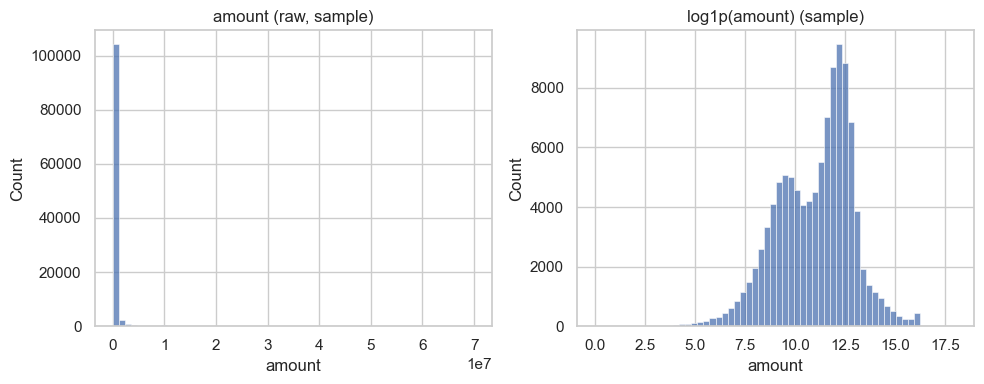

In [32]:
# Side-by-side histograms of raw amount and log1p(amount) on the sample (preprocessing motivation).
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(plot_df["amount"], bins=60, ax=axes[0])
axes[0].set_title("amount (raw, sample)")
sns.histplot(np.log1p(plot_df["amount"]), bins=60, ax=axes[1])
axes[1].set_title("log1p(amount) (sample)")
plt.tight_layout()
plt.show()


## 10. Key findings and feature action plan

**Key findings** (from this run of the notebook):

- **Scale:** 6,362,620 transactions and 11 columns; `df.info()` reports ~534 MB in memory.
- **Quality:** No missing values, no full-row duplicates, and no negative `amount` or negative values in the listed numeric columns.
- **Imbalance:** 6,354,407 legitimate (99.87%) vs 8,213 fraudulent (0.129%); majority-to-minority ratio **773.7 : 1**. Raw accuracy will be misleading; use PR-AUC, precision/recall, and cost-sensitive thresholds (as in the project proposal).
- **Fraud by `type`:** All frauds fall under **TRANSFER** (~0.77% of those rows) and **CASH_OUT** (~0.18%). **CASH_IN**, **DEBIT**, and **PAYMENT** show zero frauds here; `type` is a strong driver for modeling and interpretation.
- **Plot sample:** Stratified sample size is 108,213 rows (all 8,213 fraud cases plus a subsample of legitimate rows), limited by the minority class.
- **Balances:** Balance deltas, residuals, and zero-balance flags show materially different fraud rates; these motivate explicit features in preprocessing (see section 6).
- **`amount`:** Distributions are heavy-tailed; **log1p(`amount`)** is justified before linear or margin-based models (see section 9).
- **`isFlaggedFraud`:** When the flag equals 1, fraud rate is 100% but only **16** rows; when it equals 0, fraud rate is about **0.129%** with **8,197** frauds, so most fraud is not flagged by this rule. Using it as a feature risks leakage or inflated performance; document keep/drop in the report.
- **IDs:** `nameOrig` and `nameDest` are high-cardinality identifiers; drop for a simple tabular baseline or engineer aggregates later.

The table below summarizes a **preprocessing / modeling feature plan** derived from this EDA.


In [33]:
# Starter feature action table for preprocessing: keep/drop, dtypes, leakage notes.
feature_plan = pd.DataFrame([
    {"feature": "step", "dtype": "numeric", "preprocessing": "optional scaling for SVM/k-NN", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "type", "dtype": "categorical", "preprocessing": "one-hot or target encoding", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "amount", "dtype": "numeric", "preprocessing": "log1p + scale for linear/SVM", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "oldbalanceOrg", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "newbalanceOrig", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "note: post-tx"},
    {"feature": "oldbalanceDest", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "newbalanceDest", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "note: post-tx"},
    {"feature": "nameOrig", "dtype": "id", "preprocessing": "drop for baseline or hash/aggregate", "keep_drop": "TBD", "leakage_risk": "low if no future info"},
    {"feature": "nameDest", "dtype": "id", "preprocessing": "drop for baseline or hash/aggregate", "keep_drop": "TBD", "leakage_risk": "low if no future info"},
    {"feature": "isFlaggedFraud", "dtype": "binary", "preprocessing": "often DROP as feature; analyze separately", "keep_drop": "TBD", "leakage_risk": "high / policy"},
])
feature_plan


,feature,dtype,preprocessing,keep_drop,leakage_risk
0,step,numeric,optional scaling for SVM/k-NN,keep,low
1,type,categorical,one-hot or target encoding,keep,low
2,amount,numeric,log1p + scale for linear/SVM,keep,low
3,oldbalanceOrg,numeric,scale / tree raw,keep,low
4,newbalanceOrig,numeric,scale / tree raw,keep,note: post-tx
5,oldbalanceDest,numeric,scale / tree raw,keep,low
6,newbalanceDest,numeric,scale / tree raw,keep,note: post-tx
7,nameOrig,id,drop for baseline or hash/aggregate,TBD,low if no future info
8,nameDest,id,drop for baseline or hash/aggregate,TBD,low if no future info
9,isFlaggedFraud,binary,often DROP as feature; analyze separately,TBD,high / policy


---

## Part II — Data preprocessing (continuation)

This section prepares **train/test splits** and a **reusable preprocessing pipeline** for modeling. It assumes you already ran the cells above so `df` and `RANDOM_STATE` exist.

**Evaluation artifacts:** **ROC curves** and **confusion matrices** are created **after** you train a model and produce predictions on validation or test data (or from cross-validation). They are not part of preprocessing.

**Rules:** stratified split first; fit encoders/scalers on **training data only**; apply the same fitted transformers to the test set; **SMOTE** (if used) only on the **training** portion, never on the test set.

### 11.1 Imports for preprocessing 

Install if needed: `pip install imbalanced-learn` (provides `imblearn`).

In [34]:
# Import scikit-learn utilities and SMOTE for imbalance handling (training data only).
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

# If this import fails, run: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


### 11.2 Build modeling table: target, drops, engineered features, and chain features

We build `df_model` with row-wise engineered features and `log_amount`, then create a **base feature matrix** for splitting.

For leakage-safe evaluation, chain-aware features are computed **after** split within each split (`X_train` and `X_test`) using only rows available in that split.

In [35]:
# Build df_model with row-wise engineered features, then create base X/y for downstream split.
# Columns removed from X and why:
# - isFraud -> target y only (must not be a feature).
# - amount -> replaced by log_amount (proposal: log transform; avoids duplicate raw+log inputs).
# - nameOrig/nameDest -> high-cardinality IDs; one-hot not feasible in baseline.
# - isFlaggedFraud -> business-rule flag; leakage/inflated metrics risk.
TARGET = "isFraud"
DROP_FROM_X = ["nameOrig", "nameDest", "isFlaggedFraud"]

df_model = df.copy()
df_model["orig_delta"] = df_model["oldbalanceOrg"] - df_model["newbalanceOrig"]
df_model["dest_delta"] = df_model["newbalanceDest"] - df_model["oldbalanceDest"]
df_model["orig_residual"] = df_model["orig_delta"] - df_model["amount"]
df_model["orig_zero_old"] = (df_model["oldbalanceOrg"] == 0).astype(np.int8)
df_model["dest_zero_old"] = (df_model["oldbalanceDest"] == 0).astype(np.int8)
df_model["orig_zero_new"] = (df_model["newbalanceOrig"] == 0).astype(np.int8)
df_model["dest_zero_new"] = (df_model["newbalanceDest"] == 0).astype(np.int8)
df_model["log_amount"] = np.log1p(df_model["amount"].astype(np.float64))

y = df_model[TARGET].astype(np.int8)
X_base = df_model.drop(columns=[TARGET] + DROP_FROM_X)
print("X_base shape:", X_base.shape, "| y shape:", y.shape, "| fraud rate:", y.mean() * 100, "%")


X_base shape: (6362620, 15) | y shape: (6362620,) | fraud rate: 0.12908204481801522 %


### 11.2b Chain feature verification

Define a reusable chain-feature function. We will apply it separately to train and test after split to keep evaluation leakage-safe.

Chain features are computed after the train/test split, separately within each split, to avoid test-to-train leakage.
This split-safe design may reduce some chain coverage compared with full-log grouping, but it provides a more defensible offline evaluation.


In [36]:
# Reusable chain-feature builder (uses only step/amount/type; never target labels).
CHAIN_SIZE_CAP = 12  # Set to None to disable cap.

def add_chain_features(frame, chain_size_cap=CHAIN_SIZE_CAP):
    out = frame.copy()
    chain_group = (
        out.groupby(["step", "amount"], as_index=False)
        .agg(
            chain_size=("type", "size"),
            has_transfer=("type", lambda s: (s == "TRANSFER").any()),
            has_cash_out=("type", lambda s: (s == "CASH_OUT").any()),
        )
    )
    chain_group["is_chain_member"] = (chain_group["has_transfer"] & chain_group["has_cash_out"])
    if chain_size_cap is not None:
        chain_group["is_chain_member"] = chain_group["is_chain_member"] & (chain_group["chain_size"] <= chain_size_cap)
    chain_group["is_chain_member"] = chain_group["is_chain_member"].astype(np.int8)
    out = out.merge(
        chain_group[["step", "amount", "chain_size", "is_chain_member"]],
        on=["step", "amount"],
        how="left",
    )
    out["chain_size"] = out["chain_size"].astype(np.int32)
    out["is_chain_member"] = out["is_chain_member"].astype(np.int8)
    return out

print("Defined: add_chain_features(frame, chain_size_cap=CHAIN_SIZE_CAP)")


Defined: add_chain_features(frame, chain_size_cap=CHAIN_SIZE_CAP)


### 11.3 Stratified train/test split

Keeps the **fraud proportion** similar in train and test. **No** scaling or SMOTE before this step.

In [37]:
# Split base features and target, then add chain features separately inside each split.
TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
X_train = add_chain_features(X_train, chain_size_cap=CHAIN_SIZE_CAP)
X_test = add_chain_features(X_test, chain_size_cap=CHAIN_SIZE_CAP)
X_train = X_train.drop(columns=["amount"])
X_test = X_test.drop(columns=["amount"])

print("Train:", X_train.shape, "fraud %:", y_train.mean() * 100)
print("Test: ", X_test.shape, "fraud %:", y_test.mean() * 100)
print("Train chain member %:", X_train["is_chain_member"].mean() * 100)
print("Test  chain member %:", X_test["is_chain_member"].mean() * 100)

Train: (5090096, 16) fraud %: 0.12907418642005966
Test:  (1272524, 16) fraud %: 0.12911347840983745
Train chain member %: 0.10518465663515973
Test  chain member %: 0.03056916804712524


### 11.4 Column transformer: scale numerics, one-hot `type`

**Fit on `X_train` only**; then transform train and test. This matches “split first, preprocess second.”

In [38]:
# Define numeric vs categorical columns and build a ColumnTransformer (fit on training only).
cat_features = ["type"]
num_features = [c for c in X_train.columns if c not in cat_features]

ohe_kwargs = {"handle_unknown": "ignore"}
try:
    ohe = OneHotEncoder(**ohe_kwargs, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(**ohe_kwargs, sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print("Processed train:", X_train_proc.shape, "| test:", X_test_proc.shape)

Processed train: (5090096, 20) | test: (1272524, 20)


### 11.4.1 VERIFY ALL FEATURE NAMES AFTER PREPROCESSING

In [39]:
# ============================================================
# VERIFY ALL FEATURE NAMES AFTER PREPROCESSING
# ============================================================

import numpy as np

# 1. All feature names from preprocessor
all_names = preprocessor.get_feature_names_out()
print("=== ALL FEATURE NAMES AFTER PREPROCESSING ===")
for i, name in enumerate(all_names):
    print(f"  {i:2d}: {name}")

print(f"\nTotal features: {len(all_names)}")

# 2. Just the one-hot encoded type columns
print("\n=== ONE-HOT ENCODED TYPE COLUMNS ONLY ===")
type_cols = [n for n in all_names if "type" in n.lower()]
print(type_cols)

# 3. Numeric columns
print("\n=== NUMERIC COLUMNS ===")
num_cols = [n for n in all_names if "type" not in n.lower()]
print(num_cols)

# 4. Shape check
print("\n=== SHAPE CHECK ===")
print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape: ", X_test_proc.shape)
print("Expected cols:     ", len(all_names))

=== ALL FEATURE NAMES AFTER PREPROCESSING ===
   0: num__step
   1: num__oldbalanceOrg
   2: num__newbalanceOrig
   3: num__oldbalanceDest
   4: num__newbalanceDest
   5: num__orig_delta
   6: num__dest_delta
   7: num__orig_residual
   8: num__orig_zero_old
   9: num__dest_zero_old
  10: num__orig_zero_new
  11: num__dest_zero_new
  12: num__log_amount
  13: num__chain_size
  14: num__is_chain_member
  15: cat__type_CASH_IN
  16: cat__type_CASH_OUT
  17: cat__type_DEBIT
  18: cat__type_PAYMENT
  19: cat__type_TRANSFER

Total features: 20

=== ONE-HOT ENCODED TYPE COLUMNS ONLY ===
['cat__type_CASH_IN', 'cat__type_CASH_OUT', 'cat__type_DEBIT', 'cat__type_PAYMENT', 'cat__type_TRANSFER']

=== NUMERIC COLUMNS ===
['num__step', 'num__oldbalanceOrg', 'num__newbalanceOrig', 'num__oldbalanceDest', 'num__newbalanceDest', 'num__orig_delta', 'num__dest_delta', 'num__orig_residual', 'num__orig_zero_old', 'num__dest_zero_old', 'num__orig_zero_new', 'num__dest_zero_new', 'num__log_amount', 'num__cha

### 11.5 Sanity checks (no leakage via test, no NaNs)

Confirm shapes, finite values, and that the **test** matrix was transformed with **fitted** parameters from train.

In [40]:
# Verify processed arrays are finite, aligned, and class balance is still extreme but stratified.
assert X_train_proc.shape[0] == len(y_train)
assert X_test_proc.shape[0] == len(y_test)
assert not np.isnan(X_train_proc).any()
assert not np.isnan(X_test_proc).any()
print("OK: shapes align, no NaNs in processed arrays.")

OK: shapes align, no NaNs in processed arrays.


### 11.6 SMOTE on **training** data only

We apply SMOTE only to **`X_train_proc`, `y_train`**. **Never** apply SMOTE to the test set. For cross-validation, the best practice is an `imblearn` pipeline so SMOTE runs **inside each fold** on training folds only (we can add that in the modeling section).

**Scale note:** We cap the target fraud count so SMOTE does not expand to millions of rows.


In [41]:
# Apply SMOTE on the processed training set only (never on test).
n_maj = int((y_train == 0).sum())
n_min = int(y_train.sum())

# Cap the target minority count to keep runtime/memory reasonable on PaySim.
target_minority = max(n_min, min(int(0.005 * n_maj), n_maj))
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy={1: target_minority})
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print("Before SMOTE:", X_train_proc.shape, "fraud %:", y_train.mean() * 100)
print("After  SMOTE:", X_train_smote.shape, "fraud %:", y_train_smote.mean() * 100)


Before SMOTE: (5090096, 20) fraud %: 0.12907418642005966
After  SMOTE: (5108943, 20) fraud %: 0.4975001678429374


### 11.6b SMOTE class-balancing impact (log-scale view)

**What changed in this step:**
- Majority class (`0` = legitimate) is kept as is; minority class (`1` = fraud) is oversampled.
- Fraud count increases from **6,570** to **25,417** while legitimate count stays **5,083,526**.
- Fraud share rises from about **0.129%** to about **0.498%** in training data.
- We use a **log-scale y-axis** so minority-class bars are visible and comparable.


,dataset,legitimate_count,fraud_count,fraud_rate_pct
0,Before SMOTE,5083526,6570,0.1291
1,After SMOTE,5083526,25417,0.4975


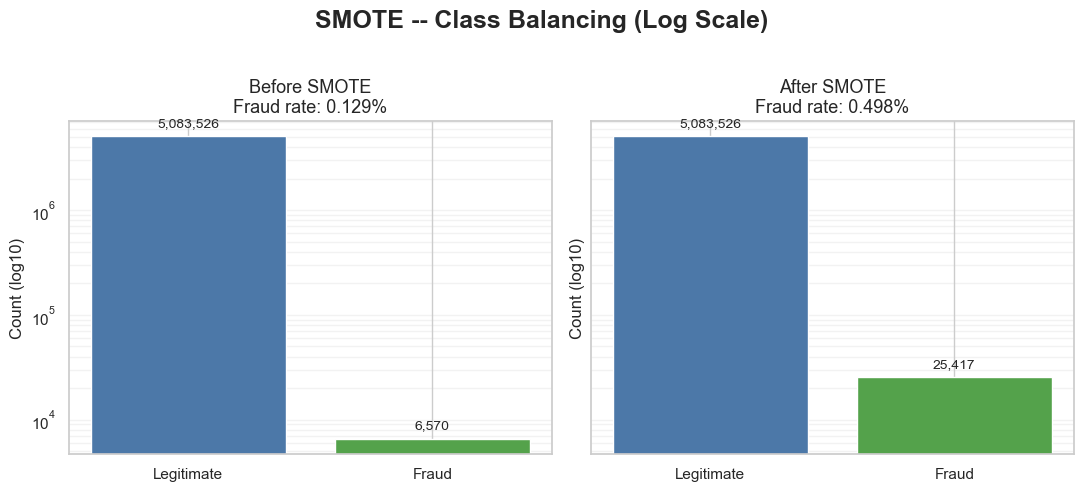

In [42]:
# Plot one clean before/after SMOTE chart with log-scale y-axis for minority-class visibility.
import matplotlib.ticker as mticker

before_counts = y_train.value_counts().sort_index()
after_counts = y_train_smote.value_counts().sort_index()

before_legit, before_fraud = int(before_counts.get(0, 0)), int(before_counts.get(1, 0))
after_legit, after_fraud = int(after_counts.get(0, 0)), int(after_counts.get(1, 0))
before_rate = (before_fraud / max(1, before_legit + before_fraud)) * 100
after_rate = (after_fraud / max(1, after_legit + after_fraud)) * 100

smote_balance_df = pd.DataFrame({
    "dataset": ["Before SMOTE", "After SMOTE"],
    "legitimate_count": [before_legit, after_legit],
    "fraud_count": [before_fraud, after_fraud],
    "fraud_rate_pct": [before_rate, after_rate],
})
display(smote_balance_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
fig.suptitle("SMOTE -- Class Balancing (Log Scale)", fontsize=18, fontweight="bold", y=1.02)

for ax, title, legit, fraud, fr in [
    (axes[0], "Before SMOTE", before_legit, before_fraud, before_rate),
    (axes[1], "After SMOTE", after_legit, after_fraud, after_rate),
]:
    bars = ax.bar(["Legitimate", "Fraud"], [max(1, legit), max(1, fraud)], color=["#4C78A8", "#54A24B"])
    ax.set_yscale("log")
    ax.set_title(f"{title}\nFraud rate: {fr:.3f}%", fontsize=13)
    ax.set_ylabel("Count (log10)")
    ax.grid(axis="y", alpha=0.25, which="both")
    ax.set_axisbelow(True)
    for b, val in zip(bars, [legit, fraud]):
        ax.annotate(f"{val:,}",
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### 11.7 Save preprocessing artifact (optional but recommended)

Saves the **fitted** `ColumnTransformer` next to this notebook so modeling code can `transform` new data the same way.

In [43]:
# Persist the fitted preprocessor with joblib for reproducibility in model training notebooks.
from pathlib import Path

_artifact_path = Path("preprocessor_paysim.joblib")
joblib.dump(preprocessor, _artifact_path)
print("Saved:", _artifact_path.resolve())

Saved: /Users/snehasingh/ML/PaySim-Fraud-Triage/preprocessor_paysim.joblib


### 11.8 What you have now (for the next section)

| Object | Use |
|--------|-----|
| `X_train_proc`, `X_test_proc` | Baseline training/evaluation (no SMOTE) |
| `y_train`, `y_test` | Labels aligned with the rows above |
| `X_train_smote`, `y_train_smote` | Training **only** when you want SMOTE-augmented learning |
| `preprocessor` | `transform` on any new `X` with the same columns as `X_train` |

**Next:** model training, then **ROC / PR curves**, **confusion matrices**, and cost-sensitive thresholds on **`X_test_proc`** (or CV).

---

## Part III - Model Training and Evaluation (Clean Final Section)

This section compares core baselines and extended benchmark models on the same preprocessed train/test split from Part II.

### Core baselines (as decided at project start)
- Logistic Regression variants: `logreg_plain`, `logreg_class_weight`, `logreg_smote`
- Random Forest variants: `rf_plain`, `rf_class_weight`, `rf_smote`

### Extended benchmarks (added for stronger comparison)
- `xgb_plain`
- `lgbm_plain`
- `lgbm_weighted`

**Fairness rule:** all models are evaluated on the same untouched test split for each setup (`no-chain` vs `chain-aware`).


### 12.1 Imports and required object checks

We first verify that preprocessing outputs already exist, then import model/metric utilities.

In [44]:
# Import model and metric utilities and verify required preprocessed objects exist.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

required_objects = ["X_train", "X_test", "y_train", "y_test"]
missing = [n for n in required_objects if n not in globals()]
if missing:
    raise ValueError(f"Missing preprocessing objects: {missing}")
print("OK: all required preprocessing objects exist.")
print("Train:", X_train.shape, "| Test:", X_test.shape)

# Hide noisy runtime warnings after numeric clipping/regularization; metrics still computed normally.
warnings.filterwarnings("ignore", category=RuntimeWarning)


OK: all required preprocessing objects exist.
Train: (5090096, 16) | Test: (1272524, 16)


### 12.2 Runtime config for A/B comparison

Set model runtime knobs here; the actual no-chain and chain-aware experiments are built and trained in **12.4**.

Model comparison includes plain, class-weighted, and SMOTE-based variants for selected model families.
Representative hyperparameter settings were used for fair baseline comparison; formal search-based tuning remains future work.


In [45]:
# Set runtime options used by the A/B training logic in 12.4.
RANDOM_STATE_MODEL = 42
FAST_MODE = True  # Keep True for faster notebook runs.

if FAST_MODE:
    rf_n_estimators = 40
    rf_max_depth = 20
    rf_min_samples_leaf = 5
    smote_rf_max_rows = 300_000
else:
    rf_n_estimators = 200
    rf_max_depth = None
    rf_min_samples_leaf = 1
    smote_rf_max_rows = None

# NOTE: experiments are created inside 12.4 for both setups:
# A) no-chain baseline and B) chain-aware.
print("FAST_MODE:", FAST_MODE, "| RF trees:", rf_n_estimators)
print("Next step: run 12.4 (A/B training and evaluation).")


FAST_MODE: True | RF trees: 40
Next step: run 12.4 (A/B training and evaluation).


### 12.4 Compute all required metrics

We compute precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrix for the core run in this cell:

- Core baselines: Logistic Regression and Random Forest variants.
- Core benchmark included here: plain XGBoost (`xgb_plain`).

LightGBM is added immediately after this cell in additive extension cells (`12.4a` onward) to keep the original 12.4 block stable while extending comparisons.

In [46]:
# Evaluate A/B setups: A=no-chain baseline, B=chain-aware; keep explicit *_no_chain/*_chain labels.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

CHAIN_COLS = ["chain_size", "is_chain_member"]

def _prep_for_setup(include_chain=True):
    drop_cols = [] if include_chain else [c for c in CHAIN_COLS if c in X_train.columns]
    Xtr = X_train.drop(columns=drop_cols).copy()
    Xte = X_test.drop(columns=drop_cols).copy()
    cat_cols = ["type"]
    num_cols = [c for c in Xtr.columns if c not in cat_cols]
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    Xtr_p = prep.fit_transform(Xtr)
    Xte_p = prep.transform(Xte)
    Xtr_p = np.asarray(Xtr_p, dtype=np.float64)
    Xte_p = np.asarray(Xte_p, dtype=np.float64)
    Xtr_p = np.nan_to_num(np.clip(Xtr_p, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)
    Xte_p = np.nan_to_num(np.clip(Xte_p, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)
    minority = int(np.sum(y_train == 1))
    majority = int(np.sum(y_train == 0))
    target_ratio = max(minority / max(majority, 1), 0.005)
    smote = SMOTE(sampling_strategy=target_ratio, random_state=42, k_neighbors=5)
    Xtr_s, ytr_s = smote.fit_resample(Xtr_p, y_train)
    Xtr_s = np.asarray(Xtr_s, dtype=np.float64)
    Xtr_s = np.nan_to_num(np.clip(Xtr_s, -1e4, 1e4), nan=0.0, posinf=1e4, neginf=-1e4)
    return Xtr_p, Xte_p, Xtr_s, ytr_s

def _build_experiments(Xtr_p, Xtr_s, ytr_s):
    return {
        "logreg_plain": {
            "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight=None, random_state=42),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "logistic_regression", "imbalance_strategy": "plain",
        },
        "logreg_class_weight": {
            "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight="balanced", random_state=42),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "logistic_regression", "imbalance_strategy": "class_weight",
        },
        "logreg_smote": {
            "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight=None, random_state=42),
            "train_X": Xtr_s, "train_y": ytr_s,
            "model_family": "logistic_regression", "imbalance_strategy": "smote",
        },
        "rf_plain": {
            "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=42, n_jobs=-1, class_weight=None),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "random_forest", "imbalance_strategy": "plain",
        },
        "rf_class_weight": {
            "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=42, n_jobs=-1, class_weight="balanced"),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "random_forest", "imbalance_strategy": "class_weight",
        },
        "rf_smote": {
            "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=42, n_jobs=-1, class_weight=None),
            "train_X": Xtr_s, "train_y": ytr_s,
            "model_family": "random_forest", "imbalance_strategy": "smote",
        },
        "xgb_plain": {
            "model": XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=120 if FAST_MODE else 240,
                max_depth=6,
                learning_rate=0.1,
                subsample=1.0,
                colsample_bytree=1.0,
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
            "train_X": Xtr_p, "train_y": y_train,
            "model_family": "xgboost", "imbalance_strategy": "plain",
        },
    }

def _train_predict(experiments_run, Xte_p):
    pred_run = {}
    for exp_name, cfg in experiments_run.items():
        model = cfg["model"]
        train_X, train_y = cfg["train_X"], cfg["train_y"]
        if exp_name == "rf_smote" and smote_rf_max_rows is not None and len(train_y) > smote_rf_max_rows:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(train_y), size=smote_rf_max_rows, replace=False)
            train_X, train_y = train_X[idx], train_y[idx]
        model.fit(train_X, train_y)
        y_pred = model.predict(Xte_p)
        y_score = model.predict_proba(Xte_p)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(Xte_p)
        pred_run[exp_name] = {"y_pred": y_pred, "y_score": y_score}
    return pred_run

def _evaluate(experiments_run, pred_run):
    rows, conf = [], {}
    for exp_name, cfg in experiments_run.items():
        y_pred = pred_run[exp_name]["y_pred"]
        y_score = pred_run[exp_name]["y_score"]
        cm = confusion_matrix(y_test, y_pred)
        conf[exp_name] = cm
        rows.append({
            "experiment": exp_name,
            "model_family": cfg["model_family"],
            "imbalance_strategy": cfg["imbalance_strategy"],
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
            "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
        })
    return pd.DataFrame(rows), conf

Xtr_no, Xte_no, Xtrs_no, ytrs_no = _prep_for_setup(include_chain=False)
Xtr_ch, Xte_ch, Xtrs_ch, ytrs_ch = _prep_for_setup(include_chain=True)
experiments_no_chain = _build_experiments(Xtr_no, Xtrs_no, ytrs_no)
experiments_with_chain = _build_experiments(Xtr_ch, Xtrs_ch, ytrs_ch)
pred_store_no_chain = _train_predict(experiments_no_chain, Xte_no)
pred_store_with_chain = _train_predict(experiments_with_chain, Xte_ch)
metrics_no_chain, confusion_no_chain = _evaluate(experiments_no_chain, pred_store_no_chain)
metrics_with_chain, confusion_with_chain = _evaluate(experiments_with_chain, pred_store_with_chain)
metrics_no_chain["model_label"] = metrics_no_chain["experiment"] + "_no_chain"
metrics_with_chain["model_label"] = metrics_with_chain["experiment"] + "_chain"

no_chain_view = metrics_no_chain[["experiment", "pr_auc", "recall"]].rename(columns={"pr_auc": "pr_auc_without_chain", "recall": "recall_without_chain"})
with_chain_view = metrics_with_chain[["experiment", "pr_auc", "recall"]].rename(columns={"pr_auc": "pr_auc_with_chain", "recall": "recall_with_chain"})
chain_vs_no_chain_table = no_chain_view.merge(with_chain_view, on="experiment", how="inner")
chain_vs_no_chain_table["model_no_chain"] = chain_vs_no_chain_table["experiment"] + "_no_chain"
chain_vs_no_chain_table["model_chain"] = chain_vs_no_chain_table["experiment"] + "_chain"
chain_vs_no_chain_table["delta_pr_auc"] = chain_vs_no_chain_table["pr_auc_with_chain"] - chain_vs_no_chain_table["pr_auc_without_chain"]
chain_vs_no_chain_table["delta_recall"] = chain_vs_no_chain_table["recall_with_chain"] - chain_vs_no_chain_table["recall_without_chain"]
chain_vs_no_chain_table = chain_vs_no_chain_table.sort_values("delta_pr_auc", ascending=False).reset_index(drop=True)

# Keep compatibility variables tied to chain-aware setup for summary cells below.
experiments = experiments_with_chain
pred_store = pred_store_with_chain
comparison_table = metrics_with_chain.sort_values(["recall", "precision", "pr_auc"], ascending=False).reset_index(drop=True)
confusion_matrices = confusion_with_chain
chain_vs_no_chain_table


,experiment,pr_auc_without_chain,recall_without_chain,pr_auc_with_chain,recall_with_chain,model_no_chain,model_chain,delta_pr_auc,delta_recall
0,logreg_class_weight,0.6931,0.9939,0.7759,0.9312,logreg_class_weight_no_chain,logreg_class_weight_chain,0.0828,-0.0627
1,logreg_smote,0.8273,0.7511,0.8395,0.7036,logreg_smote_no_chain,logreg_smote_chain,0.0122,-0.0475
2,logreg_plain,0.8217,0.6665,0.8321,0.6117,logreg_plain_no_chain,logreg_plain_chain,0.0104,-0.0548
3,rf_plain,0.9981,0.9976,0.9985,0.9976,rf_plain_no_chain,rf_plain_chain,0.0004,0.0000
4,rf_class_weight,0.9984,0.9976,0.9983,0.9976,rf_class_weight_no_chain,rf_class_weight_chain,-0.0001,0.0000
5,rf_smote,0.9981,0.9976,0.9979,0.9957,rf_smote_no_chain,rf_smote_chain,-0.0002,-0.0018
6,xgb_plain,0.9981,0.9970,0.9937,0.9890,xgb_plain_no_chain,xgb_plain_chain,-0.0044,-0.0079


### 12.4a Additive model extension: LightGBM (chain-aware plain)

This section adds **LightGBM plain** as an additional benchmark experiment (`lgbm_plain`) using the same split and preprocessing from Section 12.4.

Why additive: XGBoost was already present in the original core block, and LightGBM was introduced later as an extension. This keeps experiment lineage explicit without rewriting the baseline training cell.

Installation note: use terminal installation (`pip install lightgbm`) or install from `requirements.txt`; no in-notebook `%pip install` is used.


In [47]:
# Additive extension: LightGBM (plain, chain-aware only) after 12.4 core run.
# This keeps 12.4 code unchanged and injects lgbm_plain into the same reporting pipeline.

if "experiments_with_chain" not in globals() or "Xtr_ch" not in globals() or "Xte_ch" not in globals():
    raise ValueError("Run Section 12.4 first so chain-aware matrices/experiments exist.")

if "lgbm_plain" not in experiments_with_chain:
    lgbm_plain_cfg = {
        "model": LGBMClassifier(
            n_estimators=120 if FAST_MODE else 240,
            max_depth=-1,
            num_leaves=63,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=0.0,
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        ),
        "train_X": Xtr_ch,
        "train_y": y_train,
        "model_family": "lightgbm",
        "imbalance_strategy": "plain",
    }

    experiments_with_chain["lgbm_plain"] = lgbm_plain_cfg

    model = lgbm_plain_cfg["model"]
    model.fit(lgbm_plain_cfg["train_X"], lgbm_plain_cfg["train_y"])
    y_pred = model.predict(Xte_ch)
    y_score = model.predict_proba(Xte_ch)[:, 1]

    pred_store_with_chain["lgbm_plain"] = {"y_pred": y_pred, "y_score": y_score}

    cm = confusion_matrix(y_test, y_pred)
    confusion_with_chain["lgbm_plain"] = cm

    lgbm_row = pd.DataFrame([
        {
            "experiment": "lgbm_plain",
            "model_family": "lightgbm",
            "imbalance_strategy": "plain",
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
            "model_label": "lgbm_plain_chain",
        }
    ])

    metrics_with_chain = pd.concat([metrics_with_chain, lgbm_row], ignore_index=True)

    no_chain_view = metrics_no_chain[["experiment", "pr_auc", "recall"]].rename(
        columns={"pr_auc": "pr_auc_without_chain", "recall": "recall_without_chain"}
    )
    with_chain_view = metrics_with_chain[["experiment", "pr_auc", "recall"]].rename(
        columns={"pr_auc": "pr_auc_with_chain", "recall": "recall_with_chain"}
    )
    chain_vs_no_chain_table = no_chain_view.merge(with_chain_view, on="experiment", how="inner")
    chain_vs_no_chain_table["model_no_chain"] = chain_vs_no_chain_table["experiment"] + "_no_chain"
    chain_vs_no_chain_table["model_chain"] = chain_vs_no_chain_table["experiment"] + "_chain"
    chain_vs_no_chain_table["delta_pr_auc"] = (
        chain_vs_no_chain_table["pr_auc_with_chain"] - chain_vs_no_chain_table["pr_auc_without_chain"]
    )
    chain_vs_no_chain_table["delta_recall"] = (
        chain_vs_no_chain_table["recall_with_chain"] - chain_vs_no_chain_table["recall_without_chain"]
    )
    chain_vs_no_chain_table = chain_vs_no_chain_table.sort_values("delta_pr_auc", ascending=False).reset_index(drop=True)

    # Keep downstream summary cells aligned with updated chain-aware setup.
    experiments = experiments_with_chain
    pred_store = pred_store_with_chain
    comparison_table = metrics_with_chain.sort_values(
        ["recall", "precision", "pr_auc"], ascending=False
    ).reset_index(drop=True)
    confusion_matrices = confusion_with_chain

    print("Added chain-aware LightGBM experiment: lgbm_plain")
else:
    print("lgbm_plain already exists in experiments_with_chain; no duplicate added.")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Added chain-aware LightGBM experiment: lgbm_plain


Added chain-aware LightGBM experiment: lgbm_plain


Added chain-aware LightGBM experiment: lgbm_plain


In [48]:
# Additive extension: LightGBM weighted variant (chain-aware only) for imbalance handling.
# Keeps final deployed RF-family calibration path unchanged; this is experiment-only.

if "experiments_with_chain" not in globals() or "Xtr_ch" not in globals() or "Xte_ch" not in globals():
    raise ValueError("Run Sections 12.4 and 12.4a first.")

if "lgbm_weighted" not in experiments_with_chain:
    y_arr = np.asarray(y_train).astype(int)
    n_pos = int((y_arr == 1).sum())
    n_neg = int((y_arr == 0).sum())
    scale_pos_weight = float(n_neg / max(n_pos, 1))

    lgbm_weighted_cfg = {
        "model": LGBMClassifier(
            n_estimators=300 if FAST_MODE else 500,
            max_depth=-1,
            num_leaves=63,
            learning_rate=0.05 if FAST_MODE else 0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=0.0,
            objective="binary",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        ),
        "train_X": Xtr_ch,
        "train_y": y_train,
        "model_family": "lightgbm",
        "imbalance_strategy": "class_weight",
    }

    experiments_with_chain["lgbm_weighted"] = lgbm_weighted_cfg

    model_w = lgbm_weighted_cfg["model"]
    model_w.fit(lgbm_weighted_cfg["train_X"], lgbm_weighted_cfg["train_y"])
    y_pred_w = model_w.predict(Xte_ch)
    y_score_w = model_w.predict_proba(Xte_ch)[:, 1]

    pred_store_with_chain["lgbm_weighted"] = {"y_pred": y_pred_w, "y_score": y_score_w}

    cm_w = confusion_matrix(y_test, y_pred_w)
    confusion_with_chain["lgbm_weighted"] = cm_w

    lgbm_weighted_row = pd.DataFrame([
        {
            "experiment": "lgbm_weighted",
            "model_family": "lightgbm",
            "imbalance_strategy": "class_weight",
            "precision": precision_score(y_test, y_pred_w, zero_division=0),
            "recall": recall_score(y_test, y_pred_w, zero_division=0),
            "f1": f1_score(y_test, y_pred_w, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score_w),
            "pr_auc": average_precision_score(y_test, y_score_w),
            "tn": int(cm_w[0, 0]),
            "fp": int(cm_w[0, 1]),
            "fn": int(cm_w[1, 0]),
            "tp": int(cm_w[1, 1]),
            "model_label": "lgbm_weighted_chain",
        }
    ])

    metrics_with_chain = pd.concat([metrics_with_chain, lgbm_weighted_row], ignore_index=True)

    # Keep downstream summary cells aligned with updated chain-aware setup.
    experiments = experiments_with_chain
    pred_store = pred_store_with_chain
    comparison_table = metrics_with_chain.sort_values(
        ["recall", "precision", "pr_auc"], ascending=False
    ).reset_index(drop=True)
    confusion_matrices = confusion_with_chain

    print(f"Added lgbm_weighted with scale_pos_weight={scale_pos_weight:.2f}")
else:
    print("lgbm_weighted already exists; no duplicate added.")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Added lgbm_weighted with scale_pos_weight=773.75


Added lgbm_weighted with scale_pos_weight=773.75


Added lgbm_weighted with scale_pos_weight=773.75


In [49]:
# Additive symmetry fix: add LightGBM variants to NO-CHAIN setup as well.
# This keeps A/B comparison structurally fair (same experiment names on both sides).

required = [
    "experiments_no_chain", "experiments_with_chain",
    "pred_store_no_chain", "pred_store_with_chain",
    "metrics_no_chain", "metrics_with_chain",
    "confusion_no_chain", "confusion_with_chain",
    "Xtr_no", "Xte_no", "y_train", "y_test",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Sections 12.4, 12.4a, and LightGBM weighted cell first. Missing: " + ", ".join(missing))

# ---- no-chain plain ----
if "lgbm_plain" not in experiments_no_chain:
    lgbm_plain_no_cfg = {
        "model": LGBMClassifier(
            n_estimators=120 if FAST_MODE else 240,
            max_depth=-1,
            num_leaves=63,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=0.0,
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        ),
        "train_X": Xtr_no,
        "train_y": y_train,
        "model_family": "lightgbm",
        "imbalance_strategy": "plain",
    }
    experiments_no_chain["lgbm_plain"] = lgbm_plain_no_cfg

    m = lgbm_plain_no_cfg["model"]
    m.fit(lgbm_plain_no_cfg["train_X"], lgbm_plain_no_cfg["train_y"])
    yp = m.predict(Xte_no)
    ys = m.predict_proba(Xte_no)[:, 1]

    pred_store_no_chain["lgbm_plain"] = {"y_pred": yp, "y_score": ys}
    cm = confusion_matrix(y_test, yp)
    confusion_no_chain["lgbm_plain"] = cm

    row = pd.DataFrame([{
        "experiment": "lgbm_plain",
        "model_family": "lightgbm",
        "imbalance_strategy": "plain",
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall": recall_score(y_test, yp, zero_division=0),
        "f1": f1_score(y_test, yp, zero_division=0),
        "roc_auc": roc_auc_score(y_test, ys),
        "pr_auc": average_precision_score(y_test, ys),
        "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
        "model_label": "lgbm_plain_no_chain",
    }])
    metrics_no_chain = pd.concat([metrics_no_chain, row], ignore_index=True)

# ---- no-chain weighted ----
if "lgbm_weighted" not in experiments_no_chain:
    y_arr = np.asarray(y_train).astype(int)
    n_pos = int((y_arr == 1).sum())
    n_neg = int((y_arr == 0).sum())
    scale_pos_weight = float(n_neg / max(n_pos, 1))

    lgbm_weight_no_cfg = {
        "model": LGBMClassifier(
            n_estimators=300 if FAST_MODE else 500,
            max_depth=-1,
            num_leaves=63,
            learning_rate=0.05 if FAST_MODE else 0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=0.0,
            objective="binary",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        ),
        "train_X": Xtr_no,
        "train_y": y_train,
        "model_family": "lightgbm",
        "imbalance_strategy": "class_weight",
    }
    experiments_no_chain["lgbm_weighted"] = lgbm_weight_no_cfg

    mw = lgbm_weight_no_cfg["model"]
    mw.fit(lgbm_weight_no_cfg["train_X"], lgbm_weight_no_cfg["train_y"])
    ypw = mw.predict(Xte_no)
    ysw = mw.predict_proba(Xte_no)[:, 1]

    pred_store_no_chain["lgbm_weighted"] = {"y_pred": ypw, "y_score": ysw}
    cmw = confusion_matrix(y_test, ypw)
    confusion_no_chain["lgbm_weighted"] = cmw

    roww = pd.DataFrame([{
        "experiment": "lgbm_weighted",
        "model_family": "lightgbm",
        "imbalance_strategy": "class_weight",
        "precision": precision_score(y_test, ypw, zero_division=0),
        "recall": recall_score(y_test, ypw, zero_division=0),
        "f1": f1_score(y_test, ypw, zero_division=0),
        "roc_auc": roc_auc_score(y_test, ysw),
        "pr_auc": average_precision_score(y_test, ysw),
        "tn": int(cmw[0, 0]), "fp": int(cmw[0, 1]), "fn": int(cmw[1, 0]), "tp": int(cmw[1, 1]),
        "model_label": "lgbm_weighted_no_chain",
    }])
    metrics_no_chain = pd.concat([metrics_no_chain, roww], ignore_index=True)

# Refresh labels + A/B comparison table
metrics_no_chain["model_label"] = metrics_no_chain["experiment"] + "_no_chain"
metrics_with_chain["model_label"] = metrics_with_chain["experiment"] + "_chain"

no_chain_view = metrics_no_chain[["experiment", "pr_auc", "recall"]].rename(
    columns={"pr_auc": "pr_auc_without_chain", "recall": "recall_without_chain"}
)
with_chain_view = metrics_with_chain[["experiment", "pr_auc", "recall"]].rename(
    columns={"pr_auc": "pr_auc_with_chain", "recall": "recall_with_chain"}
)
chain_vs_no_chain_table = no_chain_view.merge(with_chain_view, on="experiment", how="inner")
chain_vs_no_chain_table["model_no_chain"] = chain_vs_no_chain_table["experiment"] + "_no_chain"
chain_vs_no_chain_table["model_chain"] = chain_vs_no_chain_table["experiment"] + "_chain"
chain_vs_no_chain_table["delta_pr_auc"] = chain_vs_no_chain_table["pr_auc_with_chain"] - chain_vs_no_chain_table["pr_auc_without_chain"]
chain_vs_no_chain_table["delta_recall"] = chain_vs_no_chain_table["recall_with_chain"] - chain_vs_no_chain_table["recall_without_chain"]
chain_vs_no_chain_table = chain_vs_no_chain_table.sort_values("delta_pr_auc", ascending=False).reset_index(drop=True)

comparison_table = metrics_with_chain.sort_values(["recall", "precision", "pr_auc"], ascending=False).reset_index(drop=True)

print("Symmetry fix complete: LightGBM plain/weighted now present in both no-chain and chain-aware setups.")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Symmetry fix complete: LightGBM plain/weighted now present in both no-chain and chain-aware setups.


Symmetry fix complete: LightGBM plain/weighted now present in both no-chain and chain-aware setups.


Symmetry fix complete: LightGBM plain/weighted now present in both no-chain and chain-aware setups.


### 12.4b What changed after adding chain features

This section summarizes the impact of adding `chain_size` and `is_chain_member`. **Evaluation setup:** chain statistics are computed **after** the stratified split: `add_chain_features()` runs separately on `X_train` and `X_test`, so test rows do not influence train-side chain groups (see **11.2b–11.3**).

- **Feature set expanded:** chain-aware runs use **20** processed columns (`num__chain_size`, `num__is_chain_member` added vs the no-chain baseline).
- **Raw column layout:** after chain merge and dropping raw `amount`, `X_train` / `X_test` carry **16** columns into `ColumnTransformer` (vs **14** when `chain_size` / `is_chain_member` are omitted in the no-chain A/B path).
- **Stricter chain rule:** a row is chain-like only when its (`step`, `amount`) group contains **both** `TRANSFER` and `CASH_OUT`.
- **Noise cap:** `CHAIN_SIZE_CAP = 12` prevents huge accidental `(step, amount)` collisions from counting as chain members.
- **Coverage:** train vs test chain-member rates can differ because groups are computed **within each split** (expected under split-safe chain construction).
- **Model behavior:** Logistic Regression gains most from chain context vs no-chain; Random Forest was already strong on balance/type signals.

**Production caveat:** a live system must rebuild chain state from **transaction history up to decision time**; this notebook uses split-safe offline batches for evaluation.

### 12.5 Setup-wise metric tables

This section is split clearly into A (No-chain baseline), B (Chain-aware), and A-vs-B delta view.

In [50]:
# Show A/B tables for a *presentation set* (keeps notebook clean when new models are added later).
# Real-world workflow: you manually choose which models to present in the main report.
REPORT_EXPERIMENTS = ["logreg_plain", "rf_plain", "xgb_plain", "lgbm_weighted"]

no_chain_subset = metrics_no_chain[metrics_no_chain["experiment"].isin(REPORT_EXPERIMENTS)].copy()
with_chain_subset = metrics_with_chain[metrics_with_chain["experiment"].isin(REPORT_EXPERIMENTS)].copy()

chain_subset = chain_vs_no_chain_table[chain_vs_no_chain_table["experiment"].isin(REPORT_EXPERIMENTS)].copy()

# Display tables
print("A. No-chain baseline metrics (selected models)")
display(
    no_chain_subset[["model_label", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"]]
    .sort_values(["recall", "precision", "pr_auc"], ascending=False)
    .reset_index(drop=True)
)

print("B. Chain-aware metrics (selected models)")
display(
    with_chain_subset[["model_label", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"]]
    .sort_values(["recall", "precision", "pr_auc"], ascending=False)
    .reset_index(drop=True)
)

print("A vs B delta (with_chain - without_chain) for selected models")
display(chain_subset)


A. No-chain baseline metrics (selected models)


,model_label,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,rf_plain_no_chain,1.0000,0.9976,0.9988,0.9996,0.9981,1270881,0,4,1639
1,xgb_plain_no_chain,0.9994,0.9970,0.9982,0.9996,0.9981,1270880,1,5,1638
2,lgbm_weighted_no_chain,0.0146,0.9665,0.0289,0.9412,0.0142,1164026,106855,55,1588
3,logreg_plain_no_chain,0.9597,0.6665,0.7866,0.9969,0.8217,1270835,46,548,1095


B. Chain-aware metrics (selected models)


,model_label,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,rf_plain_chain,1.0000,0.9976,0.9988,0.9996,0.9985,1270881,0,4,1639
1,xgb_plain_chain,0.9994,0.9890,0.9942,0.9988,0.9937,1270880,1,18,1625
2,lgbm_weighted_chain,0.0397,0.9501,0.0762,0.9602,0.0378,1233139,37742,82,1561
3,logreg_plain_chain,0.9853,0.6117,0.7548,0.9947,0.8321,1270866,15,638,1005


A vs B delta (with_chain - without_chain) for selected models


,experiment,pr_auc_without_chain,recall_without_chain,pr_auc_with_chain,recall_with_chain,model_no_chain,model_chain,delta_pr_auc,delta_recall
1,lgbm_weighted,0.0142,0.9665,0.0378,0.9501,lgbm_weighted_no_chain,lgbm_weighted_chain,0.0236,-0.0164
3,logreg_plain,0.8217,0.6665,0.8321,0.6117,logreg_plain_no_chain,logreg_plain_chain,0.0104,-0.0548
4,rf_plain,0.9981,0.9976,0.9985,0.9976,rf_plain_no_chain,rf_plain_chain,0.0004,0.0000
7,xgb_plain,0.9981,0.9970,0.9937,0.9890,xgb_plain_no_chain,xgb_plain_chain,-0.0044,-0.0079


### 12.5b Confusion matrices by setup (optional final-pass section)

Part A plots selected confusion matrices for the **No-chain baseline** setup, and Part B plots the matched set for the **Chain-aware** setup.
Run this section in the final pass (it is heavier than table/curve sections).

Part A: No-chain (selected models)


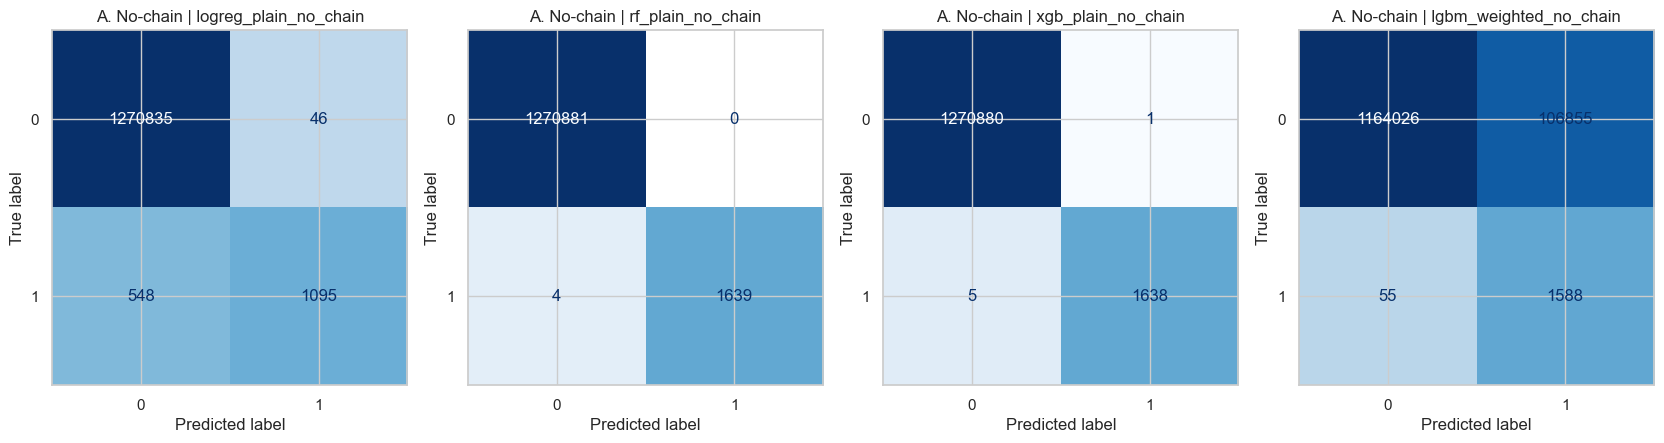

Part B: Chain-aware (selected models)


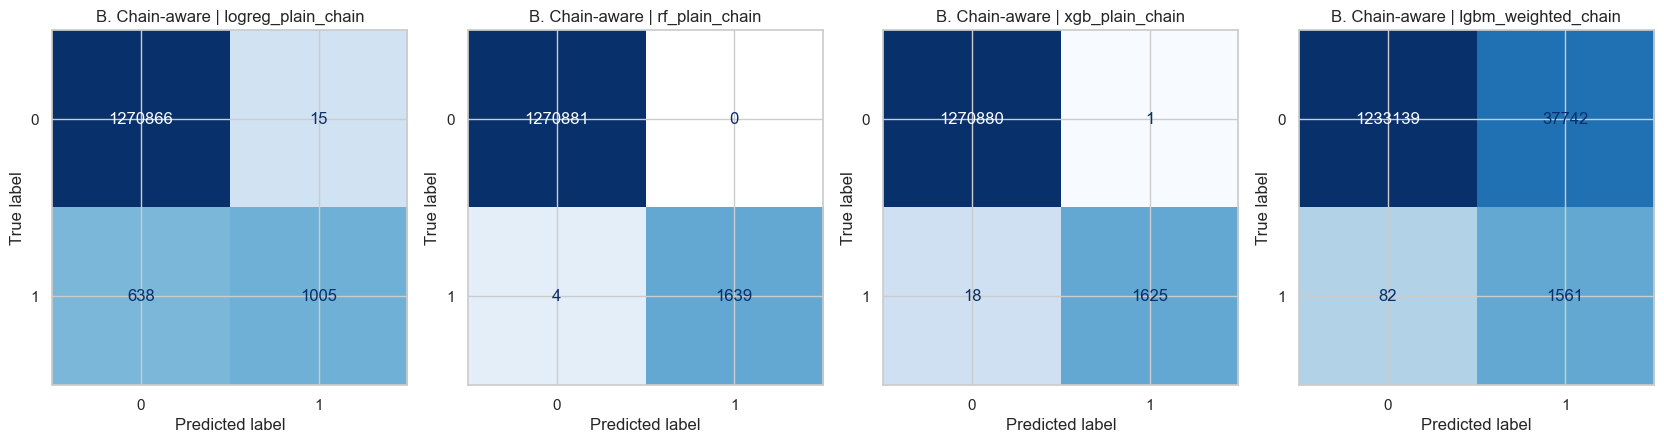

Part A (row-normalized): No-chain


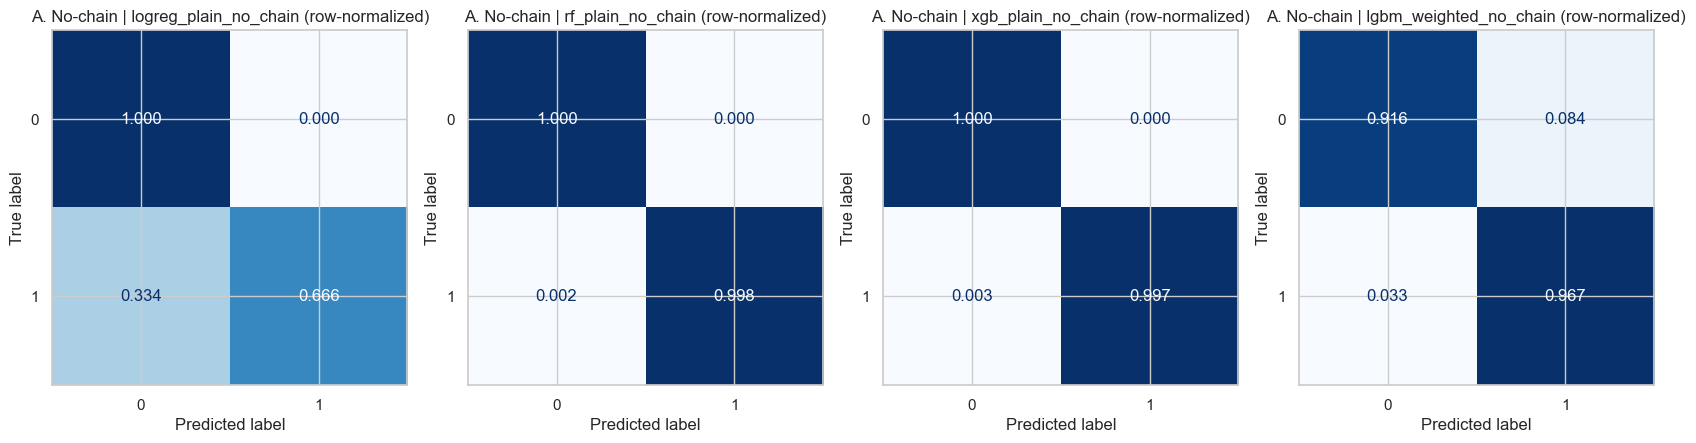

Part B (row-normalized): Chain-aware


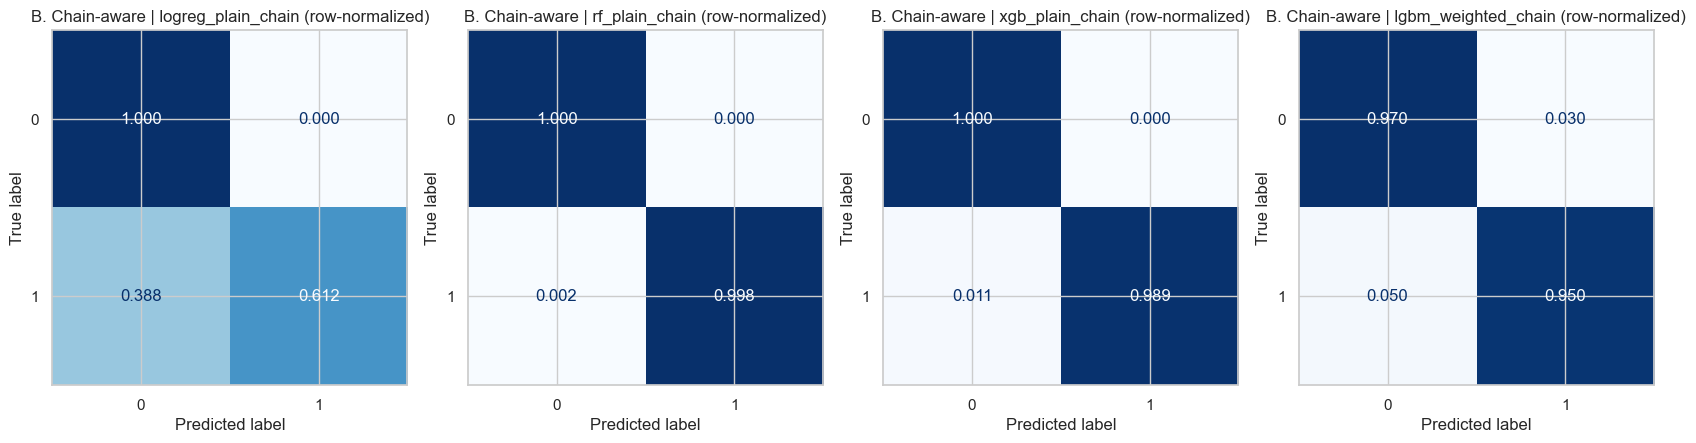

In [51]:
# Plot selected confusion matrices in two parts (A=no-chain, B=chain-aware).
from matplotlib.colors import LogNorm

# Use the same presentation set as the metric tables above.
selected_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

confusion_no_chain_sel = {k: confusion_no_chain[k] for k in selected_models if k in confusion_no_chain}
confusion_with_chain_sel = {k: confusion_with_chain[k] for k in selected_models if k in confusion_with_chain}

def plot_confusions_raw(confusion_dict, title_prefix, suffix):
    n = len(confusion_dict)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2))
    axes = np.array(axes).ravel()
    for ax, exp_name in zip(axes, confusion_dict.keys()):
        cm = confusion_dict[exp_name]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format="d",
            im_kw={"norm": LogNorm(vmin=1, vmax=max(1, cm.max()))},
        )
        ax.set_title(f"{title_prefix} | {exp_name}_{suffix}")
    plt.tight_layout()
    plt.show()

print("Part A: No-chain (selected models)")
plot_confusions_raw(confusion_no_chain_sel, "A. No-chain", "no_chain")
print("Part B: Chain-aware (selected models)")
plot_confusions_raw(confusion_with_chain_sel, "B. Chain-aware", "chain")

def plot_confusions_norm(confusion_dict, title_prefix, suffix):
    n = len(confusion_dict)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2))
    axes = np.array(axes).ravel()
    for ax, exp_name in zip(axes, confusion_dict.keys()):
        cm = confusion_dict[exp_name]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".3f")
        ax.set_title(f"{title_prefix} | {exp_name}_{suffix} (row-normalized)")
    plt.tight_layout()
    plt.show()

print("Part A (row-normalized): No-chain")
plot_confusions_norm(confusion_no_chain_sel, "A. No-chain", "no_chain")
print("Part B (row-normalized): Chain-aware")
plot_confusions_norm(confusion_with_chain_sel, "B. Chain-aware", "chain")


### 12.6 Setup-wise metric graphs (A vs B)

These graphs compare Recall, Precision, and PR-AUC for A (No-chain baseline) and B (Chain-aware).

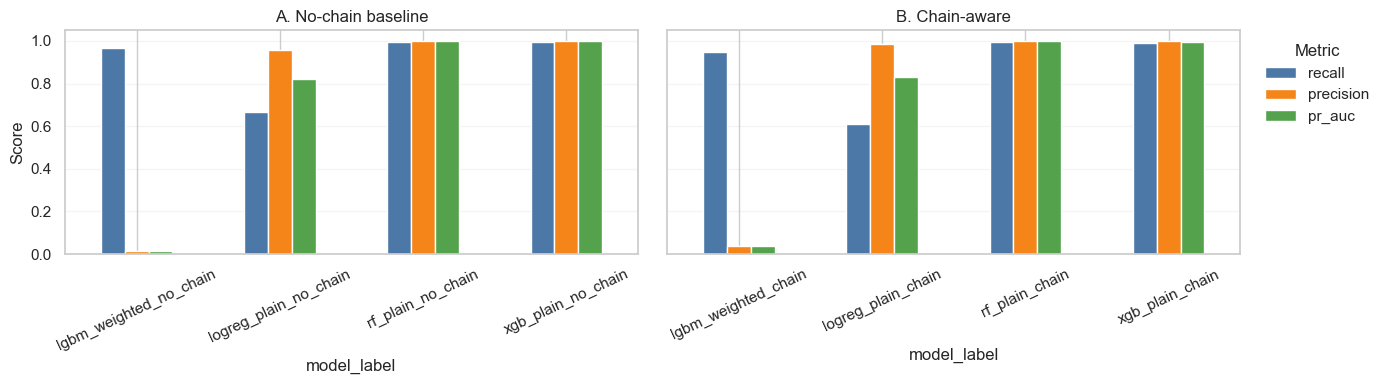

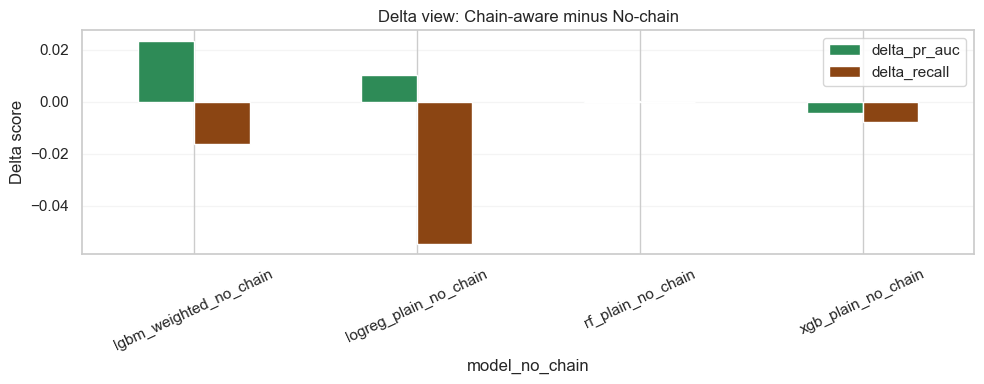

In [52]:
# Plot setup-wise bars for fraud-priority metrics and an explicit delta view.
focus_cols = ["recall", "precision", "pr_auc"]

report_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

metrics_no_chain_subset = metrics_no_chain[metrics_no_chain["experiment"].isin(report_models)].copy()
metrics_with_chain_subset = metrics_with_chain[metrics_with_chain["experiment"].isin(report_models)].copy()
chain_vs_no_chain_subset = chain_vs_no_chain_table[chain_vs_no_chain_table["experiment"].isin(report_models)].copy()

plot_no_chain = (
    metrics_no_chain_subset[["model_label"] + focus_cols]
    .set_index("model_label")
    .sort_index()
)
plot_with_chain = (
    metrics_with_chain_subset[["model_label"] + focus_cols]
    .set_index("model_label")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_no_chain.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("A. No-chain baseline")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.2)
axes[0].tick_params(axis="x", rotation=25)

plot_with_chain.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("B. Chain-aware")
axes[1].grid(axis="y", alpha=0.2)
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Metric")
axes[0].legend().remove()
plt.tight_layout()
plt.show()

delta_plot = chain_vs_no_chain_subset.set_index("model_no_chain")[["delta_pr_auc", "delta_recall"]]
ax = delta_plot.plot(kind="bar", figsize=(10, 4), color=["#2E8B57", "#8B4513"])
ax.set_title("Delta view: Chain-aware minus No-chain")
ax.set_ylabel("Delta score")
ax.grid(axis="y", alpha=0.2)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


### 12.6b ROC and PR curves by setup

We plot ROC and Precision-Recall curves separately for A (No-chain) and B (Chain-aware) on the same test split.

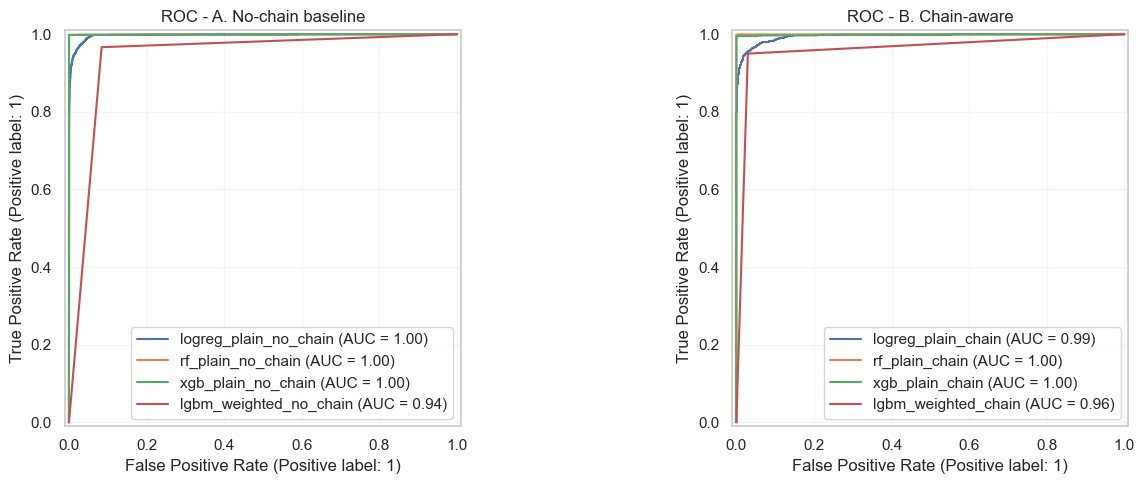

In [53]:
# Plot ROC curves separately for no-chain and chain-aware setups (presentation set only).
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
report_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

for exp_name in report_models:
    if exp_name in pred_store_no_chain:
        RocCurveDisplay.from_predictions(
            y_test,
            pred_store_no_chain[exp_name]["y_score"],
            ax=axes[0],
            name=f"{exp_name}_no_chain",
        )
axes[0].set_title("ROC - A. No-chain baseline")
axes[0].grid(alpha=0.2)

for exp_name in report_models:
    if exp_name in pred_store_with_chain:
        RocCurveDisplay.from_predictions(
            y_test,
            pred_store_with_chain[exp_name]["y_score"],
            ax=axes[1],
            name=f"{exp_name}_chain",
        )
axes[1].set_title("ROC - B. Chain-aware")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


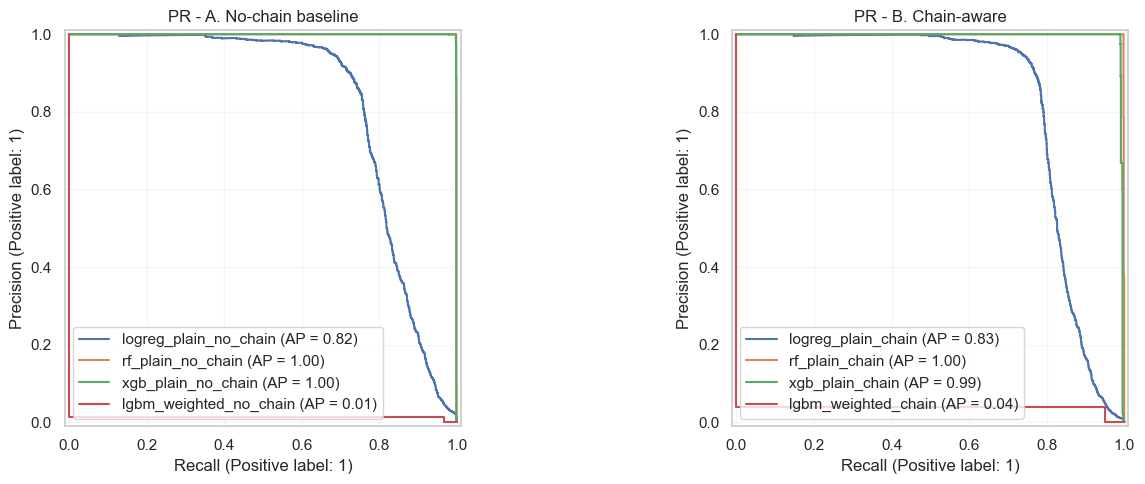

In [54]:
# Plot Precision-Recall curves separately for no-chain and chain-aware setups (presentation set only).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
report_models = REPORT_EXPERIMENTS if "REPORT_EXPERIMENTS" in globals() else ["logreg_plain", "rf_plain", "xgb_plain"]

for exp_name in report_models:
    if exp_name in pred_store_no_chain:
        PrecisionRecallDisplay.from_predictions(
            y_test,
            pred_store_no_chain[exp_name]["y_score"],
            ax=axes[0],
            name=f"{exp_name}_no_chain",
        )
axes[0].set_title("PR - A. No-chain baseline")
axes[0].grid(alpha=0.2)

for exp_name in report_models:
    if exp_name in pred_store_with_chain:
        PrecisionRecallDisplay.from_predictions(
            y_test,
            pred_store_with_chain[exp_name]["y_score"],
            ax=axes[1],
            name=f"{exp_name}_chain",
        )
axes[1].set_title("PR - B. Chain-aware")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


### 12.6c Quick interpretation of A vs B

- If `delta_pr_auc` and `delta_recall` are mostly positive, chain context adds useful fraud signal.
- If deltas are near zero, baseline features already capture most separability.
- Compare logistic deltas first because linear models usually reveal incremental feature value more clearly.
- Keep both setups in report: A = baseline evidence, B = novel chain-aware evidence.

### 12.7 Short plain-language summary (which model works better)

This summary follows project priority: **Recall -> Precision -> PR-AUC -> Confusion matrix -> F1 -> ROC-AUC**.

It reports the best models **within the notebook presentation set** (controlled by `REPORT_EXPERIMENTS`; default: `logreg_plain`, `rf_plain`, `xgb_plain`, `lgbm_weighted`). This keeps the discussion consistent with the A/B tables and plots shown above.


In [55]:
# Print concise answers focused on the notebook presentation set.
tbl = comparison_table.copy()

# Presentation control (manual): show only what you want in the report.
report_models = globals().get("REPORT_EXPERIMENTS", ["logreg_plain", "rf_plain", "xgb_plain"])
if "experiment" in tbl.columns:
    tbl = tbl[tbl["experiment"].isin(report_models)].copy()

def pick(metric):
    i = tbl[metric].idxmax()
    return tbl.loc[i, "experiment"], float(tbl.loc[i, metric])

best_recall = pick("recall")
best_precision = pick("precision")
best_pr_auc = pick("pr_auc")

def row(exp):
    m = tbl.loc[tbl["experiment"] == exp]
    if len(m) == 0:
        return None
    return m.iloc[0]

# Plain models (typically present in REPORT_EXPERIMENTS)
lr_p = row("logreg_plain")
rf_p = row("rf_plain")
xgb_p = row("xgb_plain")

# Optional variants (printed only if they are in the current REPORT_EXPERIMENTS)
lr_w = row("logreg_class_weight")
lr_s = row("logreg_smote")
rf_w = row("rf_class_weight")
rf_s = row("rf_smote")

print("Best recall:", best_recall[0], f"({best_recall[1]:.4f})")
print("Best precision:", best_precision[0], f"({best_precision[1]:.4f})")
print("Best PR-AUC:", best_pr_auc[0], f"({best_pr_auc[1]:.4f})")
print()

# Optional variant comparisons (only if those experiments are included in REPORT_EXPERIMENTS)
if lr_w is not None and lr_p is not None and rf_w is not None and rf_p is not None:
    print("Did class weights improve recall over plain? (within current REPORT_EXPERIMENTS)")
    print("- Logistic Regression:", lr_w["recall"] > lr_p["recall"], "|", round(float(lr_p["recall"]),4), "->", round(float(lr_w["recall"]),4))
    print("- Random Forest:", rf_w["recall"] > rf_p["recall"], "|", round(float(rf_p["recall"]),4), "->", round(float(rf_w["recall"]),4))
else:
    print("Class-weight variants not included in this REPORT_EXPERIMENTS view.")

if lr_s is not None and lr_p is not None and rf_s is not None and rf_p is not None:
    print()
    print("Did SMOTE improve recall over plain? (within current REPORT_EXPERIMENTS)")
    print("- Logistic Regression:", lr_s["recall"] > lr_p["recall"], "|", round(float(lr_p["recall"]),4), "->", round(float(lr_s["recall"]),4))
    print("- Random Forest:", rf_s["recall"] > rf_p["recall"], "|", round(float(rf_p["recall"]),4), "->", round(float(rf_s["recall"]),4))
else:
    print()
    print("SMOTE variants not included in this REPORT_EXPERIMENTS view.")

print()
if rf_p is not None and xgb_p is not None:
    print("XGBoost plain vs Random Forest plain (same chain-aware features and test set):")
    print("- Recall:", "RF", round(float(rf_p["recall"]),4), "| XGB", round(float(xgb_p["recall"]),4), "| RF higher?", float(rf_p["recall"]) > float(xgb_p["recall"]))
    print("- Precision:", "RF", round(float(rf_p["precision"]),4), "| XGB", round(float(xgb_p["precision"]),4), "| RF higher?", float(rf_p["precision"]) > float(xgb_p["precision"]))
    print("- PR-AUC:", "RF", round(float(rf_p["pr_auc"]),4), "| XGB", round(float(xgb_p["pr_auc"]),4), "| RF higher?", float(rf_p["pr_auc"]) > float(xgb_p["pr_auc"]))

print()
print("Recommendation for next stage:")
print("- Move forward with one high-recall model and one best precision-PR-AUC tradeoff model (within the current presentation set).")
print("- Next, tune decision threshold using business cost of false negatives vs false positives.")


Best recall: rf_plain (0.9976)
Best precision: rf_plain (1.0000)
Best PR-AUC: rf_plain (0.9985)

Class-weight variants not included in this REPORT_EXPERIMENTS view.

SMOTE variants not included in this REPORT_EXPERIMENTS view.

XGBoost plain vs Random Forest plain (same chain-aware features and test set):
- Recall: RF 0.9976 | XGB 0.989 | RF higher? True
- Precision: RF 1.0 | XGB 0.9994 | RF higher? True
- PR-AUC: RF 0.9985 | XGB 0.9937 | RF higher? True

Recommendation for next stage:
- Move forward with one high-recall model and one best precision-PR-AUC tradeoff model (within the current presentation set).
- Next, tune decision threshold using business cost of false negatives vs false positives.


### 12.7b RF vs XGBoost head-to-head (dynamic)

This section creates a direct **RF vs XGBoost** comparison from the current run so the winner is easy to present.

- It uses the same chain-aware setup and untouched test split used above.
- The plot is generated dynamically from notebook result tables (no hardcoded metric values).
- Positive deltas indicate **RF performs better** on that metric in this run.

Presentation note:
- For **PR-AUC / Recall / Precision / ROC-AUC / F1**, higher is better.
- For error counts (**FP**, **FN**), lower is better; deltas are direction-adjusted so positive still means RF is better.


,metric,rf,xgb,winner,rf_minus_xgb
0,PR-AUC,0.9985,0.9937,RF,0.0049
1,Recall,0.9976,0.9890,RF,0.0085
2,Precision,1.0000,0.9994,RF,0.0006
3,ROC-AUC,0.9996,0.9988,RF,0.0009
4,F1,0.9988,0.9942,RF,0.0046
5,FP (lower better),0.0000,1.0000,RF,1.0000
6,FN (lower better),4.0000,18.0000,RF,14.0000


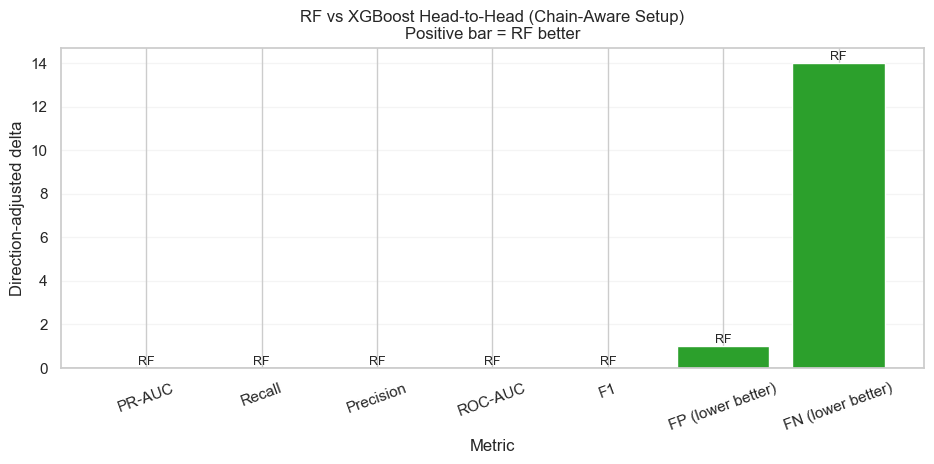

Winner count (this run): RF=7, XGB=0


In [56]:
# Dynamic RF vs XGBoost head-to-head chart (chain-aware setup)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["metrics_with_chain"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError("Run Section 12.4 first. Missing: " + ", ".join(missing))

need = ["rf_plain", "xgb_plain"]
sub = metrics_with_chain[metrics_with_chain["experiment"].isin(need)].copy()
if sub["experiment"].nunique() < 2:
    raise ValueError("Need both rf_plain and xgb_plain in metrics_with_chain.")

rf = sub[sub["experiment"] == "rf_plain"].iloc[0]
xgb = sub[sub["experiment"] == "xgb_plain"].iloc[0]

# Keep direction as "positive => RF better" for every bar.
comparison = pd.DataFrame([
    {"metric": "PR-AUC", "rf": float(rf["pr_auc"]), "xgb": float(xgb["pr_auc"]), "higher_better": True},
    {"metric": "Recall", "rf": float(rf["recall"]), "xgb": float(xgb["recall"]), "higher_better": True},
    {"metric": "Precision", "rf": float(rf["precision"]), "xgb": float(xgb["precision"]), "higher_better": True},
    {"metric": "ROC-AUC", "rf": float(rf["roc_auc"]), "xgb": float(xgb["roc_auc"]), "higher_better": True},
    {"metric": "F1", "rf": float(rf["f1"]), "xgb": float(xgb["f1"]), "higher_better": True},
    {"metric": "FP (lower better)", "rf": float(rf["fp"]), "xgb": float(xgb["fp"]), "higher_better": False},
    {"metric": "FN (lower better)", "rf": float(rf["fn"]), "xgb": float(xgb["fn"]), "higher_better": False},
])

comparison["rf_minus_xgb"] = np.where(
    comparison["higher_better"],
    comparison["rf"] - comparison["xgb"],
    comparison["xgb"] - comparison["rf"],
)
comparison["winner"] = np.where(comparison["rf_minus_xgb"] >= 0, "RF", "XGB")

# Table for report/PPT notes
display(comparison[["metric", "rf", "xgb", "winner", "rf_minus_xgb"]])

# Bar chart
plot_df = comparison.copy()
colors = np.where(plot_df["rf_minus_xgb"] >= 0, "#2ca02c", "#d62728")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar(plot_df["metric"], plot_df["rf_minus_xgb"], color=colors)
ax.axhline(0.0, color="#666666", linewidth=1)
ax.set_title("RF vs XGBoost Head-to-Head (Chain-Aware Setup)\nPositive bar = RF better")
ax.set_ylabel("Direction-adjusted delta")
ax.set_xlabel("Metric")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.2)

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(i, row["rf_minus_xgb"], f"{row['winner']}", ha="center", va="bottom" if row["rf_minus_xgb"] >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

rf_wins = int((comparison["winner"] == "RF").sum())
xgb_wins = int((comparison["winner"] == "XGB").sum())
print(f"Winner count (this run): RF={rf_wins}, XGB={xgb_wins}")


**Discussion (RF vs XGBoost head-to-head):**

- This section is a direct family comparison on the same chain-aware test setup.
- Positive direction-adjusted deltas mean RF performs better for that metric in the current run.
- We use this comparison to support model-family choice; calibration and final deployment choice are still handled separately in the next section.


### 12.7a Pipeline umbrella: dynamic shortlist and finalist policy

To keep this notebook reusable when new models are added, we use one transparent policy umbrella before calibration.

What is dynamic:

- Build a shortlist table from available chain-aware experiments using score-based metrics from `y_score`.
- Rank models by project priority (**Recall**, **PR-AUC**, then **ROC-AUC**).
- Select calibration finalists automatically: top **2** by default; include a **3rd** only when it is close enough to #2 by explicit thresholds.

What remains manual/governed:

- Final deployed model and business triage policy (kept explicit in later sections).
- Any policy threshold override must be documented in notebook text.


In [57]:
# Dynamic shortlist + calibration finalist selection policy.

from IPython.display import display
import pandas as pd

required = ["metrics_with_chain"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Section 12.4 first. Missing: " + ", ".join(missing))

shortlist_cols = ["experiment", "model_label", "recall", "pr_auc", "roc_auc", "precision", "f1"]
shortlist_tbl = metrics_with_chain.copy()
if "REPORT_EXPERIMENTS" in globals() and "experiment" in shortlist_tbl.columns:
    shortlist_tbl = shortlist_tbl[shortlist_tbl["experiment"].isin(REPORT_EXPERIMENTS)].copy()

shortlist_tbl = shortlist_tbl[shortlist_cols].sort_values(
    ["recall", "pr_auc", "roc_auc"], ascending=False
).reset_index(drop=True)

for m in ["recall", "pr_auc", "roc_auc"]:
    shortlist_tbl[f"rank_{m}"] = shortlist_tbl[m].rank(ascending=False, method="min").astype(int)

print("Score-based shortlist (chain-aware models; metrics derived from y_score)")
display(shortlist_tbl)

# ---- dynamic finalist policy (2 by default, 3 if #3 is close to #2) ----
MIN_FINALISTS = 2
MAX_FINALISTS = 3
THRESH_PR_AUC_GAP = 0.01
THRESH_RECALL_GAP = 0.01
MIN_PRECISION_FOR_OPTIONAL_3RD = 0.02

ranked = shortlist_tbl.sort_values(["rank_recall", "rank_pr_auc", "rank_roc_auc"]).reset_index(drop=True)
CALIBRATION_FINALISTS = ranked["experiment"].head(MIN_FINALISTS).tolist()
calibration_policy_reason = "Default top-2 finalists selected by rank."

if len(ranked) >= 3 and MAX_FINALISTS >= 3:
    second = ranked.iloc[1]
    third = ranked.iloc[2]
    pr_close = float(abs(second["pr_auc"] - third["pr_auc"])) <= THRESH_PR_AUC_GAP
    recall_close = float(abs(second["recall"] - third["recall"])) <= THRESH_RECALL_GAP
    precision_ok = float(third["precision"]) >= MIN_PRECISION_FOR_OPTIONAL_3RD

    if pr_close and recall_close and precision_ok:
        CALIBRATION_FINALISTS.append(third["experiment"])
        calibration_policy_reason = (
            f"Included 3rd model ({third['experiment']}) because it is close to #2 "
            f"(PR-AUC gap <= {THRESH_PR_AUC_GAP}, Recall gap <= {THRESH_RECALL_GAP}) "
            f"and precision >= {MIN_PRECISION_FOR_OPTIONAL_3RD}."
        )
    else:
        calibration_policy_reason = (
            "Kept top-2 only; #3 did not satisfy closeness/precision policy."
        )

print("Selected finalists for calibration:", CALIBRATION_FINALISTS)
print("Selection reason:", calibration_policy_reason)
print(
    "Policy thresholds:",
    {
        "THRESH_PR_AUC_GAP": THRESH_PR_AUC_GAP,
        "THRESH_RECALL_GAP": THRESH_RECALL_GAP,
        "MIN_PRECISION_FOR_OPTIONAL_3RD": MIN_PRECISION_FOR_OPTIONAL_3RD,
    },
)


Score-based shortlist (chain-aware models; metrics derived from y_score)


,experiment,model_label,recall,pr_auc,roc_auc,precision,f1,rank_recall,rank_pr_auc,rank_roc_auc
0,rf_plain,rf_plain_chain,0.9976,0.9985,0.9996,1.0000,0.9988,1,1,1
1,xgb_plain,xgb_plain_chain,0.9890,0.9937,0.9988,0.9994,0.9942,2,2,2
2,lgbm_weighted,lgbm_weighted_chain,0.9501,0.0378,0.9602,0.0397,0.0762,3,4,4
3,logreg_plain,logreg_plain_chain,0.6117,0.8321,0.9947,0.9853,0.7548,4,3,3


Selected finalists for calibration: ['rf_plain', 'xgb_plain']
Selection reason: Kept top-2 only; #3 did not satisfy closeness/precision policy.
Policy thresholds: {'THRESH_PR_AUC_GAP': 0.01, 'THRESH_RECALL_GAP': 0.01, 'MIN_PRECISION_FOR_OPTIONAL_3RD': 0.02}


### 12.8 Probability calibration (dynamic finalists from 12.7a policy)

This section calibrates the finalist list selected in **12.7a** (`CALIBRATION_FINALISTS`):

- Default: top **2** ranked chain-aware models.
- Optional: include top **3rd** model only if it meets the closeness policy to #2.

For each selected model we report:

- **Uncalibrated** probabilities taken directly from the already fitted model in 12.4.
- **`CalibratedClassifierCV`** with **`method="sigmoid"`** and **`method="isotonic"`**, trained on the same model-specific training matrix and evaluated on the same untouched test split.

**Metrics:** Brier score (lower is better), ROC-AUC, PR-AUC, and reliability diagrams.

**Note on runtime:** calibration uses **`cv=2`** here for practical runtime; increase to 3-5 for stricter folds.


Calibration is applied after model comparison/finalist selection so probabilities can be evaluated for decision-oriented use.
Sigmoid and isotonic calibration are both evaluated and compared using Brier score, PR-AUC, and ROC-AUC on the same untouched test split.


Calibration finalists used: ['rf_plain', 'xgb_plain']
Selection reason: Kept top-2 only; #3 did not satisfy closeness/precision policy.


,model,brier,roc_auc,pr_auc
0,rf_plain_uncalibrated,0.00000746,0.999645,0.998508
1,rf_plain_sigmoid,0.00000328,0.999645,0.998508
2,rf_plain_isotonic,0.00000334,0.999646,0.998239
3,xgb_plain_uncalibrated,0.00001428,0.998754,0.993653
4,xgb_plain_sigmoid,0.00001486,0.998754,0.993653
5,xgb_plain_isotonic,0.00001440,0.998300,0.993112


Note: Brier values are very small in this dataset, so 8 decimals are shown.


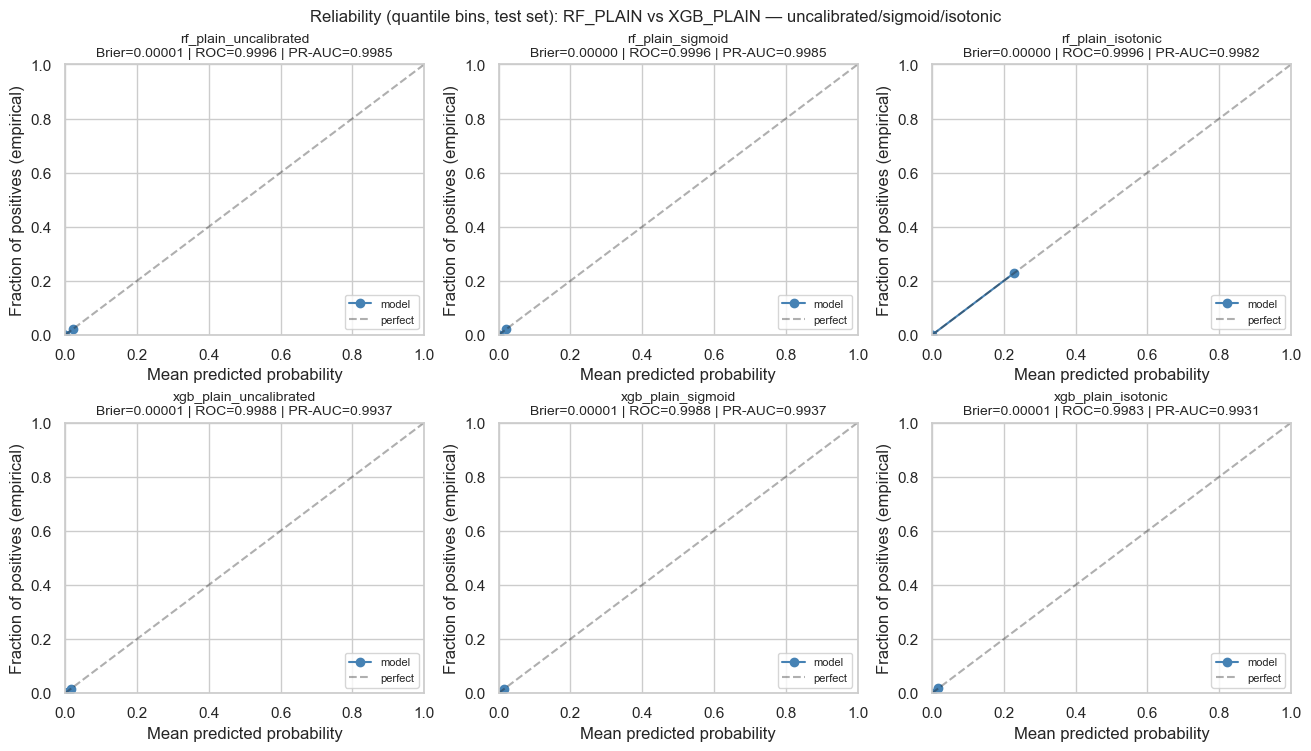

Calibration ranking (lower Brier first, then lower reliability-diagonal gap):
  rf_plain_sigmoid                  Brier=0.00000328  diag_gap=0.000018
  rf_plain_isotonic                 Brier=0.00000334  diag_gap=0.000059
  rf_plain_uncalibrated             Brier=0.00000746  diag_gap=0.000117
  xgb_plain_uncalibrated            Brier=0.00001428  diag_gap=0.000008
  xgb_plain_isotonic                Brier=0.00001440  diag_gap=0.000039
  xgb_plain_sigmoid                 Brier=0.00001486  diag_gap=0.000022

FINAL_MODEL_KEY: rf_plain_sigmoid
FINAL_MODEL_REASON: Selected rf_plain_sigmoid dynamically within RF family using lowest Brier (tol=1e-07), then highest PR-AUC, then highest ROC-AUC. Values => Brier=0.00000328, PR-AUC=0.998508, ROC-AUC=0.999645.
Recommended finalist for threshold tuning, triage, SHAP, and Streamlit: rf_plain_sigmoid


In [58]:
# Dynamic calibration for finalists selected in 12.7a.

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

CALIBRATION_CV = 2

required = [
    "Xte_ch",
    "y_test",
    "y_train",
    "experiments_with_chain",
    "pred_store_with_chain",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Section 12.4 first. Missing globals: " + ", ".join(missing))

if "CALIBRATION_FINALISTS" in globals() and isinstance(CALIBRATION_FINALISTS, list) and len(CALIBRATION_FINALISTS) > 0:
    finalists = [m for m in CALIBRATION_FINALISTS if m in experiments_with_chain and m in pred_store_with_chain]
else:
    finalists = [m for m in ["rf_plain", "xgb_plain"] if m in experiments_with_chain and m in pred_store_with_chain]

if len(finalists) < 2:
    raise ValueError("Need at least 2 valid finalists for calibration. Check Section 12.7a output.")

print("Calibration finalists used:", finalists)
if "calibration_policy_reason" in globals():
    print("Selection reason:", calibration_policy_reason)


def _metrics(y_true, proba_pos):
    return {
        "brier": float(brier_score_loss(y_true, proba_pos)),
        "roc_auc": float(roc_auc_score(y_true, proba_pos)),
        "pr_auc": float(average_precision_score(y_true, proba_pos)),
    }


def _reliability_ax(ax, y_true, proba_pos, title, n_bins=12):
    prob_true, prob_pred = calibration_curve(y_true, proba_pos, n_bins=n_bins, strategy="quantile")
    ax.plot(prob_pred, prob_true, "o-", color="steelblue", label="model")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.35, label="perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (empirical)")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


def _diag_mae(y_true, p, n_bins=12):
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="quantile")
    return float(np.mean(np.abs(prob_true - prob_pred)))


rows = []
probs_by_model = {}
NOTEBOOK_RF_CALIBRATORS_FOR_STREAMLIT = {}
plot_slots = []
desired_order = []

for row_idx, exp_name in enumerate(finalists):
    cfg = experiments_with_chain[exp_name]
    train_X, train_y = cfg["train_X"], cfg["train_y"]
    base_fitted = cfg["model"]

    p_unc = pred_store_with_chain[exp_name]["y_score"].astype(np.float64)
    lab_unc = f"{exp_name}_uncalibrated"
    m_unc = _metrics(y_test, p_unc)
    rows.append({"model": lab_unc, **m_unc})
    probs_by_model[lab_unc] = p_unc
    plot_slots.append((row_idx * 3 + 0, lab_unc, p_unc, m_unc))
    desired_order.append(lab_unc)

    for j, method in enumerate(["sigmoid", "isotonic"], start=1):
        cal = CalibratedClassifierCV(
            estimator=clone(base_fitted),
            method=method,
            cv=CALIBRATION_CV,
            n_jobs=1,
            ensemble=False,
        )
        cal.fit(train_X, train_y)
        p_cal = cal.predict_proba(Xte_ch)[:, 1].astype(np.float64)
        lab = f"{exp_name}_{method}"
        m = _metrics(y_test, p_cal)
        rows.append({"model": lab, **m})
        probs_by_model[lab] = p_cal
        if exp_name == "rf_plain":
            NOTEBOOK_RF_CALIBRATORS_FOR_STREAMLIT[lab] = cal
        plot_slots.append((row_idx * 3 + j, lab, p_cal, m))
        desired_order.append(lab)

calibration_comparison_table = pd.DataFrame(rows).set_index("model").loc[desired_order].reset_index()

calibration_display_table = calibration_comparison_table.copy()
calibration_display_table["brier"] = calibration_display_table["brier"].map(lambda x: f"{x:.8f}")
calibration_display_table["roc_auc"] = calibration_display_table["roc_auc"].map(lambda x: f"{x:.6f}")
calibration_display_table["pr_auc"] = calibration_display_table["pr_auc"].map(lambda x: f"{x:.6f}")
display(calibration_display_table)
print("Note: Brier values are very small in this dataset, so 8 decimals are shown.")

n_models = len(finalists)
fig, axes = plt.subplots(n_models, 3, figsize=(13, 3.7 * n_models), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax_idx, lab, probs, mdict in plot_slots:
    _reliability_ax(
        axes[ax_idx],
        y_test,
        probs,
        title=f"{lab}\nBrier={mdict['brier']:.5f} | ROC={mdict['roc_auc']:.4f} | PR-AUC={mdict['pr_auc']:.4f}",
    )

plt.suptitle(
    f"Reliability (quantile bins, test set): {' vs '.join([m.upper() for m in finalists])} — uncalibrated/sigmoid/isotonic",
    fontsize=12,
)
plt.show()

ranked = []
for lab in desired_order:
    p = probs_by_model[lab]
    b = float(calibration_comparison_table.set_index("model").loc[lab, "brier"])
    d = _diag_mae(y_test, p)
    ranked.append((b, d, lab))
ranked.sort(key=lambda t: (t[0], t[1]))
print("Calibration ranking (lower Brier first, then lower reliability-diagonal gap):")
for b, d, lab in ranked:
    print(f"  {lab:32s}  Brier={b:.8f}  diag_gap={d:.6f}")

def select_final_rf_calibrated_model(calibration_comparison_table, brier_close_tol=1e-7):
    tbl = calibration_comparison_table.copy().reset_index(drop=True)
    rf_candidates = ["rf_plain_uncalibrated", "rf_plain_sigmoid", "rf_plain_isotonic"]
    rf_tbl = tbl[tbl["model"].isin(rf_candidates)].copy()
    if rf_tbl.empty:
        raise ValueError("No RF calibration rows found for dynamic final model selection.")

    min_brier = float(rf_tbl["brier"].min())
    close_tbl = rf_tbl[rf_tbl["brier"] <= min_brier + float(brier_close_tol)].copy()
    close_tbl = close_tbl.sort_values(["pr_auc", "roc_auc"], ascending=[False, False]).reset_index(drop=True)

    final_row = close_tbl.iloc[0]
    final_key = str(final_row["model"])
    final_reason = (
        f"Selected {final_key} dynamically within RF family using "
        f"lowest Brier (tol={brier_close_tol:g}), then highest PR-AUC, then highest ROC-AUC. "
        f"Values => Brier={final_row['brier']:.8f}, PR-AUC={final_row['pr_auc']:.6f}, ROC-AUC={final_row['roc_auc']:.6f}."
    )
    return final_key, final_reason

FINAL_MODEL_KEY, FINAL_MODEL_REASON = select_final_rf_calibrated_model(calibration_comparison_table)
best = FINAL_MODEL_KEY

print()
print("FINAL_MODEL_KEY:", FINAL_MODEL_KEY)
print("FINAL_MODEL_REASON:", FINAL_MODEL_REASON)
print("Recommended finalist for threshold tuning, triage, SHAP, and Streamlit:", FINAL_MODEL_KEY)


### 12.8b How to use the recommendation

- **Threshold tuning / triage:** use the recommended row’s test probabilities as a starting point; refit the same calibrator choice on full train+valid if your course workflow requires it.
- **SHAP / Streamlit:** wrap the **same underlying estimator** (`rf_plain` or `xgb_plain`) plus the chosen **`CalibratedClassifierCV`** in your inference pipeline so displayed scores match offline evaluation.

### 12.9a Bootstrap Confidence Interval for Final Model PR-AUC

This section estimates uncertainty around the final model’s **PR-AUC** using bootstrap resampling on the untouched test set. Since PR-AUC is computed from a single split, the confidence interval helps show whether the measured performance is stable.


Final model for CI: rf_plain_sigmoid
Full test PR-AUC: 0.998508
Bootstrap PR-AUC mean: 0.998495
95% CI: [0.996656, 0.999876]
Valid bootstrap runs used: 300 / 300


,model,metric,point_estimate,bootstrap_mean,ci_lower,ci_upper,n_boot_valid
0,rf_plain_sigmoid,PR-AUC,0.9985,0.9985,0.9967,0.9999,300


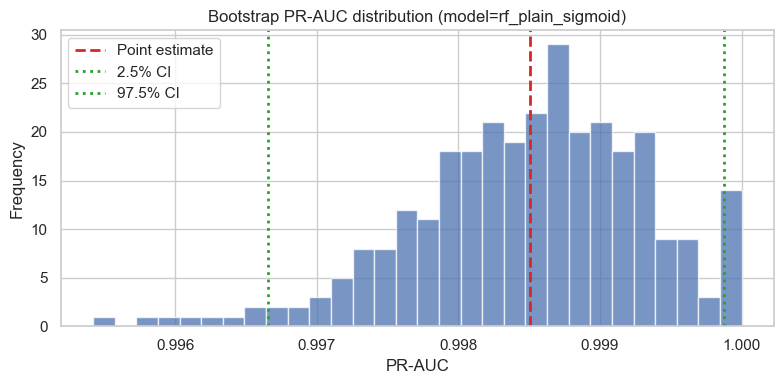

In [59]:
# Bootstrap PR-AUC confidence interval for the final deployed choice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

# Helper: bootstrap PR-AUC on the untouched test set
# Returns point estimate, bootstrap mean, 95% CI, and the number of valid bootstrap runs.

def bootstrap_pr_auc_ci(y_true, y_score, n_boot=300, random_state=42):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(np.float64)

    if y_true.shape[0] != y_score.shape[0]:
        raise ValueError("y_true and y_score must have the same length")

    n = len(y_true)
    rng = np.random.default_rng(random_state)

    point_estimate = float(average_precision_score(y_true, y_score))

    boot_scores = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n, endpoint=False)
        yb = y_true[idx]
        # Skip degenerate bootstrap samples where only one class is present.
        if np.unique(yb).size < 2:
            continue
        s = float(average_precision_score(yb, y_score[idx]))
        boot_scores.append(s)

    if len(boot_scores) == 0:
        raise ValueError("All bootstrap samples were degenerate (only one class).")

    boot_scores = np.asarray(boot_scores, dtype=np.float64)
    bootstrap_mean = float(np.mean(boot_scores))
    ci_lower = float(np.percentile(boot_scores, 2.5))
    ci_upper = float(np.percentile(boot_scores, 97.5))

    return point_estimate, bootstrap_mean, ci_lower, ci_upper, int(len(boot_scores))


# -----------------
# Identify final model probabilities (must match what Section 12.9b uses)
# -----------------
if "probs_by_model" not in globals():
    raise ValueError("Run calibration Section 12.8 first. Missing `probs_by_model`.")
if "y_test" not in globals():
    raise ValueError("Missing `y_test`. Run earlier evaluation sections first.")

# Dynamic deployed key selected in 12.8 inside RF family.
if "FINAL_MODEL_KEY" not in globals():
    raise ValueError("FINAL_MODEL_KEY missing. Re-run calibration section 12.8.")

deployed_prob_key = FINAL_MODEL_KEY

# Pick the notebook final probability vector.
if deployed_prob_key in probs_by_model:
    final_prob_key = deployed_prob_key
else:
    raise ValueError("Could not find FINAL_MODEL_KEY in `probs_by_model`. Re-run calibration section to define FINAL_MODEL_KEY.")

if final_prob_key != deployed_prob_key:
    print(
        f"Warning: confirm final probability source before reporting CI. "
        f"Notebook CI key={final_prob_key} vs deployed key={deployed_prob_key}."
    )

# Use existing untouched test labels and calibrated probabilities.
y_true = np.asarray(y_test).astype(int)
y_score = np.asarray(probs_by_model[final_prob_key], dtype=np.float64)

# Compute bootstrap CI
point_estimate, boot_mean, ci_lower, ci_upper, n_valid = bootstrap_pr_auc_ci(
    y_true=y_true,
    y_score=y_score,
    n_boot=300,
    random_state=42,
)

# Print results
print(f"Final model for CI: {final_prob_key}")
print(f"Full test PR-AUC: {point_estimate:.6f}")
print(f"Bootstrap PR-AUC mean: {boot_mean:.6f}")
print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"Valid bootstrap runs used: {n_valid} / 300")

# Summary table
ci_df = pd.DataFrame([
    {
        "model": final_prob_key,
        "metric": "PR-AUC",
        "point_estimate": point_estimate,
        "bootstrap_mean": boot_mean,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "n_boot_valid": n_valid,
    }
])

display(ci_df)

# Plot bootstrap distribution
# We recompute bootstrap PR-AUC values here so the histogram uses the same valid bootstrap samples.
# (The CI calculation above uses the same random_state, so this is deterministic.)

def _bootstrap_scores_for_hist(y_true, y_score, n_boot=300, random_state=42):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(np.float64)

    n = len(y_true)
    rng = np.random.default_rng(random_state)
    scores = []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n, endpoint=False)
        yb = y_true[idx]
        # Skip degenerate bootstrap samples where only one class is present.
        if np.unique(yb).size < 2:
            continue
        scores.append(float(average_precision_score(yb, y_score[idx])))
    return np.asarray(scores, dtype=np.float64)

boot_scores_for_hist = _bootstrap_scores_for_hist(y_true, y_score, n_boot=300, random_state=42)

plt.figure(figsize=(8, 4))
plt.hist(boot_scores_for_hist, bins=30, alpha=0.75)
plt.axvline(point_estimate, color="#d62728", linestyle="--", linewidth=2, label="Point estimate")
plt.axvline(ci_lower, color="#2ca02c", linestyle=":", linewidth=2, label="2.5% CI")
plt.axvline(ci_upper, color="#2ca02c", linestyle=":", linewidth=2, label="97.5% CI")
plt.title(f"Bootstrap PR-AUC distribution (model={final_prob_key})")
plt.xlabel("PR-AUC")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


**Discussion: interpreting the PR-AUC bootstrap confidence interval**

The CI is computed from repeated bootstrap resamples of the *same untouched test split*. It measures how much the measured PR-AUC could vary due to sampling variability.

- **Narrow CI**: your final model’s PR-AUC is relatively stable on the held-out test set.
- **Wide CI**: PR-AUC is sensitive to which rows are sampled; treat the performance as less certain.

Note: bootstrap runs that contain only one class are skipped automatically, so the CI uses only valid (non-degenerate) resamples.


### 12.9b Cost-sensitive threshold tuning and triage (final calibrated model)

We now use the **final calibrated model selected dynamically within the RF family** in Section 12.8 (`FINAL_MODEL_KEY`) on the same untouched chain-aware test set. The selected key and explanation are printed by the calibration cell (`FINAL_MODEL_KEY`, `FINAL_MODEL_REASON`).

This section does four things:
1. Searches thresholds from **0.05 to 0.95** (step 0.05) with business cost: `cost_fp = 5`, `cost_fn = 500`.
2. Picks the operating threshold with minimum total cost.
3. Builds a 3-bucket triage policy (**GREEN / YELLOW / RED**) from calibrated probabilities.
4. Applies chain escalation: if `is_chain_member == 1` and score is above a moderate cutoff, force bucket to **RED**.

**Bucket-rule clarity:** the thresholds printed in output are the exact thresholds used in bucket assignment:
- `GREEN` if score `< review_threshold`
- `YELLOW` if `review_threshold <= score < block_threshold`
- `RED` if score `>= block_threshold`

**After this section:** the code cell below ends with **§12.9c — Streamlit artifact sync** (same cell as triage). It writes `artifacts/*.joblib`, `artifacts/feature_metadata.json`, and refreshes `MODEL_CARD.md` §7–§8. Run Jupyter with **working directory = project root** (`Group_Project`).


,threshold,precision,recall,f1,tn,fp,fn,tp,total_cost
0,0.0500,0.9994,0.9976,0.9985,1270880,1,4,1639,2005
1,0.1000,0.9994,0.9976,0.9985,1270880,1,4,1639,2005
2,0.1500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
3,0.2000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
4,0.2500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
5,0.3000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
6,0.3500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
7,0.4000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
8,0.4500,1.0000,0.9976,0.9988,1270881,0,4,1639,2000
9,0.5000,1.0000,0.9976,0.9988,1270881,0,4,1639,2000


Chosen operating threshold (min cost): 0.15
At this threshold -> total_cost=2000, precision=1.0000, recall=0.9976, f1=0.9988
Triage thresholds -> GREEN < 0.05, YELLOW [0.05, 0.25), RED >= 0.25


,bucket,count,frauds,fraud_rate_pct
0,GREEN,1270884,4,0.0003
1,YELLOW,0,0,0.0000
2,RED,1640,1639,99.9390


,view,red_count,red_frauds,fraud_capture_in_red_pct
0,Before escalation,1639,1639,99.7565
1,After escalation,1640,1639,99.7565


Chain escalation impact:
- Additional rows escalated to RED: 1
- True frauds among escalated rows: 0
- Fraud capture in RED (before -> after): 
99.76% -> 99.76%


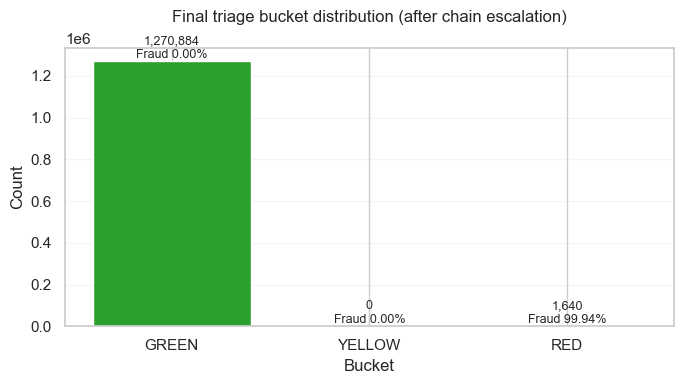

Streamlit artifact dir updated: /Users/snehasingh/ML/PaySim-Fraud-Triage/artifacts
Restart Streamlit to reload cached artifact load.


In [60]:
# Tune cost-sensitive threshold and build triage buckets using FINAL_MODEL_KEY calibrated scores.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

required = ["probs_by_model", "y_test", "X_test"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run 12.4 and 12.8 first. Missing: " + ", ".join(missing))

if "FINAL_MODEL_KEY" not in globals():
    raise ValueError("FINAL_MODEL_KEY missing. Re-run Section 12.8 calibration.")
if FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError(f"{FINAL_MODEL_KEY} probabilities not found. Re-run 12.8 calibration cell.")

# --- fixed business cost setup ---
cost_fp = 5
cost_fn = 500
threshold_grid = np.arange(0.05, 0.951, 0.05)

y_true = np.asarray(y_test).astype(int)
y_score = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)

# --- threshold search table ---
rows = []
for thr in threshold_grid:
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    rows.append({
        "threshold": float(thr),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total_cost": int(total_cost),
    })

threshold_search_table = pd.DataFrame(rows)
display(threshold_search_table)

# Choose operating threshold by minimum total cost; tie-break by higher recall then precision.
operating_row = threshold_search_table.sort_values(
    ["total_cost", "recall", "precision"], ascending=[True, False, False]
).iloc[0]
operating_threshold = float(operating_row["threshold"])
print(f"Chosen operating threshold (min cost): {operating_threshold:.2f}")
print(
    f"At this threshold -> total_cost={int(operating_row['total_cost'])}, "
    f"precision={operating_row['precision']:.4f}, recall={operating_row['recall']:.4f}, f1={operating_row['f1']:.4f}"
)

# --- triage buckets from calibrated probabilities ---
review_threshold = max(0.05, round(operating_threshold - 0.10, 2))
block_threshold = min(0.95, round(operating_threshold + 0.10, 2))
moderate_cutoff = review_threshold

base_bucket = np.where(
    y_score < review_threshold,
    "GREEN",
    np.where(y_score < block_threshold, "YELLOW", "RED")
)

# --- chain escalation rule ---
if "is_chain_member" not in X_test.columns:
    raise ValueError("X_test must contain is_chain_member for escalation rule.")

is_chain_member_test = X_test["is_chain_member"].to_numpy().astype(int)
escalate_mask = (
    (base_bucket != "RED")
    & (is_chain_member_test == 1)
    & (y_score >= moderate_cutoff)
)
final_bucket = base_bucket.copy()
final_bucket[escalate_mask] = "RED"

# --- bucket table (final policy) ---
# Always include GREEN, YELLOW, RED in order, even when one bucket has zero rows.
triage_bucket_table = (
    pd.DataFrame({"bucket": final_bucket, "isFraud": y_true})
    .groupby("bucket", as_index=False)
    .agg(count=("isFraud", "size"), frauds=("isFraud", "sum"))
    .set_index("bucket")
    .reindex(["GREEN", "YELLOW", "RED"], fill_value=0)
    .reset_index()
)
triage_bucket_table["fraud_rate_pct"] = np.where(
    triage_bucket_table["count"] > 0,
    triage_bucket_table["frauds"] / triage_bucket_table["count"] * 100,
    0.0,
)
print(
    f"Triage thresholds -> GREEN < {review_threshold:.2f}, "
    f"YELLOW [{review_threshold:.2f}, {block_threshold:.2f}), RED >= {block_threshold:.2f}"
)
display(triage_bucket_table)

# --- escalation impact report ---
additional_escalated = int(escalate_mask.sum())
escalated_true_frauds = int(((y_true == 1) & escalate_mask).sum())

before_red_frauds = int(((y_true == 1) & (base_bucket == "RED")).sum())
after_red_frauds = int(((y_true == 1) & (final_bucket == "RED")).sum())
total_frauds = int((y_true == 1).sum())

fraud_capture_before_pct = 100 * before_red_frauds / max(total_frauds, 1)
fraud_capture_after_pct = 100 * after_red_frauds / max(total_frauds, 1)

triage_summary_table = pd.DataFrame([
    {
        "view": "Before escalation",
        "red_count": int((base_bucket == "RED").sum()),
        "red_frauds": before_red_frauds,
        "fraud_capture_in_red_pct": fraud_capture_before_pct,
    },
    {
        "view": "After escalation",
        "red_count": int((final_bucket == "RED").sum()),
        "red_frauds": after_red_frauds,
        "fraud_capture_in_red_pct": fraud_capture_after_pct,
    },
])
display(triage_summary_table)

print("Chain escalation impact:")
print(f"- Additional rows escalated to RED: {additional_escalated:,}")
print(f"- True frauds among escalated rows: {escalated_true_frauds:,}")
print(
    "- Fraud capture in RED (before -> after): \n"
    f"{fraud_capture_before_pct:.2f}% -> {fraud_capture_after_pct:.2f}%"
)

# --- simple final triage distribution chart ---
plot_df = triage_bucket_table.copy()
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"GREEN": "#2ca02c", "YELLOW": "#ffbf00", "RED": "#d62728"}
ax.bar(plot_df["bucket"].astype(str), plot_df["count"], color=[colors[b] for b in plot_df["bucket"].astype(str)])
ax.set_title("Final triage bucket distribution (after chain escalation)\n")
ax.set_xlabel("Bucket")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.2)
for i, r in plot_df.iterrows():
    ax.text(i, r["count"], f"{int(r['count']):,}\nFraud {r['fraud_rate_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# --- Sync Streamlit artifacts + feature_metadata + MODEL_CARD §7–§8 (run Jupyter with cwd = project root) ---
from pathlib import Path

import streamlit_notebook_export as sexp

_boot = None
_req = ("point_estimate", "boot_mean", "ci_lower", "ci_upper", "n_valid")
if all(k in globals() for k in _req):
    _boot = {
        "pr_auc_point": float(point_estimate),
        "pr_auc_bootstrap_mean": float(boot_mean),
        "ci_lower": float(ci_lower),
        "ci_upper": float(ci_upper),
        "valid_runs": int(n_valid),
        "n_boot_requested": 300,
    }

_out = sexp.sync_from_notebook_session(
    preprocessor=preprocessor,
    rf_base_model=experiments_with_chain["rf_plain"]["model"],
    x_train_columns=list(X_train.columns),
    processed_feature_names=list(preprocessor.get_feature_names_out()),
    final_model_key=FINAL_MODEL_KEY,
    final_model_reason=FINAL_MODEL_REASON,
    calibration_comparison_table=calibration_comparison_table,
    rf_calibrator_by_key=NOTEBOOK_RF_CALIBRATORS_FOR_STREAMLIT,
    triage_thresholds={
        "operating_threshold": float(operating_threshold),
        "review_threshold": float(review_threshold),
        "block_threshold": float(block_threshold),
        "moderate_cutoff": float(moderate_cutoff),
    },
    chain_size_cap=int(globals().get("CHAIN_SIZE_CAP", 12)),
    y_true=y_true,
    final_bucket_labels=final_bucket,
    base_bucket_labels=base_bucket,
    bootstrap_prauc=_boot,
    cost_fp=cost_fp,
    cost_fn=cost_fn,
    project_root=Path.cwd(),
    rewrite_model_card=True,
)

import joblib

best_calibrated_model = joblib.load(_out / "rf_selected_calibrated.joblib")

print("Streamlit artifact dir updated:", _out)
print("Restart Streamlit to reload cached artifact load.")


### 12.10 SHAP explainability (final deployed choice: RF + dynamic calibration within RF family)

For deployment we use the dynamically selected calibrated RF model (`FINAL_MODEL_KEY`), but SHAP should explain the **base estimator features**. So we explain the underlying `rf_plain` model on the same **chain-aware processed matrix** from Section 12.4.

This section has two parts:
1. **Global explanation:** SHAP summary plot on a manageable chain-aware test sample.
2. **Local explanation:** one high-risk fraud and one low-risk legitimate case, reporting calibrated probability, triage bucket, true label, and top contributing features.


SHAP supports interpretation of model behavior, but it is not proof of causality.


SHAP explains base rf_plain feature contributions; calibrated rf_plain_sigmoid is used for probability/triage context only.
Note: processed_value is from the processed/scaled feature matrix (not raw original units).


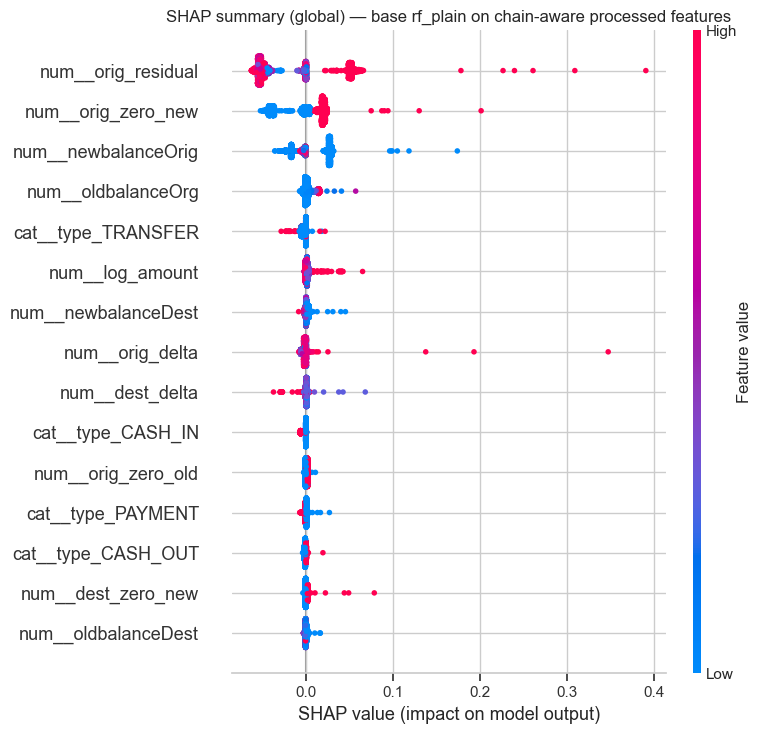

Local example metadata:


,example,test_row_position,true_label,calibrated_probability,final_triage_bucket
0,high_risk_fraud,14189,1,1.0000,RED
1,low_risk_legit,1,0,0.0000,GREEN



Top contributing features for high_risk_fraud (test_row_position 14189):


,feature,shap_value,abs_shap,processed_value
0,num__orig_delta,0.2503,0.2503,25.7414
1,num__is_chain_member,0.2167,0.2167,30.8173
2,num__orig_residual,0.1472,0.1472,0.3323
3,num__chain_size,0.0683,0.0683,0.0389
4,num__newbalanceOrig,0.0674,0.0674,-0.2925
5,num__oldbalanceOrg,0.0513,0.0513,1.0108
6,num__log_amount,0.0510,0.0510,2.3680
7,num__orig_zero_new,0.0491,0.0491,0.8733



Top contributing features for low_risk_legit (test_row_position 1):


,feature,shap_value,abs_shap,processed_value
0,num__oldbalanceOrg,0.0135,0.0135,0.4372
1,cat__type_CASH_IN,-0.0060,0.0060,1.0000
2,num__orig_delta,-0.0040,0.0040,-0.5220
3,num__newbalanceOrig,-0.0029,0.0029,0.4580
4,cat__type_TRANSFER,-0.0028,0.0028,0.0000
5,num__orig_zero_new,-0.0025,0.0025,-1.1451
6,num__newbalanceDest,0.0014,0.0014,-0.2726
7,num__dest_delta,0.0010,0.0010,-0.2739



Interpretation (chain-feature visibility):
- Chain-aware features are not in the top 15 global SHAP drivers in this run; the model relies more on other transaction/balance/type features.
- Type one-hot columns and balance-based numeric features remain key explainability anchors.


In [61]:
# Compute global and local SHAP explanations for base rf_plain, while reporting calibrated outputs.
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# If needed, install first: pip install shap
# If SHAP is missing in your environment, run: pip install shap
try:
    import shap
except ImportError as e:
    raise ImportError("SHAP is not installed. Run: pip install shap") from e

required = [
    "experiments_with_chain", "Xte_ch", "y_test", "preprocessor",
    "probs_by_model", "final_bucket"
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run 12.4, 12.8, and 12.9b first. Missing: " + ", ".join(missing))

if "rf_plain" not in experiments_with_chain:
    raise ValueError("rf_plain not found in experiments_with_chain. Re-run 12.4.")
if FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError(f"{FINAL_MODEL_KEY} calibrated probabilities not found. Re-run 12.8.")

print(f"SHAP explains base rf_plain feature contributions; calibrated {FINAL_MODEL_KEY} is used for probability/triage context only.")
print("Note: processed_value is from the processed/scaled feature matrix (not raw original units).")
rf_base_model = experiments_with_chain["rf_plain"]["model"]
X_test_chain = np.asarray(Xte_ch, dtype=np.float64)
y_true = np.asarray(y_test).astype(int)
calibrated_probs = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
triage_bucket = np.asarray(final_bucket).astype(str)

# Use fitted feature names from the actual chain-aware preprocessing pipeline.
proc_feature_names = list(preprocessor.get_feature_names_out())

if len(proc_feature_names) != X_test_chain.shape[1]:
    raise ValueError(
        f"Feature-name length mismatch: {len(proc_feature_names)} names vs {X_test_chain.shape[1]} columns."
    )

X_test_chain_df = pd.DataFrame(X_test_chain, columns=proc_feature_names)

# ------------------------
# Part 1: Global SHAP
# ------------------------
SHAP_SAMPLE_N = 5000
rng = np.random.default_rng(42)
if len(X_test_chain_df) > SHAP_SAMPLE_N:
    sample_idx = np.sort(rng.choice(len(X_test_chain_df), size=SHAP_SAMPLE_N, replace=False))
else:
    sample_idx = np.arange(len(X_test_chain_df))

X_shap_sample = X_test_chain_df.iloc[sample_idx]
explainer = shap.TreeExplainer(rf_base_model)
shap_values_raw = explainer.shap_values(X_shap_sample)

# Handle SHAP output format across versions.
if isinstance(shap_values_raw, list):
    shap_values_sample = shap_values_raw[1]
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values_sample = shap_values_raw[:, :, 1]
else:
    shap_values_sample = shap_values_raw

plt.figure(figsize=(11, 6))
shap.summary_plot(
    shap_values_sample,
    X_shap_sample,
    feature_names=proc_feature_names,
    max_display=15,
    show=False,
)
plt.title("SHAP summary (global) — base rf_plain on chain-aware processed features")
plt.tight_layout()
plt.show()

# ------------------------
# Part 2: Local SHAP
# ------------------------
fraud_mask = y_true == 1
legit_mask = y_true == 0

if fraud_mask.sum() == 0 or legit_mask.sum() == 0:
    raise ValueError("Need both fraud and legitimate rows in y_test for local examples.")

high_risk_fraud_idx = np.where(fraud_mask)[0][np.argmax(calibrated_probs[fraud_mask])]
low_risk_legit_idx = np.where(legit_mask)[0][np.argmin(calibrated_probs[legit_mask])]
local_indices = [int(high_risk_fraud_idx), int(low_risk_legit_idx)]
local_labels = ["high_risk_fraud", "low_risk_legit"]

X_local = X_test_chain_df.iloc[local_indices]
shap_local_raw = explainer.shap_values(X_local)
if isinstance(shap_local_raw, list):
    shap_local = shap_local_raw[1]
elif isinstance(shap_local_raw, np.ndarray) and shap_local_raw.ndim == 3:
    shap_local = shap_local_raw[:, :, 1]
else:
    shap_local = shap_local_raw

local_rows = []
for i, idx in enumerate(local_indices):
    svals = shap_local[i]
    # Start from global top-|SHAP| features, then make local display more human-readable.
    top_idx = list(np.argsort(np.abs(svals))[::-1][:8])

    # Prefer the active one-hot transaction type (value 1) over inactive type dummies (value 0).
    row_vals = X_test_chain_df.iloc[idx].to_numpy()
    active_type_idx = [
        j for j, name in enumerate(proc_feature_names)
        if name.startswith("cat__type_") and row_vals[j] > 0.5
    ]
    active_type_idx = active_type_idx[0] if active_type_idx else None

    if active_type_idx is not None:
        has_inactive_type_in_top = any(
            proc_feature_names[j].startswith("cat__type_") and row_vals[j] < 0.5
            for j in top_idx
        )
        if has_inactive_type_in_top and active_type_idx not in top_idx:
            # Replace the weakest inactive type feature with the active type feature.
            inactive_type_positions = [
                k for k, j in enumerate(top_idx)
                if proc_feature_names[j].startswith("cat__type_") and row_vals[j] < 0.5
            ]
            if inactive_type_positions:
                # choose inactive type with smallest |SHAP| among selected top features
                replace_pos = min(inactive_type_positions, key=lambda k: abs(svals[top_idx[k]]))
                top_idx[replace_pos] = active_type_idx

    top_feats = [
        {
            "feature": proc_feature_names[j],
            "shap_value": float(svals[j]),
            "abs_shap": float(abs(svals[j])),
            "processed_value": float(row_vals[j]),
        }
        for j in top_idx
    ]

    local_rows.append(
        {
            "example": local_labels[i],
            "test_row_position": int(idx),
            "true_label": int(y_true[idx]),
            "calibrated_probability": float(calibrated_probs[idx]),
            "final_triage_bucket": triage_bucket[idx],
            "top_contributors": top_feats,
        }
    )

print("Local example metadata:")
local_meta = pd.DataFrame([
    {
        "example": r["example"],
        "test_row_position": r["test_row_position"],
        "true_label": r["true_label"],
        "calibrated_probability": r["calibrated_probability"],
        "final_triage_bucket": r["final_triage_bucket"],
    }
    for r in local_rows
])
display(local_meta)

for r in local_rows:
    print(f"\nTop contributing features for {r['example']} (test_row_position {r['test_row_position']}):")
    display(pd.DataFrame(r["top_contributors"]).sort_values("abs_shap", ascending=False).reset_index(drop=True))

# ------------------------
# Short interpretation block
# ------------------------
mean_abs_shap = np.abs(shap_values_sample).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": proc_feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

top15 = importance_df.head(15)["feature"].tolist()
chain_feats = ["num__is_chain_member", "num__chain_size"]
chain_in_top = [f for f in chain_feats if f in top15]

print("\nInterpretation (chain-feature visibility):")
if chain_in_top:
    print(
        "- Chain-aware features appear among global important drivers:",
        ", ".join(chain_in_top),
        "(top 15 by mean |SHAP|)."
    )
else:
    print(
        "- Chain-aware features are not in the top 15 global SHAP drivers in this run; "
        "the model relies more on other transaction/balance/type features."
    )

print("- Type one-hot columns and balance-based numeric features remain key explainability anchors.")


In [62]:
# Live final-model selection values from this run (set in Section 12.8)
if "FINAL_MODEL_KEY" not in globals() or "FINAL_MODEL_REASON" not in globals():
    raise ValueError("FINAL_MODEL_KEY/FINAL_MODEL_REASON missing. Re-run Section 12.8 calibration.")

print(f"Final calibrated model key: {FINAL_MODEL_KEY}")
print(f"Selection reason: {FINAL_MODEL_REASON}")

Final calibrated model key: rf_plain_sigmoid
Selection reason: Selected rf_plain_sigmoid dynamically within RF family using lowest Brier (tol=1e-07), then highest PR-AUC, then highest ROC-AUC. Values => Brier=0.00000328, PR-AUC=0.998508, ROC-AUC=0.999645.


### 12.11 Model selection verdict (pre-drift check)

**Final deployed choice:** use the **chain-aware Random Forest with dynamically selected RF-family calibration** (`FINAL_MODEL_KEY`).

- The final calibrated deployment path is selected dynamically within the Random Forest family based on calibration results in this run.
- Live selected values (`FINAL_MODEL_KEY`, `FINAL_MODEL_REASON`) are printed in the code cell directly above.

**Why this model:**
- The final calibrated deployment path is selected dynamically within the RF family using `FINAL_MODEL_KEY` and `FINAL_MODEL_REASON` (lowest Brier, then higher PR-AUC, then higher ROC-AUC), while keeping the same threshold/triage pipeline structure.
- Cost-based threshold tuning with `cost_fp = 5` and `cost_fn = 500` selected a stable operating threshold for action-oriented decisions.

**Triage policy (GREEN / YELLOW / RED):**
- We map calibrated probabilities to business buckets and then apply the chain-escalation rule.
- In this run, risk separation is very strong, so most rows fall directly into GREEN or RED (YELLOW appears explicitly, but may be sparse/empty).

**Chain escalation impact (this run):**
- Escalation moved a very small number of extra rows to RED and did **not** increase fraud capture, so incremental gain is minimal in this calibrated RF setup.

**Explainability conclusion (SHAP):**
- **Global** SHAP summary often emphasizes balance and type features first; chain columns may or may not land in the top-15 mean-|SHAP| list in a given run. **Local** SHAP (and optional LIME in §14.2) can still surface chain-related signals on specific decisions — consistent with using chain features as model inputs.

**Deployment-ready next step:**
- Package the same preprocessor + calibrated model + triage rules into Streamlit so scoring outputs are consistent with notebook evaluation.


**What worked:** chain-aware modeling, calibration, and cost-sensitive triage produced strong fraud-focused performance and operationally interpretable outputs.
**What remained difficult:** a small number of non-chain or weaker-signal fraud cases were still missed, and a small number of suspicious legitimate transactions were sent to RED.


### 12.12 Streamlit transparency design (pre-drift check)

To keep user-facing decisions trustworthy and easy to audit, the deployed Streamlit app (`app.py`) uses:

- **Decision policy (rule-based):** calibrated probability + triage thresholds + chain escalation rule.
  - `GREEN` if probability < review threshold.
  - `YELLOW` if review threshold <= probability < block threshold.
  - `RED` if probability >= block threshold, or if chain escalation condition fires.
- **Explanation policy (model-based):** **local SHAP** for each transaction to show risk-up and risk-down drivers.

Clarification on SHAP scope:

- **Global SHAP** (summary plots in this notebook) explains overall model behavior across many rows.
- **Local SHAP** (used in Streamlit per prediction) explains *this specific decision* for one transaction.

This split is intentional: global SHAP supports model validation/reporting, while local SHAP supports user confidence and operational triage decisions.


The Streamlit app is an interactive inference interface for demo use, not a production streaming service.


## 13. Data Drift Analysis

This section checks whether data behavior changes between **early timeline** and **late timeline** windows, and whether shifts are large enough to impact model reliability.

We use:

- **Early window:** `step <= 400`
- **Late window:** `step > 400`

### How Drift Monitor computes (important)

Notebook logic and Streamlit tab follow same monitoring idea:

1. Read current dataset and split into early/late windows.
2. Recompute feature-engineered fields used for drift checks (for example: `orig_delta`, `orig_residual`, chain fields).
3. Compute **PSI** per monitored feature:
   - Numeric features -> quantile-bin PSI.
   - Binary feature (`is_chain_member`) -> binary PSI.
4. Score both windows with current deployed pipeline and compute **PR-AUC early vs late**.
5. Raise monitor signal:
   - Feature drift signal from PSI bands.
   - Performance drift signal from `abs(PR_AUC_early - PR_AUC_late)`.

### Dynamic behavior in Streamlit

- Drift tab is **dynamic at run time**: when user clicks **Run drift calculations now**, app recomputes PSI and PR-AUC drift from loaded data.
- Slider/seed controls change sampled rows and recompute values.
- Optional demo toggle can inject synthetic shift for presentation.

### Cache caveat (operational note)

Streamlit drift loader uses cached data for speed.
If source CSV changes (for example tomorrow's drifted data), safest flow is:

1. update/replace CSV,
2. restart Streamlit (or clear cache),
3. click **Run drift calculations now** again.

This is a **monitoring** section only. We do **not** retrain here.

early shape: (5787030, 11)
late shape : (575590, 11)
early fraud rate: 0.0774%
late fraud rate : 0.6491%


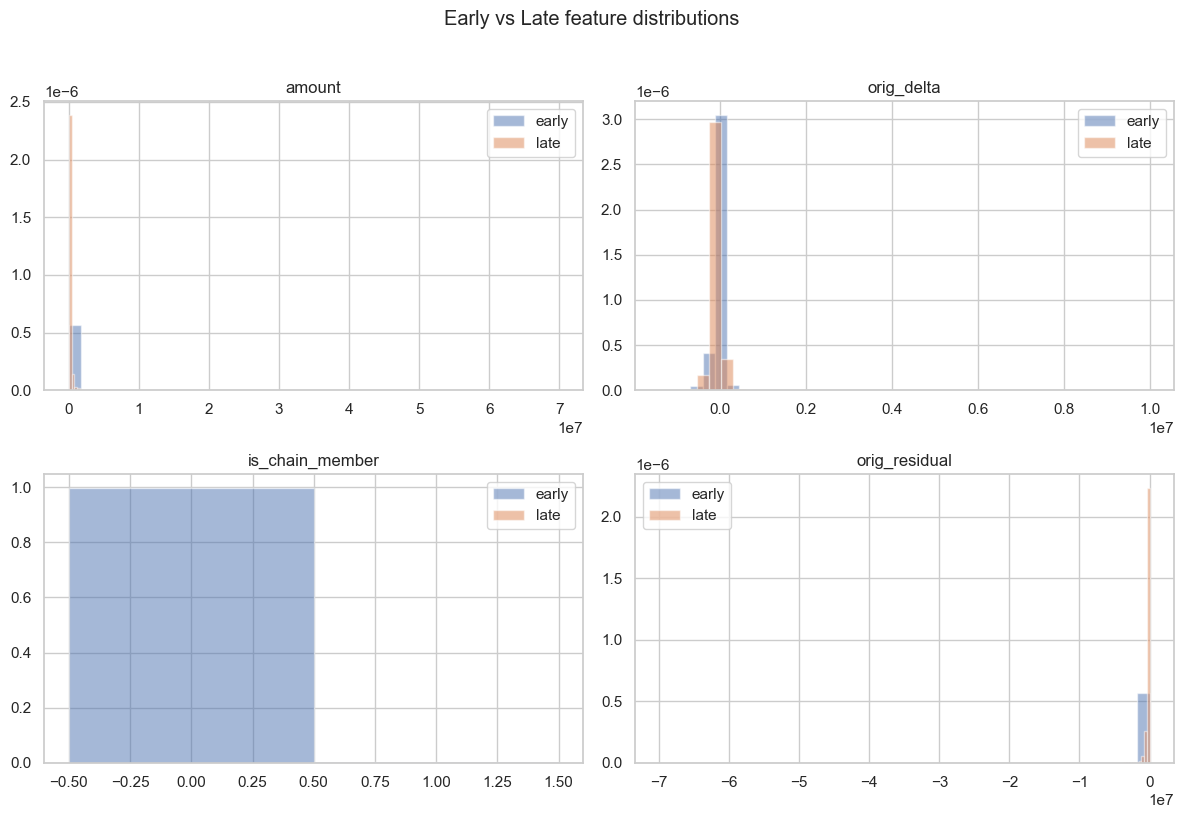


PSI table:
        feature    psi status
is_chain_member 0.0052  GREEN
  orig_residual 0.0042  GREEN
     orig_delta 0.0039  GREEN
         amount 0.0034  GREEN


In [63]:
# Step 1/2/3: early-vs-late split, distribution comparison, and PSI table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Split by timeline
early = df[df['step'] <= 400].copy()
late = df[df['step'] > 400].copy()

print('early shape:', early.shape)
print('late shape :', late.shape)
print(f"early fraud rate: {early['isFraud'].mean():.4%}")
print(f"late fraud rate : {late['isFraud'].mean():.4%}")

# Build features used in drift check
for _d in (early, late):
    _d['orig_delta'] = _d['oldbalanceOrg'] - _d['newbalanceOrig']
    _d['orig_residual'] = _d['orig_delta'] - _d['amount']

# Lightweight chain proxy consistent with project feature logic (no labels used)
for _d in (early, late):
    cg = (_d.groupby(['step', 'amount'], as_index=False)
            .agg(chain_size=('type', 'size'),
                 has_transfer=('type', lambda s: (s == 'TRANSFER').any()),
                 has_cash_out=('type', lambda s: (s == 'CASH_OUT').any())))
    cg['is_chain_member'] = ((cg['has_transfer'] & cg['has_cash_out']) & (cg['chain_size'] <= 12)).astype(np.int8)
    _d.merge(cg[['step', 'amount', 'is_chain_member']], on=['step', 'amount'], how='left', copy=False)
    _d['is_chain_member'] = _d.merge(cg[['step', 'amount', 'is_chain_member']], on=['step', 'amount'], how='left')['is_chain_member'].fillna(0).astype(np.int8)

# 2) Side-by-side histograms (4 subplots)
features = ['amount', 'orig_delta', 'is_chain_member', 'orig_residual']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, features):
    e = early[col].replace([np.inf, -np.inf], np.nan).dropna()
    l = late[col].replace([np.inf, -np.inf], np.nan).dropna()
    # cap plotting sample for speed/readability on 6.3M rows
    if len(e) > 200000:
        e = e.sample(200000, random_state=42)
    if len(l) > 200000:
        l = l.sample(200000, random_state=42)
    if col == 'is_chain_member':
        bins = [-0.5, 0.5, 1.5]
    else:
        bins = 40
    ax.hist(e, bins=bins, alpha=0.5, label='early', density=True)
    ax.hist(l, bins=bins, alpha=0.5, label='late', density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle('Early vs Late feature distributions', y=1.02)
plt.tight_layout()
plt.show()

# 3) PSI computation

def psi_numeric(early_s: pd.Series, late_s: pd.Series, bins: int = 10) -> float:
    e = pd.to_numeric(early_s, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    l = pd.to_numeric(late_s, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if e.empty or l.empty:
        return 0.0
    q = np.linspace(0, 1, bins + 1)
    edges = np.quantile(e, q)
    edges = np.unique(edges)
    if len(edges) <= 2:
        return 0.0
    e_counts, _ = np.histogram(e, bins=edges)
    l_counts, _ = np.histogram(l, bins=edges)
    e_pct = e_counts / max(e_counts.sum(), 1)
    l_pct = l_counts / max(l_counts.sum(), 1)
    eps = 1e-6
    e_pct = np.clip(e_pct, eps, None)
    l_pct = np.clip(l_pct, eps, None)
    return float(np.sum((l_pct - e_pct) * np.log(l_pct / e_pct)))


def psi_binary(early_s: pd.Series, late_s: pd.Series) -> float:
    e_counts = early_s.fillna(0).astype(int).value_counts(normalize=True)
    l_counts = late_s.fillna(0).astype(int).value_counts(normalize=True)
    levels = sorted(set(e_counts.index).union(set(l_counts.index)))
    eps = 1e-6
    total = 0.0
    for lvl in levels:
        e = max(float(e_counts.get(lvl, 0.0)), eps)
        l = max(float(l_counts.get(lvl, 0.0)), eps)
        total += (l - e) * np.log(l / e)
    return float(total)


def psi_status(x: float) -> str:
    if x < 0.1:
        return 'GREEN'
    if x <= 0.2:
        return 'YELLOW'
    return 'RED'

psi_rows = []
for feat in features:
    psi_val = psi_binary(early[feat], late[feat]) if feat == 'is_chain_member' else psi_numeric(early[feat], late[feat], bins=10)
    psi_rows.append({'feature': feat, 'psi': psi_val, 'status': psi_status(psi_val)})

psi_table = pd.DataFrame(psi_rows).sort_values('psi', ascending=False)
print('\nPSI table:')
print(psi_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

PR-AUC early: 0.9999
PR-AUC late : 1.0000
Delta (early - late): -0.0001
Model stable


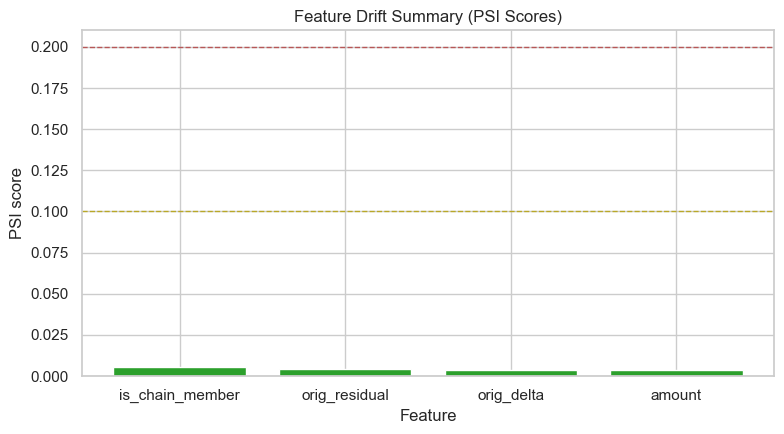

In [64]:
# Step 4/5: PR-AUC early vs late + drift summary bar chart
from sklearn.metrics import average_precision_score

# Use final deployed calibrated RF model selected in 12.8 (FINAL_MODEL_KEY).
# Prefer in-memory objects if available; otherwise load artifacts mapped by FINAL_MODEL_KEY.
if 'preprocessor' in globals() and ('best_calibrated_model' in globals()) and ('FINAL_MODEL_KEY' in globals()):
    _pre = preprocessor
    _cal = best_calibrated_model
else:
    import joblib
    from pathlib import Path
    _art = Path('artifacts')
    _pre = joblib.load(_art / 'preprocessor_paysim.joblib')
    model_file_map = {
        'rf_plain_uncalibrated': 'rf_plain_base.joblib',
        'rf_plain_sigmoid': 'rf_plain_sigmoid_calibrated.joblib',
        'rf_plain_isotonic': 'rf_plain_isotonic_calibrated.joblib',
    }
    _key = FINAL_MODEL_KEY if 'FINAL_MODEL_KEY' in globals() else 'rf_plain_isotonic'
    _fname = model_file_map.get(_key, 'rf_plain_base.joblib')
    _cal = joblib.load(_art / _fname)

# Build chain-aware model inputs for evaluation (no retraining)
model_cols = ['step','type','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',
              'orig_delta','dest_delta','orig_residual','orig_zero_old','dest_zero_old','orig_zero_new','dest_zero_new',
              'log_amount','chain_size','is_chain_member']

def prepare_eval_frame(d: pd.DataFrame) -> pd.DataFrame:
    x = d.copy()
    x['dest_delta'] = x['newbalanceDest'] - x['oldbalanceDest']
    x['orig_zero_old'] = (x['oldbalanceOrg'] == 0).astype(np.int8)
    x['dest_zero_old'] = (x['oldbalanceDest'] == 0).astype(np.int8)
    x['orig_zero_new'] = (x['newbalanceOrig'] == 0).astype(np.int8)
    x['dest_zero_new'] = (x['newbalanceDest'] == 0).astype(np.int8)
    x['log_amount'] = np.log1p(x['amount'].astype(np.float64))

    # Avoid merge suffix collisions if these columns already exist in the sampled frame.
    x = x.drop(columns=['chain_size', 'is_chain_member'], errors='ignore')

    cg = (
        x.groupby(['step', 'amount'], as_index=False)
         .agg(chain_size=('type','size'),
              has_transfer=('type', lambda s: (s == 'TRANSFER').any()),
              has_cash_out=('type', lambda s: (s == 'CASH_OUT').any()))
    )
    cg['is_chain_member'] = ((cg['has_transfer'] & cg['has_cash_out']) & (cg['chain_size'] <= 12)).astype(np.int8)
    x = x.merge(cg[['step','amount','chain_size','is_chain_member']], on=['step','amount'], how='left')
    x['chain_size'] = x['chain_size'].fillna(1).astype(np.int32)
    x['is_chain_member'] = x['is_chain_member'].fillna(0).astype(np.int8)
    return x

# Cap rows for speed but keep enough volume for stable PR-AUC estimate
n_eval = 200_000
early_eval = early.sample(min(len(early), n_eval), random_state=42).copy()
late_eval = late.sample(min(len(late), n_eval), random_state=42).copy()

early_x = prepare_eval_frame(early_eval)
late_x = prepare_eval_frame(late_eval)

early_proc = _pre.transform(early_x[model_cols])
late_proc = _pre.transform(late_x[model_cols])
early_proc = np.asarray(early_proc, dtype=np.float64)
late_proc = np.asarray(late_proc, dtype=np.float64)

early_prob = _cal.predict_proba(early_proc)[:, 1]
late_prob = _cal.predict_proba(late_proc)[:, 1]

pr_auc_early = average_precision_score(early_eval['isFraud'], early_prob)
pr_auc_late = average_precision_score(late_eval['isFraud'], late_prob)
delta = pr_auc_early - pr_auc_late

print(f'PR-AUC early: {pr_auc_early:.4f}')
print(f'PR-AUC late : {pr_auc_late:.4f}')
print(f'Delta (early - late): {delta:.4f}')
if abs(delta) > 0.05:
    print('Drift detected — retraining recommended')
else:
    print('Model stable')

# Step 5: drift summary bar chart
color_map = {'GREEN': '#2ca02c', 'YELLOW': '#ffbf00', 'RED': '#d62728'}
bar_colors = [color_map[s] for s in psi_table['status']]

plt.figure(figsize=(8, 4.5))
plt.bar(psi_table['feature'], psi_table['psi'], color=bar_colors)
plt.axhline(0.1, linestyle='--', linewidth=1, color='#b59f00', alpha=0.8)
plt.axhline(0.2, linestyle='--', linewidth=1, color='#b23a3a', alpha=0.8)
plt.ylabel('PSI score')
plt.xlabel('Feature')
plt.title('Feature Drift Summary (PSI Scores)')
plt.tight_layout()
plt.show()

### 13.1 Interpretation and action guidance

How to read this section:

- **PSI < 0.10 (GREEN):** no meaningful drift.
- **0.10 <= PSI <= 0.20 (YELLOW):** mild drift; monitor closely.
- **PSI > 0.20 (RED):** significant drift; investigate and consider refresh.

For model health, we compare **PR-AUC early vs late** using the final calibrated model.  
If the absolute gap exceeds **0.05**, we treat that as an operational warning and recommend retraining/recalibration review.

This gives a simple, transparent monitoring story:

1. Check feature drift (PSI),
2. Check performance drift (PR-AUC gap),
3. Trigger investigation/retraining when thresholds are exceeded.

### 13.2 Deployment readiness checkpoint (post-drift)

**Current deployment decision remains unchanged:** use chain-aware **Random Forest + dynamically selected RF-family calibration (`FINAL_MODEL_KEY`)** triage.

This checkpoint confirms the monitoring view:

1. **Discrimination quality** (PR-AUC / confusion behavior),
2. **Probability quality** (calibration for threshold-based actions),
3. **Decision transparency** (local SHAP + policy-aligned explanation in Streamlit),
4. **Stability checks** (early-vs-late drift via PSI and PR-AUC gap).

Operational interpretation:

- If PSI and PR-AUC gap remain within tolerance, keep current model/thresholds and continue monitoring.
- If PSI rises into RED zones or PR-AUC gap exceeds tolerance, trigger investigation and schedule recalibration/retraining.

## 14. SHAP Combined Decision Story (one blocked transaction)

This section creates one **local explainability case study** for a blocked transaction and connects four pieces together:

1. Global SHAP context (from earlier summary plot),
2. Local SHAP contribution (waterfall / force),
3. Calibrated fraud score and triage bucket,
4. Human-readable decision rationale.

Goal: show one complete and auditable decision story from model signal to final action.

Case index: 367
True label: 1
Calibrated probability: 1.0000
Final triage bucket: RED


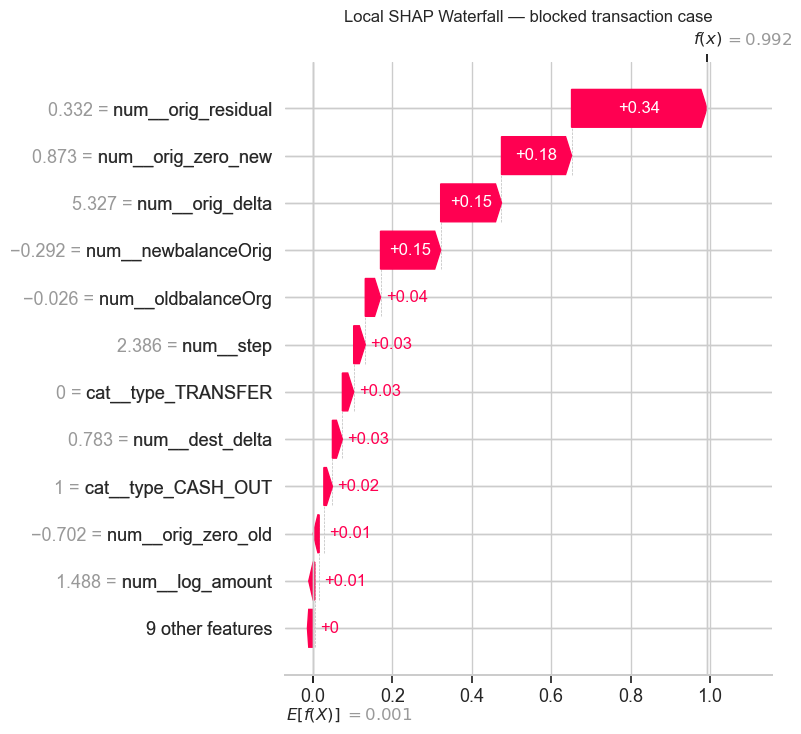

,feature,shap_value,abs_shap,processed_value
0,num__orig_residual,0.3408,0.3408,0.3323
1,num__orig_zero_new,0.1764,0.1764,0.8733
2,num__orig_delta,0.1532,0.1532,5.3267
3,num__newbalanceOrig,0.1515,0.1515,-0.2925
4,num__oldbalanceOrg,0.0384,0.0384,-0.0256
5,num__step,0.0292,0.0292,2.3864
6,cat__type_TRANSFER,0.0285,0.0285,0.0000
7,num__dest_delta,0.0251,0.0251,0.7833


In [65]:
# Build one blocked-transaction SHAP case (waterfall + optional force plot export)
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Required objects from earlier sections
required = ["X_test", "Xte_ch", "y_test", "final_bucket", "probs_by_model", "experiments_with_chain", "preprocessor"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Sections 12.4, 12.8, 12.9b, and 12.10 first. Missing: " + ", ".join(missing))

# Use the same base model and calibrated probabilities as deployment story
rf_base_model = experiments_with_chain["rf_plain"]["model"]
if "FINAL_MODEL_KEY" not in globals() or FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError("FINAL_MODEL_KEY missing from probs_by_model. Re-run 12.8/12.9b.")
cal_probs = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
triage = np.asarray(final_bucket).astype(str)
y_true = np.asarray(y_test).astype(int)

# Pick one blocked example (prefer true fraud if available)
red_idx_all = np.where(triage == "RED")[0]
if len(red_idx_all) == 0:
    raise ValueError("No RED rows found in final_bucket. Re-run 12.9 or adjust thresholds.")
red_fraud_idx = [i for i in red_idx_all if y_true[i] == 1]
case_idx = int(red_fraud_idx[0] if len(red_fraud_idx) else red_idx_all[0])

# Build local SHAP explanation for this exact transaction
proc_feature_names = list(preprocessor.get_feature_names_out())
X_proc_df = pd.DataFrame(np.asarray(Xte_ch, dtype=np.float64), columns=proc_feature_names)
explainer = shap.TreeExplainer(rf_base_model)
shap_values_raw = explainer.shap_values(X_proc_df.iloc[[case_idx]])
if isinstance(shap_values_raw, list):
    sv = np.asarray(shap_values_raw[1][0], dtype=np.float64)
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    sv = np.asarray(shap_values_raw[0, :, 1], dtype=np.float64)
else:
    sv = np.asarray(shap_values_raw[0], dtype=np.float64)

# Build Explanation object for shap.plots.waterfall
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = float(np.asarray(explainer.expected_value).reshape(-1)[-1])
else:
    base_value = float(explainer.expected_value)

exp = shap.Explanation(
    values=sv,
    base_values=base_value,
    data=X_proc_df.iloc[case_idx].to_numpy(dtype=np.float64),
    feature_names=proc_feature_names,
)

print(f"Case index: {case_idx}")
print(f"True label: {int(y_true[case_idx])}")
print(f"Calibrated probability: {cal_probs[case_idx]:.4f}")
print(f"Final triage bucket: {triage[case_idx]}")

# Waterfall plot (best for static/PDF export)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title("Local SHAP Waterfall — blocked transaction case")
plt.tight_layout()
plt.show()

# Optional: build force plot dynamically (no PNG save)
try:
    _ = shap.force_plot(base_value, sv, X_proc_df.iloc[case_idx], matplotlib=True, show=False)
    plt.title("Local SHAP Force Plot — blocked transaction case")
    plt.tight_layout()
    plt.close()
except Exception:
    pass

# Top contributors table for discussion
top_idx = np.argsort(np.abs(sv))[::-1][:8]
top_df = pd.DataFrame({
    "feature": [proc_feature_names[i] for i in top_idx],
    "shap_value": [float(sv[i]) for i in top_idx],
    "abs_shap": [float(abs(sv[i])) for i in top_idx],
    "processed_value": [float(X_proc_df.iloc[case_idx, i]) for i in top_idx],
})
display(top_df)


### 14.1 Discussion — why this transaction was blocked

Interpret this case in a simple chain:

- **Risk score layer:** calibrated probability is high enough to map to **RED** under triage policy.
- **Local SHAP layer:** top positive SHAP contributors are the strongest model signals pushing this case toward fraud.
- **Chain-aware layer:** if `is_chain_member` / `chain_size` appears among top contributors, it confirms the chain-context signal is actively used in this decision.
- **Action layer:** policy converts this risk profile into **BLOCK** for operational safety.

This gives a complete explainability path for one case:  
**Model signal -> SHAP evidence -> policy rule -> final action.**

## 14.2 Local Explanation Cross-Check (SHAP vs LIME)

This subsection compares two *local* explainability methods on the **same blocked transaction**:

- **LIME (display first)**: local surrogate explanation using feature perturbations (no waterfall/force-plot visuals).
- **SHAP (primary)**: model-faithful local feature contributions.

We expect broadly consistent risk drivers. In particular, we explicitly check whether **both methods highlight `is_chain_member`** as an active fraud signal for this case.


LIME is used only as a local explanation cross-check, while SHAP remains the primary explanation method in this project.


In [66]:
# SHAP vs LIME comparison (same blocked transaction case)
# Note: this is notebook-only and is used as an academic robustness check.

import numpy as np
import pandas as pd

# Defensive checks: ensure Section 17 variables exist
required = [
    "Xtr_ch",
    "rf_base_model",
    "X_proc_df",
    "proc_feature_names",
    "case_idx",
    "top_df",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Section 17 first. Missing: " + ", ".join(missing))

# LIME (install once via CLI: `pip install lime`)
try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError as e:
    raise ImportError("LIME is not installed. Run `pip install lime` in your terminal first.") from e

# -----------------
# 1) SHAP (already computed)
# -----------------
shap_top = top_df.copy()
shap_top["feature"] = shap_top["feature"].astype(str)
shap_has_chain = any("is_chain_member" in f for f in shap_top["feature"].tolist())

# -----------------
# 2) LIME
# -----------------
X_lime_train = np.asarray(Xtr_ch, dtype=np.float64)
X_lime_row = X_proc_df.iloc[case_idx].to_numpy(dtype=np.float64)

explainer_lime = LimeTabularExplainer(
    training_data=X_lime_train,
    feature_names=[str(x) for x in proc_feature_names],
    class_names=["not_fraud", "fraud"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# LIME calls this to get class probabilities; we use the same base model as SHAP

def predict_proba_for_lime(x: np.ndarray) -> np.ndarray:
    x2 = np.asarray(x, dtype=np.float64)
    return np.asarray(rf_base_model.predict_proba(x2), dtype=np.float64)

lime_exp = explainer_lime.explain_instance(
    data_row=X_lime_row,
    predict_fn=predict_proba_for_lime,
    num_features=8,
    top_labels=1,
)

# For class label 1 = fraud
lime_as_list = lime_exp.as_list(label=1)
# entries look like: ["feature <= threshold", weight]

lime_top = pd.DataFrame(lime_as_list, columns=["feature", "lime_weight"])

lime_top["feature"] = lime_top["feature"].astype(str)
lime_has_chain = any("is_chain_member" in f for f in lime_top["feature"].tolist())

# -----------------
# 3) Show agreement (LIME first)
# -----------------
agreement_is_chain_member = bool(shap_has_chain and lime_has_chain)

print(f"LIME top drivers include is_chain_member? {lime_has_chain}")
print(f"SHAP top drivers include is_chain_member? {shap_has_chain}")
print(f"Both agree on is_chain_member? {agreement_is_chain_member}")

print("\nLIME local drivers (top rules):")
display(lime_top.assign(lime_weight=lambda d: d["lime_weight"].round(6)))

print("\nSHAP local drivers (top |abs| features):")
display(
    pd.DataFrame(
        {
            "SHAP feature": shap_top["feature"].head(8).tolist(),
            "SHAP |abs|": shap_top["abs_shap"].head(8).round(6).tolist(),
        }
    )
)

# For convenience: show compact cross-table
combined = pd.DataFrame(
    {
        "method": ["LIME", "SHAP"],
        "has_is_chain_member": [lime_has_chain, shap_has_chain],
    }
)
display(combined)


LIME top drivers include is_chain_member? True
SHAP top drivers include is_chain_member? False
Both agree on is_chain_member? False

LIME local drivers (top rules):


,feature,lime_weight
0,num__is_chain_member <= -0.03,-0.0987
1,num__oldbalanceOrg > -0.25,0.0613
2,num__log_amount > 0.78,-0.0194
3,cat__type_TRANSFER <= 0.00,-0.0183
4,num__dest_delta > 0.03,-0.0136
5,cat__type_DEBIT <= 0.00,0.0117
6,0.00 < cat__type_CASH_OUT <= 1.00,0.0112
7,num__chain_size <= -0.02,0.0091



SHAP local drivers (top |abs| features):


,SHAP feature,SHAP |abs|
0,num__orig_residual,0.3408
1,num__orig_zero_new,0.1764
2,num__orig_delta,0.1532
3,num__newbalanceOrig,0.1515
4,num__oldbalanceOrg,0.0384
5,num__step,0.0292
6,cat__type_TRANSFER,0.0285
7,num__dest_delta,0.0251


,method,has_is_chain_member
0,LIME,True
1,SHAP,False


### 14.2 Discussion — what the two local methods agree on

Use the printed line(s) and the `combined` table from the previous cell as evidence:

- If **both** SHAP and LIME say `is_chain_member` is among the top local drivers, that supports your chain-aware story: the chain-context feature is a consistent risk signal for this specific blocked transaction.
- If they don’t fully match, that’s expected: SHAP is model-faithful for the true model, while LIME is a local surrogate that approximates effects via perturbations.

In this project, the deployed explanation remains **SHAP** (as shown in Streamlit). LIME here is only to demonstrate academic robustness via a second explanation lens.


## 15. Error Analysis: False Negatives and False Positives

Even with a calibrated, cost-sensitive triage policy, some mistakes remain. This section inspects where the current final setup still fails, without retraining or changing any thresholds/policy.

Focus:
- **False negatives (FN):** true fraud rows not sent to `RED` (and also frauds predicted negative at the operating threshold).
- **False positives (FP):** legitimate rows sent to `RED`.

This helps us explain residual risk and where future feature work could improve performance.


In [67]:
# Error analysis for current deployed/demo policy (analysis-only; no retraining).
import numpy as np
import pandas as pd
from IPython.display import display

required = ["y_test", "X_test", "final_bucket", "probs_by_model"]
missing = [n for n in required if n not in globals()]
if missing:
    raise ValueError("Run Sections 12.8 and 12.9b first. Missing: " + ", ".join(missing))

if "FINAL_MODEL_KEY" not in globals():
    raise ValueError("FINAL_MODEL_KEY missing. Re-run Section 12.8 calibration.")
if FINAL_MODEL_KEY not in probs_by_model:
    raise ValueError(f"{FINAL_MODEL_KEY} not found in probs_by_model. Re-run calibration/triage sections.")

# Use already-computed final calibrated probabilities and final triage buckets.
y_true = np.asarray(y_test).astype(int)
calibrated_probability = np.asarray(probs_by_model[FINAL_MODEL_KEY], dtype=np.float64)
final_bucket_arr = np.asarray(final_bucket).astype(str)

# Keep rows aligned to the same test index order.
err_df = X_test.reset_index(drop=True).copy()
err_df["calibrated_probability"] = calibrated_probability
err_df["final_bucket"] = final_bucket_arr
err_df["true_label"] = y_true

# Optional binary view at operating threshold (if available from 12.9b).
if "operating_threshold" in globals():
    thr = float(operating_threshold)
else:
    # Fallback: derive threshold from the same cost setup if needed.
    thr = 0.50
err_df["binary_pred"] = (err_df["calibrated_probability"] >= thr).astype(int)

# 1) False negatives
# Primary definition: fraud not sent to RED
fn_df = err_df[(err_df["true_label"] == 1) & (err_df["final_bucket"] != "RED")].copy()
# Optional binary definition: fraud predicted negative
fn_binary_df = err_df[(err_df["true_label"] == 1) & (err_df["binary_pred"] == 0)].copy()

# 2) False positives
# Primary definition: legitimate sent to RED
fp_df = err_df[(err_df["true_label"] == 0) & (err_df["final_bucket"] == "RED")].copy()

# Summary stats
n_fraud = int((err_df["true_label"] == 1).sum())
n_red = int((err_df["final_bucket"] == "RED").sum())
fn_count = int(len(fn_df))
fp_count = int(len(fp_df))
fraud_missed_pct = 100 * fn_count / max(n_fraud, 1)
red_legit_pct = 100 * fp_count / max(n_red, 1)

summary_df = pd.DataFrame([
    {"metric": "False negatives (fraud not in RED)", "value": fn_count},
    {"metric": "False negatives (binary y_pred=0)", "value": int(len(fn_binary_df))},
    {"metric": "False positives (legitimate in RED)", "value": fp_count},
    {"metric": "Fraud missed (%)", "value": round(fraud_missed_pct, 2)},
    {"metric": "RED rows that are legitimate (%)", "value": round(red_legit_pct, 2)},
])

print("Error-analysis summary (final deployed/demo policy)")
display(summary_df)

# Compact columns for review tables (keep only available cols)
candidate_cols = [
    "step", "type", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest", "chain_size", "is_chain_member",
    "calibrated_probability", "final_bucket", "true_label"
]
show_cols = [c for c in candidate_cols if c in err_df.columns]

# 3/4) Top FN and FP samples
# FN: sort by highest calibrated probability among missed frauds
fn_top = fn_df.sort_values("calibrated_probability", ascending=False).head(5)
# FP: sort by highest calibrated probability among legitimate rows in RED
fp_top = fp_df.sort_values("calibrated_probability", ascending=False).head(5)

print("Top false negatives (fraud not in RED)")
display(fn_top[show_cols].reset_index(drop=True))

print("Top false positives (legitimate in RED)")
display(fp_top[show_cols].reset_index(drop=True))

# 6) Compact grouped summaries (optional aggregate analysis)
print("Grouped summary: False negatives by type")
display(fn_df.groupby("type", dropna=False).size().rename("count").sort_values(ascending=False).reset_index().head(8))

print("Grouped summary: False positives by type")
display(fp_df.groupby("type", dropna=False).size().rename("count").sort_values(ascending=False).reset_index().head(8))

if "is_chain_member" in err_df.columns:
    print("Grouped summary: False negatives by is_chain_member")
    display(fn_df.groupby("is_chain_member", dropna=False).size().rename("count").reset_index())

    print("Grouped summary: False positives by is_chain_member")
    display(fp_df.groupby("is_chain_member", dropna=False).size().rename("count").reset_index())

# 7) Short interpretation block (data-driven and honest)
fn_chain_share = float(fn_df["is_chain_member"].mean()) if ("is_chain_member" in fn_df.columns and len(fn_df) > 0) else np.nan
fp_chain_share = float(fp_df["is_chain_member"].mean()) if ("is_chain_member" in fp_df.columns and len(fp_df) > 0) else np.nan

fn_top_types = (
    fn_df["type"].value_counts().head(2).index.tolist()
    if "type" in fn_df.columns and len(fn_df) > 0 else []
)
fp_top_types = (
    fp_df["type"].value_counts().head(2).index.tolist()
    if "type" in fp_df.columns and len(fp_df) > 0 else []
)

print("Interpretation (from current test-set errors)")
if fn_count == 0:
    print("- No fraud cases were missed under the 'not in RED' definition on this split.")
else:
    chain_msg = "mostly non-chain" if (not np.isnan(fn_chain_share) and fn_chain_share < 0.5) else "mostly chain-like"
    print(f"- Missed fraud cases are {chain_msg}; dominant FN types: {fn_top_types if fn_top_types else 'N/A'}.")

if fp_count == 0:
    print("- No legitimate transactions were sent to RED on this split.")
else:
    chain_msg = "more chain-like" if (not np.isnan(fp_chain_share) and fp_chain_share >= 0.5) else "mostly non-chain"
    print(f"- RED false positives are {chain_msg}; dominant FP types: {fp_top_types if fp_top_types else 'N/A'}.")

print("- Use this section for risk communication; model/training/policy remain unchanged.")


Error-analysis summary (final deployed/demo policy)


,metric,value
0,False negatives (fraud not in RED),4.0000
1,False negatives (binary y_pred=0),4.0000
2,False positives (legitimate in RED),1.0000
3,Fraud missed (%),0.2400
4,RED rows that are legitimate (%),0.0600


Top false negatives (fraud not in RED)


,step,type,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,chain_size,is_chain_member,calibrated_probability,final_bucket,true_label
0,8,CASH_OUT,0.0000,0.0000,"11,397.0000","184,477.7700",1,0,0.0000,GREEN,1
1,13,TRANSFER,"79,466.4500",0.0000,"535,933.1600","263,908.8400",1,0,0.0000,GREEN,1
2,10,CASH_OUT,0.0000,0.0000,0.0000,"277,970.8800",1,0,0.0000,GREEN,1
3,21,CASH_OUT,0.0000,0.0000,"392,364.6200","415,656.9200",1,0,0.0000,GREEN,1


Top false positives (legitimate in RED)


...

Grouped summary: False negatives by is_chain_member


,is_chain_member,count
0,0,4


Grouped summary: False positives by is_chain_member


,is_chain_member,count
0,1,1


Interpretation (from current test-set errors)
- Missed fraud cases are mostly non-chain; dominant FN types: ['CASH_OUT', 'TRANSFER'].
- RED false positives are more chain-like; dominant FP types: ['TRANSFER'].
- Use this section for risk communication; model/training/policy remain unchanged.


### 15.0 Visual error summary (FN vs FP)

This plot complements the error tables above by showing the size of the two main error buckets in one view:

- **False Negatives (FN):** fraud cases not sent to `RED`.
- **False Positives (FP):** legitimate cases sent to `RED`.

Higher FN means missed-fraud risk; higher FP means over-block/review burden.


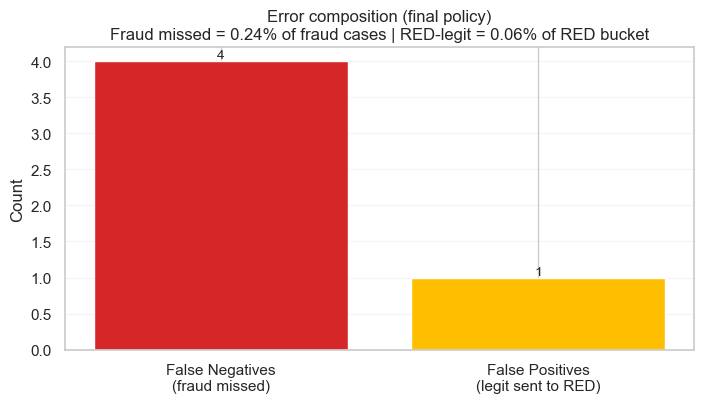

In [68]:
# Visual summary for Section 15 error composition
import matplotlib.pyplot as plt
import numpy as np

required = ["summary_df", "n_fraud", "n_red"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError("Run Section 15 error-analysis cell first. Missing: " + ", ".join(missing))

fn_count = int(summary_df.loc[summary_df["metric"] == "False negatives (fraud not in RED)", "value"].iloc[0])
fp_count = int(summary_df.loc[summary_df["metric"] == "False positives (legitimate in RED)", "value"].iloc[0])
fraud_missed_pct = 100 * fn_count / max(int(n_fraud), 1)
red_legit_pct = 100 * fp_count / max(int(n_red), 1)

labels = ["False Negatives\n(fraud missed)", "False Positives\n(legit sent to RED)"]
values = [fn_count, fp_count]
colors = ["#d62728", "#ffbf00"]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Count")
ax.set_title(
    "Error composition (final policy)\n"
    f"Fraud missed = {fraud_missed_pct:.2f}% of fraud cases | "
    f"RED-legit = {red_legit_pct:.2f}% of RED bucket"
)
ax.grid(axis="y", alpha=0.2)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Discussion (visual takeaways):**

- The chart separates the two operational risks: missed fraud (**FN**) vs over-block burden (**FP**).
- In this run, FN and FP remain small relative to dataset size, but they are not zero, which is why monitoring and periodic recalibration checks are still necessary.
- Combine this visual with the type-level and chain-level tables above to decide where future feature/policy refinement should focus.


### 15.1 Discussion — what the error analysis indicates

The purpose of this section is to make residual model risk explicit, not to change the deployed policy.

Use the outputs above to communicate three points clearly:

- **Missed fraud risk (FN):** if false negatives are concentrated in lower-score or non-chain rows, current signals may be weaker for those fraud patterns.
- **Over-block risk (FP in RED):** if false positives are concentrated in `TRANSFER`/`CASH_OUT` and chain-like behavior, the model is catching suspicious structure but not all such cases are true fraud.
- **Operational implication:** this supports future feature-engineering and policy refinement discussions, while keeping current calibration/threshold/triage unchanged.

This interpretation should always be read together with the shown counts, percentages, and grouped summaries.


## 16. Optional Local LLM Integration (Explanation Layer Only)

This project optionally adds a local Ollama analyst-summary layer in Streamlit for human-readable explanation text.

### Pipeline placement (must remain unchanged)

`transaction input -> preprocessing -> RF + selected calibration (`FINAL_MODEL_KEY`) -> fraud probability -> triage bucket -> SHAP / reasons -> LLM analyst summary`

### Academic honesty note (important)

**Analyst summary is generated by a local LLM for explanation only. Fraud score and final action come from the calibrated ML pipeline.**

### Operational behavior

- LLM generation is **button-triggered** (`Generate analyst summary`) and not part of automatic scoring.
- Local models used via Ollama (default `llama3.1:8b`; optional `smollm:1.7b`).
- If Ollama/model is unavailable, the app shows a friendly fallback message.
- LLM output does **not** modify preprocessing, calibration, thresholds, triage logic, or final prediction.

### Why this is included

- Improves communication of model evidence to non-technical reviewers.
- Keeps the core decision policy fully ML-driven and auditable.


The LLM analyst copilot is optional and explanation-only; it does not change scoring, thresholds, preprocessing, or final decisions.


### (Moved) Streamlit tab-compute section is placed after Final Verdict.

This section summarizes how each Streamlit tab computes outputs and where values come from.
It is a deployment/monitoring explanation only (no retraining in app runtime).

### Tab 1: Command Center

**Inputs:** loaded artifact metadata and deployment files (`feature_metadata.json`, selected model mapping, thresholds).

**Compute flow:**
1. Read final model key + threshold configuration from exported metadata.
2. Show deployment snapshot cards (model key, thresholds, prevalence).
3. Show policy-at-a-glance logic cards (calibrated risk, chain-aware scoring, business output).
4. Provide quick orientation to the rest of the app tabs.

**Important:** this tab is an operational overview; no scoring/retraining happens here.

### Tab 2: Dashboard (single transaction inference)

**Inputs:** manual form values (or example presets) for one transaction.

**Compute flow:**
1. Build engineered fields at runtime (for example: `orig_delta`, `orig_residual`, zero-balance flags, `log_amount`, chain demo fields).
2. Transform with saved preprocessor (`artifacts/preprocessor_paysim.joblib`).
3. Score with saved RF base + selected calibrated model (`artifacts/rf_selected_calibrated.joblib`).
4. Apply metadata thresholds (`review_threshold`, `block_threshold`, `moderate_cutoff`) and chain-escalation rule.
5. Show final bucket/action + local SHAP evidence.
6. Optional: Ollama analyst note (explanation-only; never used for scoring).

**Important:** this tab is dynamic for *inference*, not dynamic model training.

### Tab 3: Batch upload

**Inputs:** CSV rows with required raw features (and chain-aware columns where expected by app mode).

**Compute flow:**
- Same saved preprocessing/scoring pipeline as Dashboard, applied row-wise over uploaded batch.
- Returns calibrated probability + triage bucket + reason fields per row.

**Output:** downloadable scored CSV.

### Tab 4: Drift Monitor

**Inputs:** dataset currently loaded by app (early vs late window split by `step`).

**Compute flow:**
1. Split into early/late windows.
2. Recompute drift-check features (including chain-aware fields used for monitoring path).
3. Compute PSI per monitored feature (numeric-bin PSI + binary PSI where applicable).
4. Score both windows with current deployed scorer.
5. Compute PR-AUC early vs late and evaluate gap.

**Dynamic behavior:** values are recomputed when user clicks **Run drift calculations now**.

**Cache note:** loader uses cached data for performance.
If source CSV is updated (for example tomorrow's shifted data), recommended operational flow is:
1. update/replace CSV,
2. restart Streamlit (or clear cache),
3. rerun drift calculations.

### Tab 5: Model Card

**Source:** `MODEL_CARD.md` rendered in app.

**What it communicates:** deployed scope, intended use, constraints, and snapshot metrics aligned with exported artifacts/metadata.

---

### Why this section exists

If asked in review/viva: the app is a **live inference + monitoring interface over saved artifacts**.
Runtime outputs are dynamic with new inputs/data, while model parameters come from exported notebook artifacts.

### Keep vs remove earlier drift explanation?

Keep both:
- earlier Section 13 text = detailed drift method,
- this end section = concise all-tab operational summary.

They serve different purposes and are not redundant for presentation/Q&A.

## 17. Final Verdict (end-to-end)

**Final recommendation:** deploy the chain-aware **Random Forest + dynamically selected RF-family calibration (`FINAL_MODEL_KEY`)** system with policy-based triage (**GREEN/REVIEW/RED**) and SHAP-backed decision transparency.

Why this is final:

- Model quality is strong (fraud-focused metrics and calibrated probabilities).
- Decision flow is operational (clear threshold policy + chain escalation rule).
- Explainability is complete (global SHAP + local blocked-case story).
- Monitoring is present (feature drift via PSI + performance drift via PR-AUC gap).

Deployment posture:

- Continue monitoring with Drift tab / Section 13 checks.
- If drift thresholds are breached, trigger recalibration/retraining workflow.

This closes the full pipeline from **discovery -> modeling -> calibration/triage -> explanation (SHAP, optional LLM summary) -> monitoring -> action**.

### Future Scope

- **Enable real-time chain detection:** move offline chain-aware feature construction to a streaming pipeline so `TRANSFER -> CASH_OUT` patterns can be detected from live transaction histories.
- **Validate on real-world financial data:** evaluate whether the fraud-chain behavior observed in PaySim generalizes to production-style logs.
- **Add adaptive monitoring and retraining triggers:** extend drift monitoring into automatic recalibration/retraining when feature drift or performance drift exceeds policy thresholds.
- **Improve non-chain fraud coverage:** use current error-analysis findings to design features/rules for fraud cases outside dominant chain patterns.
- **Introduce human-in-the-loop learning:** feed analyst review outcomes into threshold tuning, escalation policy refinement, and retraining priorities.
- **Expand analyst decision support:** improve explanation and alert prioritization while keeping the calibrated ML pipeline as the sole decision-maker.

This project delivers an end-to-end chain-aware fraud triage system that combines discovery, modeling, calibration, explanation, monitoring, and business-action decisioning.


## 18. Streamlit App Tabs — How data is computed (quick reference)

This section summarizes how each Streamlit tab computes outputs and where values come from.
It is a deployment/monitoring explanation only (no retraining in app runtime).

### Tab 1: Command Center

**Inputs:** loaded artifact metadata and deployment files (`feature_metadata.json`, selected model mapping, thresholds).

**Compute flow:**
1. Read final model key + threshold configuration from exported metadata.
2. Show deployment snapshot cards (model key, thresholds, prevalence).
3. Show policy-at-a-glance logic cards (calibrated risk, chain-aware scoring, business output).
4. Provide quick orientation to the rest of the app tabs.

**Important:** this tab is an operational overview; no scoring/retraining happens here.

**Simple human summary (2-3 lines):**
- Landing page for quick model/policy orientation before scoring.
- Summarizes how calibrated score and chain logic map to action.
- Helps demo flow without repeating dashboard-level detail.

### Tab 2: Dashboard (single transaction inference)

**Inputs:** manual form values (or example presets) for one transaction.

**Compute flow:**
1. Build engineered fields at runtime (for example: `orig_delta`, `orig_residual`, zero-balance flags, `log_amount`, chain demo fields).
2. Transform with saved preprocessor (`artifacts/preprocessor_paysim.joblib`).
3. Score with saved RF base + selected calibrated model (`artifacts/rf_selected_calibrated.joblib`).
4. Apply metadata thresholds (`review_threshold`, `block_threshold`, `moderate_cutoff`) and chain-escalation rule.
5. Show final bucket/action + local SHAP evidence.
6. Optional: Ollama analyst note (explanation-only; never used for scoring).

**Important:** this tab is dynamic for *inference*, not dynamic model training.

**Simple human summary (2-3 lines):**
- User enters one transaction, app gives fraud score and action instantly.
- Same trained model is used every time; only input changes.
- SHAP and optional LLM text explain decision in plain language.

### Tab 3: Batch upload

**Inputs:** CSV rows with required raw features (and chain-aware columns where expected by app mode).

**Compute flow:**
- Same saved preprocessing/scoring pipeline as Dashboard, applied row-wise over uploaded batch.
- Returns calibrated probability + triage bucket + reason fields per row.

**Output:** downloadable scored CSV.

**Simple human summary (2-3 lines):**
- Upload many transactions at once.
- App scores each row with same deployed model and policy.
- You can download full scored output for review/reporting.

### Tab 4: Drift Monitor

**Inputs:** dataset currently loaded by app (early vs late window split by `step`).

**Compute flow:**
1. Split into early/late windows.
2. Recompute drift-check features (including chain-aware fields used for monitoring path).
3. Compute PSI per monitored feature (numeric-bin PSI + binary PSI where applicable).
4. Score both windows with current deployed scorer.
5. Compute PR-AUC early vs late and evaluate gap.

**Dynamic behavior:** values are recomputed when user clicks **Run drift calculations now**.

**Cache note:** loader uses cached data for performance.
If source CSV is updated (for example tomorrow's shifted data), recommended operational flow is:
1. update/replace CSV,
2. restart Streamlit (or clear cache),
3. rerun drift calculations.

**Simple human summary (2-3 lines):**
- This tab checks if data pattern has changed over time.
- If drift is high or model quality drops, tab raises warning.
- It helps decide when to recalibrate/retrain pipeline.

### Tab 5: Model Card

**Source:** `MODEL_CARD.md` rendered in app.

**What it communicates:** deployed scope, intended use, constraints, and snapshot metrics aligned with exported artifacts/metadata.

**Simple human summary (2-3 lines):**
- This is quick documentation of what model does and does not do.
- It shows assumptions, limits, and current metric snapshot.
- Useful for transparent demo and Q&A.



## Future work

- **Enable real-time chain detection:** move offline chain-aware feature construction to a streaming pipeline so `TRANSFER -> CASH_OUT` patterns can be detected from live transaction histories.
- **Validate on real-world financial data:** evaluate whether the fraud-chain behavior observed in PaySim generalizes to production-style logs.
- **Add adaptive monitoring and retraining triggers:** extend drift monitoring into automatic recalibration/retraining when feature drift or performance drift exceeds policy thresholds.
- **Improve non-chain fraud coverage:** use current error-analysis findings to design features/rules for fraud cases outside dominant chain patterns.
- **Introduce human-in-the-loop learning:** feed analyst review outcomes into threshold tuning, escalation policy refinement, and retraining priorities.
- **Expand analyst decision support:** improve explanation and alert prioritization while keeping the calibrated ML pipeline as the sole decision-maker.
- **Drift on any extract, not just one file:** Today the drift view is tied to a **single** PaySim CSV in the project folder. Next step is to make drift **flexible**—for example let you **pick a different file**, **paste a path**, or **upload a new CSV**—so you can compare early vs late (or old vs new data) whenever you get a fresh export, instead of always replacing that one file.

This project delivers an end-to-end chain-aware fraud triage system that combines discovery, modeling, calibration, explanation, monitoring, and business-action decisioning.
